# **1. Import Data & Libraries**

In [7]:
# Core & Utility Libraries
import os
import random
import warnings
import gdown

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import squarify
%matplotlib inline

# Scikit-Learn: Preprocessing & Encoders
from category_encoders import TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (StandardScaler, OrdinalEncoder, FunctionTransformer, 
                                   LabelEncoder, MinMaxScaler)
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# Scikit-Learn: Model Selection
from sklearn.model_selection import (train_test_split, GridSearchCV, cross_val_score, 
                                     cross_val_predict, StratifiedKFold)

# Scikit-Learn: Models
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (IsolationForest, StackingClassifier, 
                              HistGradientBoostingClassifier)
from sklearn.ensemble import RandomForestRegressor

# Metrics
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import (make_scorer, accuracy_score, classification_report, 
                             f1_score)

# Boosting Libraries
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb
from lightgbm import LGBMRegressor
from catboost import CatBoostClassifier, Pool

# Deep Learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

# Optimization
import optuna

# --- Configuration & Setup ---

# Ignore Warnings
warnings.filterwarnings("ignore")

# Pandas Display Options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set Seaborn Color Palette
colors = ['#1c76b6', '#a7dae9', '#eb6a20', '#f59d3d', '#677fa0', '#d6e4ed', '#f7e9e5']
sns.set_palette(colors)

In [8]:
def create_gdrive_download_link(sharing_link: str) -> str:
    try:
        file_id = sharing_link.split('/d/')[1].split('/')[0]
        download_link = f'https://drive.google.com/uc?export=download&id={file_id}'
        return download_link
    except IndexError:
        return "Error: The provided URL does not seem to be a valid Google Drive sharing link."
    except Exception as e:
        return f"An unexpected error occurred: {e}"

In [9]:
ISPU_2010_PATH = 'https://drive.google.com/file/d/15fVGOMV9-uJ8xeg1MSMKdfvbK4earda4/view?usp=drive_link'
ISPU_2011_PATH = 'https://drive.google.com/file/d/1GpU2q7Gv5-zcgeNUYk6cgcUE7ZZMq8U6/view?usp=drive_link'
ISPU_2012_PATH = 'https://drive.google.com/file/d/1AKsccdBK3TFWYauI9fAqMf2OSr6oSDRJ/view?usp=drive_link'
ISPU_2013_PATH = 'https://drive.google.com/file/d/1Fd1N2__OYcUTN-HkTXCYD0B7wmQ0rCsq/view?usp=drive_link'
ISPU_2014_PATH = 'https://drive.google.com/file/d/1MxmuX7i3zxtu7WyZRjDtjxfJ4dCCxxl-/view?usp=drive_link'
ISPU_2015_PATH = 'https://drive.google.com/file/d/196pME2Pd4l2LehuUjfCwYBBcyFRkj1Ay/view?usp=drive_link'
ISPU_2016_PATH = 'https://drive.google.com/file/d/1aPH10uChKH0Rl3Wsb-MUIBxWzcU1ZU40/view?usp=drive_link'
ISPU_2017_PATH = 'https://drive.google.com/file/d/1UW7QFER72pkFC0aQuryTdygyUWDefjVZ/view?usp=drive_link'
ISPU_2018_PATH = 'https://drive.google.com/file/d/1Y92J0uM-2JkU7gRqgK9l8UDWVccBlKCF/view?usp=drive_link'
ISPU_2019_PATH = 'https://drive.google.com/file/d/1JD8g1XrUy5TA51_2nM7NuDFll5zF3oL3/view?usp=drive_link'
ISPU_2020_PATH = 'https://drive.google.com/file/d/1DFeY35d7e3yPRfIvTVZAWMDxEAuZ7px-/view?usp=drive_link'
ISPU_2021_PATH = 'https://drive.google.com/file/d/1Dn9Wzef_FmD9jU6zh00fd744ZvxgsS9n/view?usp=drive_link'
ISPU_2022_PATH = 'https://drive.google.com/file/d/1xXnDKY0dAtxXFuaqGRsq11wcgQrbvmUr/view?usp=drive_link'
ISPU_2023_PATH = 'https://drive.google.com/file/d/1NhEztNw6qt4MF40dG6rKyosLss8nrb06/view?usp=drive_link'
ISPU_2024_PATH = 'https://drive.google.com/file/d/1jq55H_y5cEsoimVskaBUledZvkpCui7m/view?usp=drive_link'
ISPU_2025_PATH = 'https://drive.google.com/file/d/1pACnm5KFkblGVEU7s1DiKIO6mzmrNMPS/view?usp=drive_link'
NDVI_PATH = 'https://drive.google.com/file/d/1KAmU4zHtW4QX2ERGAHsUUcuwmDP9t5y5/view?usp=drive_link'
CUACA_HARIAN_DKI1_PATH = 'https://drive.google.com/file/d/1Tj6Wz_kOYA2V2W8_MWrXVllDM15XQW8h/view?usp=drive_link'
CUACA_HARIAN_DKI2_PATH = 'https://drive.google.com/file/d/1vc3LibSDOVEGCWH8GZCGX1zW1gXqqouR/view?usp=drive_link'
CUACA_HARIAN_DKI3_PATH = 'https://drive.google.com/file/d/1ZoS8KEPVQmyAJduy0XNU8dA7y0JSuC2e/view?usp=drive_link'
CUACA_HARIAN_DKI4_PATH = 'https://drive.google.com/file/d/1rN4m10bgqWIfxqapV3_OPUIagtnT4lp3/view?usp=drive_link'
CUACA_HARIAN_DKI5_PATH = 'https://drive.google.com/file/d/1fZJMBJ158LUR0M8olVilLpPqlYcm6Sy6/view?usp=drive_link'
JUMLAH_PENDUDUK_PATH = 'https://drive.google.com/file/d/1Y5e-Q6JKw1wND70ikR_P5xnKh6B4lblT/view?usp=drive_link'
KUALITAS_AIR_SUNGAI_PATH = 'https://drive.google.com/file/d/1CWxGYt8JtQSB18EerYO8WjjBeeCGaw7Q/view?usp=drive_link'
LIBUR_NASIONAL_PATH = 'https://drive.google.com/file/d/1KTq4UfHypV8wpgb0lzTsyKON2EI6i8H0/view?usp=drive_link'
SAMPLE_SUB_PATH = 'https://drive.google.com/file/d/1zKc0EQFr_70aDUNE247x3qYYtIUC8E9M/view?usp=drive_link'
CUACA_HOURLY_DKI1_PATH = 'https://drive.google.com/file/d/1f7x-DZL3EPP4aedRKMRMQ9yc96pFmxND/view?usp=drive_link'
CUACA_HOURLY_DKI2_PATH = 'https://drive.google.com/file/d/1TqtOUFaUz6IHxCwrSgQDV3OyTYNbpxF8/view?usp=drive_link'
CUACA_HOURLY_DKI3_PATH = 'https://drive.google.com/file/d/1_AD5mwhoQW3LX6wvRtyYQjAtQywmYMjl/view?usp=drive_link'
CUACA_HOURLY_DKI4_PATH = 'https://drive.google.com/file/d/1_JTviPV7fLTsW_HHb42si8dfsW56oUNV/view?usp=drive_link'
CUACA_HOURLY_DKI5_PATH = 'https://drive.google.com/file/d/1ZsAUYLH26ZQYZ21m97iyAXwgwkTYZDjI/view?usp=drive_link'

In [10]:
files_map = {
    'ispu_2010.csv': ISPU_2010_PATH,
    'ispu_2011.csv': ISPU_2011_PATH,
    'ispu_2012.csv': ISPU_2012_PATH,
    'ispu_2013.csv': ISPU_2013_PATH,
    'ispu_2014.csv': ISPU_2014_PATH,
    'ispu_2015.csv': ISPU_2015_PATH,
    'ispu_2016.csv': ISPU_2016_PATH,
    'ispu_2017.csv': ISPU_2017_PATH,
    'ispu_2018.csv': ISPU_2018_PATH,
    'ispu_2019.csv': ISPU_2019_PATH,
    'ispu_2020.csv': ISPU_2020_PATH,
    'ispu_2021.csv': ISPU_2021_PATH,
    'ispu_2022.csv': ISPU_2022_PATH,
    'ispu_2023.csv': ISPU_2023_PATH,
    'ispu_2024.csv': ISPU_2024_PATH,
    'ispu_2025.csv': ISPU_2025_PATH,
    'ndvi.csv': NDVI_PATH,
    'cuaca_harian_dki1.csv': CUACA_HARIAN_DKI1_PATH,
    'cuaca_harian_dki2.csv': CUACA_HARIAN_DKI2_PATH,
    'cuaca_harian_dki3.csv': CUACA_HARIAN_DKI3_PATH,
    'cuaca_harian_dki4.csv': CUACA_HARIAN_DKI4_PATH,
    'cuaca_harian_dki5.csv': CUACA_HARIAN_DKI5_PATH,
    'jumlah_penduduk.csv': JUMLAH_PENDUDUK_PATH,
    'kualitas_air_sungai.csv': KUALITAS_AIR_SUNGAI_PATH,
    'libur_nasional.csv': LIBUR_NASIONAL_PATH,
    'sample_sub.csv': SAMPLE_SUB_PATH,
    'cuaca-dki1-hourly.csv': CUACA_HOURLY_DKI1_PATH,
    'cuaca-dki2-hourly.csv': CUACA_HOURLY_DKI2_PATH,
    'cuaca-dki3-hourly.csv': CUACA_HOURLY_DKI3_PATH,
    'cuaca-dki4-hourly.csv': CUACA_HOURLY_DKI4_PATH,
    'cuaca-dki5-hourly.csv': CUACA_HOURLY_DKI5_PATH,
}

custom_user_agent = 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'

dataframes = {}

for filename, url in files_map.items():
    dl_link = create_gdrive_download_link(url)

    print(f"Downloading {filename}...")
    gdown.download(
        url=dl_link,
        output=filename,
        quiet=True,
        fuzzy=True,              
        user_agent=custom_user_agent
    )

    if 'hourly' in filename:
        enc = 'ISO-8859-1'
    else:
        enc = 'utf-8'
    
    var_name = filename.replace('.csv', '')
    dataframes[var_name] = pd.read_csv(filename, encoding=enc)

In [11]:
df_ispu_2010 = dataframes['ispu_2010']
df_ispu_2011 = dataframes['ispu_2011']
df_ispu_2012 = dataframes['ispu_2012']
df_ispu_2013 = dataframes['ispu_2013']
df_ispu_2014 = dataframes['ispu_2014']
df_ispu_2015 = dataframes['ispu_2015']
df_ispu_2016 = dataframes['ispu_2016']
df_ispu_2017 = dataframes['ispu_2017']
df_ispu_2018 = dataframes['ispu_2018']
df_ispu_2019 = dataframes['ispu_2019']
df_ispu_2020 = dataframes['ispu_2020']
df_ispu_2021 = dataframes['ispu_2021']
df_ispu_2022 = dataframes['ispu_2022']
df_ispu_2023 = dataframes['ispu_2023']
df_ispu_2024 = dataframes['ispu_2024']
df_ispu_2025 = dataframes['ispu_2025']

df_ndvi = dataframes['ndvi']

df_cuaca_dki1 = dataframes['cuaca_harian_dki1']
df_cuaca_dki2 = dataframes['cuaca_harian_dki2']
df_cuaca_dki3 = dataframes['cuaca_harian_dki3']
df_cuaca_dki4 = dataframes['cuaca_harian_dki4']
df_cuaca_dki5 = dataframes['cuaca_harian_dki5']

df_penduduk = dataframes['jumlah_penduduk']
df_air_sungai = dataframes['kualitas_air_sungai']
df_libur = dataframes['libur_nasional']

sample_sub = dataframes['sample_sub']

cuaca_hourly_dki1 = dataframes['cuaca-dki1-hourly']
cuaca_hourly_dki2 = dataframes['cuaca-dki2-hourly']
cuaca_hourly_dki3 = dataframes['cuaca-dki3-hourly']
cuaca_hourly_dki4 = dataframes['cuaca-dki4-hourly']
cuaca_hourly_dki5 = dataframes['cuaca-dki5-hourly']

In [12]:
df_ispu = {
    2010: df_ispu_2010,
    2011: df_ispu_2011,
    2012: df_ispu_2012,
    2013: df_ispu_2013,
    2014: df_ispu_2014,
    2015: df_ispu_2015,
    2016: df_ispu_2016,
    2017: df_ispu_2017,
    2018: df_ispu_2018,
    2019: df_ispu_2019,
    2020: df_ispu_2020,
    2021: df_ispu_2021,
    2022: df_ispu_2022,
    2023: df_ispu_2023,
    2024: df_ispu_2024,
    2025: df_ispu_2025
}

# **2. Exploratory Data Analysis (EDA) 1**

In [13]:
for i in range(2010, 2026):
    print(f"Data ISPU Tahun {i}:")
    display(pd.concat([df_ispu[i].head(), df_ispu[i].tail()]))

Data ISPU Tahun 2010:


,periode_data,tanggal,stasiun,pm10,so2,co,o3,no2,max,critical,categori
0,201001,2010-01-19,DKI2 (Kelapa Gading),---,---,---,---,---,0,NaN,TIDAK ADA DATA
1,201001,2010-01-20,DKI2 (Kelapa Gading),---,---,---,---,---,0,NaN,TIDAK ADA DATA
2,201001,2010-01-21,DKI2 (Kelapa Gading),---,---,---,---,---,0,NaN,TIDAK ADA DATA
3,201001,2010-01-22,DKI2 (Kelapa Gading),---,---,---,---,---,0,NaN,TIDAK ADA DATA
4,201001,2010-01-23,DKI2 (Kelapa Gading),---,---,---,---,---,0,NaN,TIDAK ADA DATA
1820,201012,2010-12-27,DKI5 (Kebon Jeruk),---,---,---,---,---,0,NaN,TIDAK ADA DATA
1821,201012,2010-12-28,DKI5 (Kebon Jeruk),---,---,---,---,---,0,NaN,TIDAK ADA DATA
1822,201012,2010-12-29,DKI5 (Kebon Jeruk),---,---,---,---,---,0,NaN,TIDAK ADA DATA
1823,201012,2010-12-30,DKI5 (Kebon Jeruk),---,---,---,---,---,0,NaN,TIDAK ADA DATA
1824,201012,2010-12-31,DKI5 (Kebon Jeruk),---,---,---,---,---,0,NaN,TIDAK ADA DATA


Data ISPU Tahun 2011:


,periode_data,tanggal,pm10,so2,co,o3,no2,max,critical,categori,lokasi_spku
0,201105,2011-05-01,71,18,54,88,31,88,O3,SEDANG,DKI1
1,201105,2011-05-02,61,19,35,98,29,98,O3,SEDANG,DKI4
2,201105,2011-05-03,69,22,31,69,28,69,PM10,SEDANG,DKI1
3,201105,2011-05-04,63,18,26,47,17,63,PM10,SEDANG,DKI4
4,201105,2011-05-05,76,17,28,63,20,76,PM10,SEDANG,DKI4
360,201111,2011-11-26,79,19,33,126,15,126,O3,TIDAK SEHAT,DKI2
361,201111,2011-11-27,74,12,23,133,13,133,O3,TIDAK SEHAT,DKI2
362,201111,2011-11-28,134,27,35,159,26,159,O3,TIDAK SEHAT,DKI2
363,201111,2011-11-29,91,23,32,104,19,104,O3,TIDAK SEHAT,DKI2
364,201111,2011-11-30,75,20,28,164,20,164,O3,TIDAK SEHAT,DKI2


Data ISPU Tahun 2012:


...

,periode_data,tanggal,stasiun,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max,parameter_pencemar_kritis,kategori
0,202302,2023-02-25,DKI5 Kebon Jeruk Jakarta Barat,35,-,13,12,31,18,35,PM10,BAIK
1,202302,2023-02-26,DKI5 Kebon Jeruk Jakarta Barat,23,-,14,9,32,11,32,O3,BAIK
2,202302,2023-02-27,DKI5 Kebon Jeruk Jakarta Barat,20,-,13,8,33,13,33,O3,BAIK
3,202302,2023-02-28,DKI5 Kebon Jeruk Jakarta Barat,30,-,21,11,28,18,30,PM10,BAIK
4,202303,2023-03-01,DKI1 Bunderan HI,38,44,50,8,19,27,50,3,BAIK
1820,202311,2023-11-26,DKI5 Kebon Jeruk,48,71,33,21,44,20,71,PM25,SEDANG
1821,202311,2023-11-27,DKI5 Kebon Jeruk,51,76,32,18,53,19,76,PM25,SEDANG
1822,202311,2023-11-28,DKI5 Kebon Jeruk,56,88,33,20,48,21,88,PM25,SEDANG
1823,202311,2023-11-29,DKI5 Kebon Jeruk,56,88,32,18,56,18,88,PM25,SEDANG
1824,202311,2023-11-30,DKI5 Kebon Jeruk,30,57,32,15,61,17,61,O3,SEDANG


Data ISPU Tahun 2024:


,periode_data,bulan,tanggal,stasiun,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max,parameter_pencemar_kritis,kategori
0,202401,1,21,DKI3 Jagakarsa,51.0,65.0,45.0,9.0,8.0,79.0,79.0,NaN,SEDANG
1,202401,1,22,DKI3 Jagakarsa,27.0,34.0,45.0,5.0,8.0,56.0,56.0,NaN,SEDANG
2,202401,1,23,DKI3 Jagakarsa,NaN,52.0,46.0,6.0,9.0,51.0,52.0,PM25,SEDANG
3,202401,1,24,DKI3 Jagakarsa,46.0,65.0,46.0,8.0,9.0,38.0,65.0,PM25,SEDANG
4,202401,1,25,DKI3 Jagakarsa,37.0,55.0,47.0,7.0,11.0,28.0,55.0,PM25,SEDANG
1825,202412,12,27,DKI5 Kebon Jeruk Jakarta Barat,NaN,55.0,27.0,9.0,30.0,12.0,55.0,PM25,SEDANG
1826,202412,12,28,DKI5 Kebon Jeruk Jakarta Barat,NaN,40.0,26.0,6.0,30.0,12.0,40.0,PM25,BAIK
1827,202412,12,29,DKI5 Kebon Jeruk Jakarta Barat,NaN,51.0,32.0,8.0,28.0,11.0,51.0,PM25,SEDANG
1828,202412,12,30,DKI5 Kebon Jeruk Jakarta Barat,NaN,34.0,9.0,5.0,38.0,8.0,38.0,O3,BAIK
1829,202412,12,31,DKI5 Kebon Jeruk Jakarta Barat,NaN,26.0,9.0,3.0,26.0,3.0,26.0,PM25,BAIK


Data ISPU Tahun 2025:


,periode_data,bulan,tanggal,stasiun,pm_sepuluh,pm_duakomalima,sulfur_dioksida,karbon_monoksida,ozon,nitrogen_dioksida,max,parameter_pencemar_kritis,kategori
0,202504,4,24,DKI5 Kebon Jeruk,16.0,50.0,18.0,3.0,16.0,4.0,50.0,PM25,BAIK
1,202504,4,25,DKI5 Kebon Jeruk,23.0,81.0,19.0,9.0,24.0,3.0,81.0,PM25,SEDANG
2,202504,4,26,DKI5 Kebon Jeruk,30.0,77.0,20.0,11.0,29.0,3.0,77.0,PM25,SEDANG
3,202504,4,27,DKI5 Kebon Jeruk,31.0,85.0,21.0,12.0,47.0,4.0,85.0,PM25,SEDANG
4,202504,4,28,DKI5 Kebon Jeruk,24.0,78.0,20.0,9.0,37.0,4.0,78.0,PM25,SEDANG
1210,202508,8,31,DKI3 Jagakarsa,28.0,60.0,53.0,8.0,19.0,39.0,60.0,PM25,SEDANG
1211,202508,8,1,DKI4 Lubang Buaya,63.0,89.0,30.0,7.0,28.0,16.0,89.0,PM25,SEDANG
1212,202508,8,2,DKI4 Lubang Buaya,73.0,105.0,31.0,11.0,25.0,21.0,105.0,PM25,TIDAK SEHAT
1213,202508,8,3,DKI4 Lubang Buaya,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TIDAK ADA DATA
1214,202508,8,4,DKI4 Lubang Buaya,63.0,84.0,27.0,14.0,26.0,26.0,84.0,PM25,SEDANG


In [14]:
pd.concat([df_ndvi.head(), df_ndvi.tail()])

,tanggal,stasiun_id,ndvi
0,2009-12-19,DKI5,0.3801
1,2010-01-01,DKI5,0.3705
2,2010-01-17,DKI5,0.4848
3,2010-02-02,DKI5,0.5710
4,2010-02-18,DKI5,0.4308
1805,2025-06-26,DKI2,0.2326
1806,2025-07-12,DKI2,0.2115
1807,2025-07-28,DKI2,0.2254
1808,2025-08-13,DKI2,0.2479
1809,2025-08-29,DKI2,0.2276


In [15]:
pd.concat([df_penduduk.head(), df_penduduk.tail()])

,periode_data,tahun,nama_provinsi,nama_kabupaten_kota,nama_kecamatan,nama_kelurahan,usia,jenis_kelamin,jumlah_penduduk
0,2013,2013,PROVINSI DKI JAKARTA,JAKARTA TIMUR,JATINEGARA,KAMPUNG MELAYU,0-4,Laki-laki,1419
1,2013,2013,PROVINSI DKI JAKARTA,JAKARTA SELATAN,PESANGGRAHAN,BINTARO,15-19,Laki-laki,1981
2,2013,2013,PROVINSI DKI JAKARTA,JAKARTA SELATAN,PESANGGRAHAN,PESANGGRAHAN,15-19,Laki-laki,1084
3,2013,2013,PROVINSI DKI JAKARTA,JAKARTA SELATAN,JAGAKARSA,CIPEDAK,15-19,Laki-laki,1533
4,2013,2013,PROVINSI DKI JAKARTA,JAKARTA SELATAN,JAGAKARSA,TANJUNG BARAT,15-19,Laki-laki,1691
34171,2016,2016,PROVINSI DKI JAKARTA,JAKARTA PUSAT,SAWAH BESAR,GUNUNG SAHARI UTARA,20-24,Laki laki,759
34172,2016,2016,PROVINSI DKI JAKARTA,JAKARTA PUSAT,SAWAH BESAR,MANGGA DUA SELATAN,20-24,Laki laki,1302
34173,2016,2016,PROVINSI DKI JAKARTA,JAKARTA PUSAT,KEMAYORAN,KEMAYORAN,20-24,Laki laki,936
34174,2016,2016,PROVINSI DKI JAKARTA,JAKARTA PUSAT,KEMAYORAN,KEBON KOSONG,20-24,Laki laki,1239
34175,2016,2016,PROVINSI DKI JAKARTA,JAKARTA PUSAT,KEMAYORAN,HARAPAN MULIA,20-24,Laki laki,1059


In [16]:
pd.concat([df_air_sungai.head(), df_air_sungai.tail()])

,periode_data,periode_pemantauan,bulan_sampling,titik_sampel,nama_sungai,alamat,latitude,longitude,jenis_parameter,parameter,baku_mutu,hasil_pengukuran
0,2024,Periode 2,5,KLT 3,Kalibaru Timur,Jl. Raya Bogor Komseko,-6.286182,106.870626,Kimia,pH,6.90,7.1100
1,2024,Periode 2,5,KLT 3,Kalibaru Timur,Jl. Raya Bogor Komseko,-6.286182,106.870626,Kimia,BOD,3.00,13.0000
2,2024,Periode 2,5,KLT 3,Kalibaru Timur,Jl. Raya Bogor Komseko,-6.286182,106.870626,Kimia,COD,25.00,41.0000
3,2024,Periode 2,5,KLT 3,Kalibaru Timur,Jl. Raya Bogor Komseko,-6.286182,106.870626,Kimia,DO,4.00,5.6000
4,2024,Periode 2,5,KLT 3,Kalibaru Timur,Jl. Raya Bogor Komseko,-6.286182,106.870626,Kimia,Nitrat,10.00,2.0000
14395,2024,Periode 2,5,SKR 2,Sekertaris,Jl. Arjuna Utara,-6.185175,106.782569,Kimia,DO,4.00,2.5000
14396,2024,Periode 2,5,SKR 2,Sekertaris,Jl. Arjuna Utara,-6.185175,106.782569,Kimia,Nitrat,10.00,0.0040
14397,2024,Periode 2,5,SKR 2,Sekertaris,Jl. Arjuna Utara,-6.185175,106.782569,Kimia,Nitrit,0.06,0.0123
14398,2024,Periode 2,5,SKR 2,Sekertaris,Jl. Arjuna Utara,-6.185175,106.782569,Kimia,Total P,0.20,1.3236
14399,2024,Periode 2,5,SKR 2,Sekertaris,Jl. Arjuna Utara,-6.185175,106.782569,Kimia,F,1.50,0.0100


In [17]:
pd.concat([df_libur.head(), df_libur.tail()])

,tanggal,is_holiday_nasional,nama_libur,is_weekend,day_name
0,2010-01-01,1,New Year's Day,0,Friday
1,2010-01-02,0,NaN,1,Saturday
2,2010-01-03,0,NaN,1,Sunday
3,2010-01-04,0,NaN,0,Monday
4,2010-01-05,0,NaN,0,Tuesday
5839,2025-12-27,0,NaN,1,Saturday
5840,2025-12-28,0,NaN,1,Sunday
5841,2025-12-29,0,NaN,0,Monday
5842,2025-12-30,0,NaN,0,Tuesday
5843,2025-12-31,0,NaN,0,Wednesday


In [18]:
pd.concat([sample_sub.head(), sample_sub.tail()])

,id,category
0,2025-09-01_DKI1,NaN
1,2025-09-01_DKI2,NaN
2,2025-09-01_DKI3,NaN
3,2025-09-01_DKI4,NaN
4,2025-09-01_DKI5,NaN
450,2025-11-30_DKI1,NaN
451,2025-11-30_DKI2,NaN
452,2025-11-30_DKI3,NaN
453,2025-11-30_DKI4,NaN
454,2025-11-30_DKI5,NaN


In [19]:
print(list(df_ispu[2010].columns))

['periode_data', 'tanggal', 'stasiun', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori']


In [20]:
for i in range(2010, 2026):
    print(f"Nama kolom-kolom pada df_ispu[{i}]:")
    print(list(df_ispu[i]))

Nama kolom-kolom pada df_ispu[2010]:
['periode_data', 'tanggal', 'stasiun', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori']
Nama kolom-kolom pada df_ispu[2011]:
['periode_data', 'tanggal', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori', 'lokasi_spku']
Nama kolom-kolom pada df_ispu[2012]:
['periode_data', 'tanggal', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori', 'lokasi_spku']
Nama kolom-kolom pada df_ispu[2013]:
['periode_data', 'tanggal', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori', 'lokasi_spku']
Nama kolom-kolom pada df_ispu[2014]:
['periode_data', 'tanggal', 'stasiun', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori']
Nama kolom-kolom pada df_ispu[2015]:
['periode_data', 'tanggal', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori', 'lokasi_spku']
Nama kolom-kolom pada df_ispu[2016]:
['periode_data', 'tanggal', 'stasiun', 'pm10', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'categori

In [21]:
list_df_cuaca = [cuaca_hourly_dki1, cuaca_hourly_dki2, cuaca_hourly_dki3, cuaca_hourly_dki4, cuaca_hourly_dki5]
for i in range(0, 5):
    print(f"Wilayah DKI{i+1}:")
    df_cuaca_hourly = list_df_cuaca[i]
    display(pd.concat([df_cuaca_hourly.head(), df_cuaca_hourly.tail()]))

Wilayah DKI1:


,time,precipitation (mm),temperature_2m (?øC),wind_speed_100m (km/h),wind_direction_100m (?ø),wind_gusts_10m (km/h),relative_humidity_2m (%),dew_point_2m (?øC),apparent_temperature (?øC),weather_code (wmo code),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction_10m (?ø),soil_temperature_0_to_7cm (?øC),soil_temperature_7_to_28cm (?øC),soil_temperature_28_to_100cm (?øC),soil_temperature_100_to_255cm (?øC),soil_moisture_0_to_7cm (m??/m??),soil_moisture_7_to_28cm (m??/m??),soil_moisture_28_to_100cm (m??/m??),soil_moisture_100_to_255cm (m??/m??),shortwave_radiation_instant (W/m?ý),direct_radiation_instant (W/m?ý),diffuse_radiation_instant (W/m?ý),direct_normal_irradiance_instant (W/m?ý),terrestrial_radiation_instant (W/m?ý)
0,2010-01-01T00:00,0.0,25.2,11.6,234,14.4,88,23.1,29.9,3,1009.2,1008.9,100,0,97,99,0.00,0.37,5.9,232,25.8,27.0,27.9,28.7,0.464,0.457,0.479,0.439,0.0,0.0,0.0,0.0,0.0
1,2010-01-01T01:00,0.0,25.0,15.4,237,14.0,89,23.0,29.4,3,1008.8,1008.5,100,0,95,98,0.00,0.36,8.1,238,25.7,27.0,27.9,28.7,0.463,0.456,0.479,0.439,0.0,0.0,0.0,0.0,0.0
2,2010-01-01T02:00,0.0,24.8,18.4,239,14.4,89,22.9,28.8,3,1008.4,1008.1,100,0,88,97,0.00,0.33,9.5,241,25.6,26.9,27.9,28.7,0.462,0.456,0.479,0.439,0.0,0.0,0.0,0.0,0.0
3,2010-01-01T03:00,1.0,24.8,16.7,237,17.6,89,22.9,29.0,55,1008.1,1007.8,100,0,89,99,0.00,0.35,8.4,239,25.5,26.8,27.9,28.7,0.465,0.456,0.479,0.439,0.0,0.0,0.0,0.0,0.0
4,2010-01-01T04:00,0.5,24.5,15.3,229,18.0,90,22.8,28.8,53,1007.8,1007.5,100,2,92,99,0.00,0.31,7.4,231,25.4,26.8,27.8,28.7,0.467,0.456,0.479,0.439,0.0,0.0,0.0,0.0,0.0
137323,2025-08-31T19:00,0.0,26.6,9.1,188,14.8,83,23.5,31.7,3,1009.6,1009.3,91,2,17,88,0.04,0.60,5.2,182,29.5,29.5,29.5,29.0,0.355,0.266,0.269,0.387,0.0,0.0,0.0,0.0,0.0
137324,2025-08-31T20:00,0.0,26.2,6.3,173,11.9,85,23.5,31.5,3,1010.4,1010.1,85,7,27,78,0.00,0.51,4.2,175,28.6,29.5,29.5,29.0,0.355,0.266,0.269,0.387,0.0,0.0,0.0,0.0,0.0
137325,2025-08-31T21:00,0.0,28.1,11.4,101,9.4,70,22.1,32.4,3,1010.3,1010.0,100,2,44,100,0.01,1.14,4.5,127,29.0,29.4,29.5,29.0,0.297,0.266,0.269,0.387,0.0,0.0,0.0,0.0,0.0
137326,2025-08-31T22:00,0.0,27.8,14.0,82,11.9,72,22.3,32.0,3,1010.9,1010.6,100,0,29,100,0.02,1.04,6.1,88,28.4,29.4,29.5,29.0,0.296,0.266,0.269,0.387,0.0,0.0,0.0,0.0,0.0
137327,2025-08-31T23:00,0.0,27.5,10.6,105,11.9,75,22.5,32.1,3,1010.9,1010.6,100,0,18,100,0.01,0.93,4.1,119,27.8,29.3,29.5,29.0,0.296,0.266,0.269,0.387,0.0,0.0,0.0,0.0,0.0


Wilayah DKI2:


,time,precipitation (mm),temperature_2m (?øC),wind_speed_100m (km/h),wind_direction_100m (?ø),wind_gusts_10m (km/h),relative_humidity_2m (%),dew_point_2m (?øC),apparent_temperature (?øC),weather_code (wmo code),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction_10m (?ø),soil_temperature_0_to_7cm (?øC),soil_temperature_7_to_28cm (?øC),soil_temperature_28_to_100cm (?øC),soil_temperature_100_to_255cm (?øC),soil_moisture_0_to_7cm (m??/m??),soil_moisture_7_to_28cm (m??/m??),soil_moisture_28_to_100cm (m??/m??),soil_moisture_100_to_255cm (m??/m??),shortwave_radiation_instant (W/m?ý),direct_radiation_instant (W/m?ý),diffuse_radiation_instant (W/m?ý),direct_normal_irradiance_instant (W/m?ý),terrestrial_radiation_instant (W/m?ý)
0,2010-01-01T00:00,0.0,25.3,9.4,247,11.2,89,23.3,30.2,3,1009.1,1008.3,100,0,95,99,0.00,0.36,5.3,242,25.9,27.0,27.7,28.6,0.445,0.446,0.441,0.377,0.0,0.0,0.0,0.0,0.0
1,2010-01-01T01:00,0.0,25.1,13.8,250,11.9,89,23.2,29.7,3,1008.6,1007.8,100,1,96,97,0.00,0.35,7.4,247,25.7,27.0,27.7,28.6,0.444,0.446,0.441,0.377,0.0,0.0,0.0,0.0,0.0
2,2010-01-01T02:00,0.0,24.9,15.1,252,12.2,89,23.0,29.3,3,1008.3,1007.5,100,0,88,96,0.00,0.33,8.0,252,25.6,26.9,27.7,28.6,0.443,0.445,0.441,0.377,0.0,0.0,0.0,0.0,0.0
3,2010-01-01T03:00,0.0,24.9,15.1,252,14.8,89,23.0,29.3,3,1008.0,1007.2,100,0,78,99,0.00,0.35,8.1,249,25.5,26.8,27.7,28.6,0.442,0.445,0.441,0.377,0.0,0.0,0.0,0.0,0.0
4,2010-01-01T04:00,0.2,24.7,15.0,249,19.1,89,22.8,29.0,51,1007.8,1007.0,100,2,72,99,0.00,0.35,7.8,248,25.4,26.7,27.7,28.6,0.443,0.445,0.441,0.377,0.0,0.0,0.0,0.0,0.0
137323,2025-08-31T19:00,0.0,26.4,7.7,198,10.8,84,23.5,31.6,3,1009.6,1008.8,98,7,14,98,0.03,0.54,3.5,204,28.9,28.8,28.5,28.5,0.358,0.217,0.130,0.223,0.0,0.0,0.0,0.0,0.0
137324,2025-08-31T20:00,0.0,26.3,7.6,180,10.4,84,23.4,31.5,3,1010.3,1009.5,93,9,18,92,0.00,0.54,4.0,180,28.0,28.8,28.5,28.6,0.353,0.219,0.130,0.223,0.0,0.0,0.0,0.0,0.0
137325,2025-08-31T21:00,0.0,27.9,18.7,83,23.4,74,22.9,31.8,3,1010.3,1009.5,100,3,93,100,0.04,0.97,10.2,82,28.5,28.6,28.5,28.6,0.187,0.201,0.130,0.223,0.0,0.0,0.0,0.0,0.0
137326,2025-08-31T22:00,0.0,27.5,16.7,83,20.9,74,22.5,31.5,3,1010.8,1010.0,100,0,86,100,0.03,0.94,8.1,87,27.9,28.6,28.5,28.6,0.185,0.201,0.130,0.223,0.0,0.0,0.0,0.0,0.0
137327,2025-08-31T23:00,0.0,27.0,11.2,105,17.3,78,22.8,31.7,3,1010.8,1010.0,100,0,38,100,0.00,0.79,4.0,120,27.3,28.5,28.5,28.6,0.184,0.201,0.130,0.223,0.0,0.0,0.0,0.0,0.0


Wilayah DKI3:


,time,precipitation (mm),temperature_2m (?øC),wind_speed_100m (km/h),wind_direction_100m (?ø),wind_gusts_10m (km/h),relative_humidity_2m (%),dew_point_2m (?øC),apparent_temperature (?øC),weather_code (wmo code),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction_10m (?ø),soil_temperature_0_to_7cm (?øC),soil_temperature_7_to_28cm (?øC),soil_temperature_28_to_100cm (?øC),soil_temperature_100_to_255cm (?øC),soil_moisture_0_to_7cm (m??/m??),soil_moisture_7_to_28cm (m??/m??),soil_moisture_28_to_100cm (m??/m??),soil_moisture_100_to_255cm (m??/m??),shortwave_radiation_instant (W/m?ý),direct_radiation_instant (W/m?ý),diffuse_radiation_instant (W/m?ý),direct_normal_irradiance_instant (W/m?ý),terrestrial_radiation_instant (W/m?ý)
0,2010-01-01T00:00,0.0,24.5,11.6,234,14.4,92,23.1,29.2,3,1009.2,1001.2,100,0,97,99,0.00,0.24,5.9,232,25.3,26.5,27.3,27.9,0.494,0.482,0.506,0.478,0.0,0.0,0.0,0.0,0.0
1,2010-01-01T01:00,0.0,24.3,15.4,237,14.0,92,23.0,28.6,3,1008.8,1000.8,100,0,95,98,0.00,0.24,8.1,238,25.1,26.5,27.3,27.9,0.492,0.482,0.506,0.478,0.0,0.0,0.0,0.0,0.0
2,2010-01-01T02:00,0.0,24.1,18.4,239,14.4,93,22.8,28.1,3,1008.4,1000.4,100,0,88,97,0.00,0.22,9.5,241,25.0,26.4,27.2,27.9,0.491,0.482,0.506,0.478,0.0,0.0,0.0,0.0,0.0
3,2010-01-01T03:00,1.0,24.0,16.7,237,17.6,94,22.9,28.2,55,1008.1,1000.1,100,0,89,99,0.00,0.19,8.4,239,24.9,26.3,27.2,27.9,0.496,0.482,0.506,0.478,0.0,0.0,0.0,0.0,0.0
4,2010-01-01T04:00,0.5,23.9,15.3,229,18.0,94,22.8,28.1,53,1007.8,999.8,100,2,92,99,0.00,0.19,7.4,231,24.8,26.2,27.2,27.9,0.499,0.482,0.506,0.478,0.0,0.0,0.0,0.0,0.0
137323,2025-08-31T19:00,0.4,25.2,5.8,150,16.2,87,23.0,30.3,51,1009.8,1001.9,90,2,66,71,0.03,0.41,3.1,149,28.4,28.8,28.1,28.1,0.363,0.332,0.291,0.369,0.0,0.0,0.0,0.0,0.0
137324,2025-08-31T20:00,0.2,24.9,9.9,123,9.7,91,23.3,29.9,51,1010.6,1002.6,78,20,50,54,0.00,0.29,4.8,117,27.5,28.8,28.1,28.1,0.365,0.332,0.291,0.369,0.0,0.0,0.0,0.0,0.0
137325,2025-08-31T21:00,0.0,25.6,3.0,155,11.2,93,24.4,31.7,3,1010.6,1002.7,100,0,22,100,0.00,0.24,1.9,197,27.8,28.6,28.1,28.1,0.474,0.341,0.272,0.370,0.0,0.0,0.0,0.0,0.0
137326,2025-08-31T22:00,0.0,25.7,7.1,84,3.2,92,24.2,31.7,3,1011.2,1003.3,100,0,15,100,0.00,0.27,1.9,124,27.2,28.5,28.1,28.1,0.470,0.342,0.272,0.370,0.0,0.0,0.0,0.0,0.0
137327,2025-08-31T23:00,0.0,25.6,7.5,114,5.8,90,23.9,31.1,3,1011.3,1003.4,100,0,31,100,0.00,0.33,3.3,174,26.8,28.5,28.1,28.1,0.466,0.343,0.272,0.370,0.0,0.0,0.0,0.0,0.0


Wilayah DKI4:


,time,precipitation (mm),temperature_2m (?øC),wind_speed_100m (km/h),wind_direction_100m (?ø),wind_gusts_10m (km/h),relative_humidity_2m (%),dew_point_2m (?øC),apparent_temperature (?øC),weather_code (wmo code),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction_10m (?ø),soil_temperature_0_to_7cm (?øC),soil_temperature_7_to_28cm (?øC),soil_temperature_28_to_100cm (?øC),soil_temperature_100_to_255cm (?øC),soil_moisture_0_to_7cm (m??/m??),soil_moisture_7_to_28cm (m??/m??),soil_moisture_28_to_100cm (m??/m??),soil_moisture_100_to_255cm (m??/m??),shortwave_radiation_instant (W/m?ý),direct_radiation_instant (W/m?ý),diffuse_radiation_instant (W/m?ý),direct_normal_irradiance_instant (W/m?ý),terrestrial_radiation_instant (W/m?ý)
0,2010-01-01T00:00,0.0,24.9,9.4,247,11.2,91,23.3,29.9,3,1009.1,1006.1,100,0,95,99,0.00,0.29,5.3,242,25.7,27.0,27.7,28.6,0.489,0.474,0.504,0.446,0.0,0.0,0.0,0.0,0.0
1,2010-01-01T01:00,0.0,24.7,13.8,250,11.9,91,23.2,29.3,3,1008.6,1005.6,100,1,96,97,0.00,0.28,7.4,247,25.6,26.9,27.7,28.6,0.488,0.475,0.504,0.446,0.0,0.0,0.0,0.0,0.0
2,2010-01-01T02:00,0.0,24.5,15.1,252,12.2,91,23.0,28.8,3,1008.3,1005.3,100,0,88,96,0.00,0.27,8.0,252,25.4,26.9,27.7,28.6,0.487,0.475,0.504,0.446,0.0,0.0,0.0,0.0,0.0
3,2010-01-01T03:00,0.0,24.5,15.1,252,14.8,91,22.9,28.7,3,1008.0,1005.0,100,0,78,99,0.00,0.28,8.1,249,25.3,26.8,27.7,28.6,0.486,0.475,0.503,0.446,0.0,0.0,0.0,0.0,0.0
4,2010-01-01T04:00,0.2,24.3,15.0,249,19.1,91,22.7,28.5,51,1007.8,1004.8,100,2,72,99,0.00,0.28,7.8,248,25.1,26.7,27.7,28.6,0.488,0.475,0.503,0.446,0.0,0.0,0.0,0.0,0.0
137323,2025-08-31T19:00,0.7,25.6,14.8,181,15.8,87,23.2,30.0,53,1009.8,1006.8,95,19,59,86,0.04,0.44,8.5,173,28.4,28.8,28.2,28.1,0.440,0.274,0.239,0.392,0.0,0.0,0.0,0.0,0.0
137324,2025-08-31T20:00,0.2,24.9,12.6,161,18.7,90,23.2,29.5,51,1010.5,1007.5,93,14,51,85,0.00,0.31,6.8,178,27.5,28.8,28.2,28.1,0.440,0.275,0.239,0.392,0.0,0.0,0.0,0.0,0.0
137325,2025-08-31T21:00,0.0,27.4,10.6,90,6.5,74,22.2,31.9,3,1010.5,1007.5,100,0,38,100,0.00,0.96,3.0,107,28.5,28.7,28.2,28.1,0.373,0.273,0.239,0.392,0.0,0.0,0.0,0.0,0.0
137326,2025-08-31T22:00,0.0,26.6,12.8,85,7.9,78,22.5,31.2,3,1011.0,1008.0,100,1,7,100,0.00,0.75,4.1,88,27.7,28.6,28.2,28.1,0.373,0.273,0.239,0.392,0.0,0.0,0.0,0.0,0.0
137327,2025-08-31T23:00,0.0,26.4,13.1,111,8.6,79,22.5,30.9,3,1011.1,1008.1,99,0,9,99,0.01,0.72,4.9,129,27.2,28.6,28.2,28.1,0.372,0.274,0.239,0.392,0.0,0.0,0.0,0.0,0.0


Wilayah DKI5:


,time,precipitation (mm),temperature_2m (?øC),wind_speed_100m (km/h),wind_direction_100m (?ø),wind_gusts_10m (km/h),relative_humidity_2m (%),dew_point_2m (?øC),apparent_temperature (?øC),weather_code (wmo code),pressure_msl (hPa),surface_pressure (hPa),cloud_cover (%),cloud_cover_low (%),cloud_cover_mid (%),cloud_cover_high (%),et0_fao_evapotranspiration (mm),vapour_pressure_deficit (kPa),wind_speed_10m (km/h),wind_direction_10m (?ø),soil_temperature_0_to_7cm (?øC),soil_temperature_7_to_28cm (?øC),soil_temperature_28_to_100cm (?øC),soil_temperature_100_to_255cm (?øC),soil_moisture_0_to_7cm (m??/m??),soil_moisture_7_to_28cm (m??/m??),soil_moisture_28_to_100cm (m??/m??),soil_moisture_100_to_255cm (m??/m??),shortwave_radiation_instant (W/m?ý),direct_radiation_instant (W/m?ý),diffuse_radiation_instant (W/m?ý),direct_normal_irradiance_instant (W/m?ý),terrestrial_radiation_instant (W/m?ý)
0,2010-01-01T00:00,0.0,25.1,11.6,234,14.4,88,23.1,29.8,3,1009.2,1007.8,100,0,97,99,0.00,0.37,5.9,232,25.8,27.0,27.8,28.7,0.464,0.457,0.479,0.439,0.0,0.0,0.0,0.0,0.0
1,2010-01-01T01:00,0.0,25.0,15.4,237,14.0,89,23.0,29.3,3,1008.8,1007.4,100,0,95,98,0.00,0.36,8.1,238,25.7,26.9,27.8,28.7,0.463,0.456,0.479,0.439,0.0,0.0,0.0,0.0,0.0
2,2010-01-01T02:00,0.0,24.7,18.4,239,14.4,89,22.9,28.7,3,1008.4,1007.0,100,0,88,97,0.00,0.33,9.5,241,25.6,26.9,27.8,28.7,0.462,0.456,0.479,0.439,0.0,0.0,0.0,0.0,0.0
3,2010-01-01T03:00,1.0,24.8,16.7,237,17.6,89,22.8,28.9,55,1008.1,1006.7,100,0,89,99,0.00,0.35,8.4,239,25.5,26.8,27.8,28.7,0.465,0.456,0.479,0.439,0.0,0.0,0.0,0.0,0.0
4,2010-01-01T04:00,0.5,24.5,15.3,229,18.0,90,22.7,28.7,53,1007.8,1006.4,100,2,92,99,0.00,0.31,7.4,231,25.3,26.7,27.8,28.7,0.467,0.456,0.479,0.439,0.0,0.0,0.0,0.0,0.0
137323,2025-08-31T19:00,3.0,26.4,8.2,195,16.6,80,22.8,31.0,63,1009.6,1008.2,99,10,15,99,0.04,0.67,4.9,204,31.8,30.8,29.9,29.0,0.243,0.286,0.305,0.365,0.0,0.0,0.0,0.0,0.0
137324,2025-08-31T20:00,0.0,26.1,3.9,164,11.9,84,23.1,31.4,3,1010.4,1009.0,93,6,28,90,0.00,0.56,2.2,189,30.5,30.8,29.9,29.0,0.243,0.286,0.305,0.365,0.0,0.0,0.0,0.0,0.0
137325,2025-08-31T21:00,0.0,26.6,7.8,116,9.0,95,25.8,33.4,3,1010.3,1008.9,100,9,55,100,0.00,0.17,3.4,196,29.6,30.4,29.9,29.0,0.348,0.279,0.305,0.365,0.0,0.0,0.0,0.0,0.0
137326,2025-08-31T22:00,0.0,26.9,12.4,91,8.6,89,24.9,32.9,3,1010.9,1009.5,100,0,24,100,0.00,0.40,4.2,133,29.0,30.4,29.9,29.0,0.348,0.279,0.305,0.365,0.0,0.0,0.0,0.0,0.0
137327,2025-08-31T23:00,0.0,26.8,9.4,92,9.0,85,24.0,32.5,3,1011.0,1009.6,100,0,35,100,0.00,0.54,2.5,120,28.4,30.2,29.9,29.0,0.347,0.279,0.305,0.365,0.0,0.0,0.0,0.0,0.0


# **3. Data Preprocessing 1**

## Merge ISPU Dataset (2010 - 2025)

In [22]:
x = 2015
df_ispu[x]['lokasi_spku'].unique()

array(['DKI3', 'DKI4', 'DKI5', 'DKI1', 'DKI2'], dtype=object)

In [23]:
for year in range(2010, 2026):
    print(f"Tahun {year}:")
    if 'critical' in df_ispu[year].columns:
        print(df_ispu[year]['critical'].unique())
    elif 'parameter_pencemar_kritis' in df_ispu[year].columns:
        print(df_ispu[year]['parameter_pencemar_kritis'].unique())
    else: print(f"Tahun {year} tidak memiliki kolom lokasi")

Tahun 2010:
[nan 'PM10' 'O3' 'CO']
Tahun 2011:
['O3' 'PM10' 'CO']
Tahun 2012:
['O3' 'CO' 'PM10']
Tahun 2013:
['O3' 'PM10' 'CO']
Tahun 2014:
['PM10' 'O3' 'CO' nan 'NO2' 'SO2']
Tahun 2015:
['O3' 'PM10' 'CO' 'NO2']
Tahun 2016:
['PM10' 'O3' nan 'CO' 'SO2' 'NO2']
Tahun 2017:
['O3' 'CO' 'PM10' '---' 'SO2' nan 'NO2']
Tahun 2018:
['O3' 'PM10' 'CO' 'SO2']
Tahun 2019:
['O3' 'PM10']
Tahun 2020:
['O3' 'PM10' 'PM25' '4' 'CO' 'SO2' nan]
Tahun 2021:
['PM10' 'CO' 'PM25' 'O3' 'SO2' nan 'BAIK']
Tahun 2022:
['PM2,5' 'O3' 'SO2' nan]
Tahun 2023:
['PM10' 'O3' '3' '2' nan '1' '5' 'SO2' 'PM25' '-']
Tahun 2024:
[nan 'PM25' 'SO2' 'PM10' 'O3' 'CO']
Tahun 2025:
['PM25' 'O3' 'NO2' nan 'PM10' 'SO2']


In [24]:
processed_dfs = []

col_mapping = {
    'pm_10': 'pm10', 'pm_sepuluh': 'pm10',
    'pm_duakomalima': 'pm25',
    'sulfur_dioksida': 'so2',
    'karbon_monoksida': 'co',
    'ozon': 'o3',
    'nitrogen_dioksida': 'no2',
    'parameter_pencemar_kritis': 'critical',
    'kategori': 'category',
    'categori': 'category'
}

for year, df in df_ispu.items():
    df_temp = df.copy()
    
    # 1. Rename kolom
    df_temp.rename(columns=col_mapping, inplace=True)
    
    # 2. Standarisasi Lokasi
    if 'stasiun' in df_temp.columns:
        df_temp['lokasi_spku'] = df_temp['stasiun'].astype(str).str.split().str[0]
        df_temp.drop(columns=['stasiun'], inplace=True)
        
    # 3. Standarisasi Tanggal (FIXED STRATEGY)
    if 'bulan' in df_temp.columns:
        # Logic untuk data yang punya kolom bulan terpisah (tetap sama)
        df_temp['tanggal'] = pd.to_datetime({
            'year': int(year),
            'month': pd.to_numeric(df_temp['bulan'], errors='coerce'),
            'day': pd.to_numeric(df_temp['tanggal'], errors='coerce')
        }, errors='coerce')
        df_temp.drop(columns=['bulan'], inplace=True)
        
    else:
        dates_iso = pd.to_datetime(df_temp['tanggal'], format='%Y-%m-%d', errors='coerce')
        mask_nat = dates_iso.isna()
        
        if mask_nat.sum() > 0:
            dates_indo = pd.to_datetime(df_temp.loc[mask_nat, 'tanggal'], format='%d/%m/%Y', errors='coerce')
            dates_iso = dates_iso.fillna(dates_indo)
        
        df_temp['tanggal'] = dates_iso

    processed_dfs.append(df_temp)

df_ispu_full = pd.concat(processed_dfs, ignore_index=True)

cols = ['tanggal', 'lokasi_spku', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'category']
final_cols = [c for c in cols if c in df_ispu_full.columns]
df_ispu_full = df_ispu_full[final_cols]
df_ispu_full = df_ispu_full.sort_values(by=['tanggal', 'lokasi_spku']).reset_index(drop=True)

In [25]:
pd.concat([df_ispu_full.head(), df_ispu_full.tail()])

,tanggal,lokasi_spku,pm10,pm25,so2,co,o3,no2,max,critical,category
0,2010-01-01,DKI1,60,NaN,4,73,27,14,73,CO,SEDANG
1,2010-01-01,DKI2,---,NaN,---,---,---,---,0,NaN,TIDAK ADA DATA
2,2010-01-01,DKI3,---,NaN,---,---,---,---,0,NaN,TIDAK ADA DATA
3,2010-01-01,DKI4,---,NaN,---,---,---,---,0,NaN,TIDAK ADA DATA
4,2010-01-01,DKI5,---,NaN,---,---,---,---,0,NaN,TIDAK ADA DATA
16897,NaT,DKI5,70,NaN,26,25,134,19,134,O3,TIDAK SEHAT
16898,NaT,DKI5,69,NaN,27,30,128,27,128,O3,TIDAK SEHAT
16899,NaT,DKI5,76,NaN,30,27,79,22,79,O3,SEDANG
16900,NaT,DKI5,76,NaN,31,30,117,30,117,O3,TIDAK SEHAT
16901,NaT,DKI5,73,NaN,33,29,69,18,73,PM10,SEDANG


In [26]:
df_ispu_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16902 entries, 0 to 16901
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   tanggal      16883 non-null  datetime64[ns]
 1   lokasi_spku  16902 non-null  object        
 2   pm10         16716 non-null  object        
 3   pm25         6945 non-null   object        
 4   so2          16849 non-null  object        
 5   co           16858 non-null  object        
 6   o3           16859 non-null  object        
 7   no2          16836 non-null  object        
 8   max          16895 non-null  object        
 9   critical     15411 non-null  object        
 10  category     16901 non-null  object        
dtypes: datetime64[ns](1), object(10)
memory usage: 1.4+ MB


In [27]:
df_ispu_full.columns

Index(['tanggal', 'lokasi_spku', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2',
       'max', 'critical', 'category'],
      dtype='object')

In [28]:
obj_cols = ['lokasi_spku', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'category']
for col in obj_cols:
    print(f"Nilai-nilai unik dari kolom '{col}':")
    print(df_ispu_full[col].unique())

Nilai-nilai unik dari kolom 'lokasi_spku':
['DKI1' 'DKI2' 'DKI3' 'DKI4' 'DKI5' 'SANGAT TIDAK SEHAT' 'TIDAK SEHAT'
 'SEDANG' 'BAIK' '0']
Nilai-nilai unik dari kolom 'pm10':
['60' '---' '32' '27' '22' '25' '30' '41' '64' '55' '34' '45' '28' '38'
 '35' '54' '44' '40' '61' '36' '51' '56' '59' '43' '72' '47' '50' '49'
 '63' '65' '46' '52' '37' '57' '68' '67' '74' '62' '58' '48' '39' '70'
 '66' '29' '31' '76' '53' '69' '77' '79' '75' '81' '24' '33' '13' '18'
 '14' '17' '16' '26' '10' '11' '12' '42' '15' '82' '20' 52 35 41 53 59 57
 70 74 55 60 71 90 66 67 80 42 49 50 65 63 58 94 68 48 56 47 38 51 73 78
 81 62 61 40 54 43 87 44 45 39 72 84 77 64 69 76 79 89 75 86 97 92 91 82
 93 88 104 110 105 85 108 109 112 107 103 128 83 102 101 122 116 100 96 95
 119 115 134 118 127 136 171 138 113 146 126 98 154 120 148 99 129 131 158
 46 37 34 33 31 123 36 114 111 125 139 121 106 140 145 150 132 166 149 178
 32 28 21 24 26 '19' '23' '21' '71' '78' '73' '87' '113' '91' '94' '88'
 '105' '99' '80' '89' '83'

In [29]:
# Cleaning kolom 'lokasi_spku' (Set invalid values to NaN)
valid_locs = ['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5']
df_ispu_full.loc[~df_ispu_full['lokasi_spku'].isin(valid_locs), 'lokasi_spku'] = np.nan

# Cleaning kolom numerik (Convert to numeric, non-numeric becomes NaN)
num_cols = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max']
df_ispu_full[num_cols] = df_ispu_full[num_cols].apply(pd.to_numeric, errors='coerce')

# Cleaning kolom 'critical'
df_ispu_full['critical'] = df_ispu_full['critical'].replace('PM2,5', 'PM25')
valid_params = ['PM10', 'PM25', 'SO2', 'CO', 'O3', 'NO2']
df_ispu_full.loc[~df_ispu_full['critical'].isin(valid_params), 'critical'] = np.nan

# Cleaning kolom 'category' (Drop invalid rows)
valid_cats = ['SEDANG', 'BAIK', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
df_ispu_full = df_ispu_full[df_ispu_full['category'].isin(valid_cats)].reset_index(drop=True)

In [30]:
df_ispu_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15412 entries, 0 to 15411
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   tanggal      15393 non-null  datetime64[ns]
 1   lokasi_spku  15410 non-null  object        
 2   pm10         14703 non-null  float64       
 3   pm25         6611 non-null   float64       
 4   so2          15111 non-null  float64       
 5   co           15204 non-null  float64       
 6   o3           15067 non-null  float64       
 7   no2          15100 non-null  float64       
 8   max          15412 non-null  float64       
 9   critical     15214 non-null  object        
 10  category     15412 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 1.3+ MB


In [31]:
obj_cols = ['lokasi_spku', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'max', 'critical', 'category']
for col in obj_cols:
    print(f"Nilai-nilai unik dari kolom '{col}':")
    print(df_ispu_full[col].unique())

Nilai-nilai unik dari kolom 'lokasi_spku':
['DKI1' 'DKI2' 'DKI4' 'DKI3' 'DKI5' nan]
Nilai-nilai unik dari kolom 'pm10':
[ 60.  32.  27.  22.  25.  30.  41.  64.  55.  34.  45.  28.  38.  35.
  54.  44.  40.  61.  36.  51.  56.  59.  43.  72.  47.  50.  49.  63.
  65.  46.  52.  37.  57.  68.  67.  74.  62.  58.  nan  48.  39.  70.
  66.  29.  31.  76.  53.  69.  77.  79.  75.  81.  24.  33.  13.  18.
  14.  17.  16.  26.  10.  11.  12.  42.  15.  82.  20.  71.  90.  80.
  94.  73.  78.  87.  84.  89.  86.  97.  92.  91.  93.  88. 104. 110.
 105.  85. 108. 109. 112. 107. 103. 128.  83. 102. 101. 122. 116. 100.
  96.  95. 119. 115. 134. 118. 127. 136. 171. 138. 113. 146. 126.  98.
 154. 120. 148.  99. 129. 131. 158. 123. 114. 111. 125. 139. 121. 106.
 140. 145. 150. 132. 166. 149. 178.  21.  19.  23.   8.   4.   6.   3.
   5.   2.   7.   9. 179. 163. 187. 133. 162.]
Nilai-nilai unik dari kolom 'pm25':
[ nan  89. 101.  99.  72.  62.  51.  60. 109.  47.  95.  68.  98. 119.
 110.  74. 118. 

In [32]:
cat_mapping = {
    'SANGAT TIDAK SEHAT': 'TIDAK SEHAT',
    'BERBAHAYA': 'TIDAK SEHAT'
}

df_ispu_full['category'] = df_ispu_full['category'].replace(cat_mapping)

## **NDVI Interpolation**

In [33]:
# 1. Pastikan Format Tanggal
df_ndvi['tanggal'] = pd.to_datetime(df_ndvi['tanggal'])
df_ndvi = df_ndvi.rename(columns={'stasiun_id': 'lokasi_spku'}) # Samakan nama kolom

# 2. Upsampling ke Harian (Interpolasi)
# Karena data NDVI jarang (misal per 16 hari), kita isi hari-hari kosong di antaranya
print("Interpolasi Data NDVI ke Harian...")

ndvi_daily_list = []
unique_locs = ['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5']

for loc in unique_locs:
    # Ambil data per lokasi
    temp = df_ndvi[df_ndvi['lokasi_spku'] == loc].sort_values('tanggal').set_index('tanggal')
    
    # Buat range tanggal harian lengkap dari data awal sampai akhir
    full_idx = pd.date_range(start=temp.index.min(), end=temp.index.max(), freq='D')
    
    # Reindex (membuat baris kosong untuk tanggal yg hilang) lalu Interpolasi Linear
    # Limit direction='both' untuk mengisi ujung-ujung jika ada yg kosong
    temp_daily = temp.reindex(full_idx).interpolate(method='time').reset_index()
    temp_daily = temp_daily.rename(columns={'index': 'tanggal'})
    temp_daily['lokasi_spku'] = loc # Isi balik kolom lokasi
    
    ndvi_daily_list.append(temp_daily)

# Gabungkan kembali
df_ndvi_daily = pd.concat(ndvi_daily_list, ignore_index=True)

print(f"Data NDVI Asli: {len(df_ndvi)} baris")
print(f"Data NDVI Harian (Interpolasi): {len(df_ndvi_daily)} baris")
display(df_ndvi_daily.head())

Interpolasi Data NDVI ke Harian...
Data NDVI Asli: 1810 baris
Data NDVI Harian (Interpolasi): 28665 baris


,tanggal,lokasi_spku,ndvi
0,2009-12-19,DKI1,0.184900
1,2009-12-20,DKI1,0.186238
2,2009-12-21,DKI1,0.187577
3,2009-12-22,DKI1,0.188915
4,2009-12-23,DKI1,0.190254


# **4. Exploratory Data Analysis (EDA) 2**

In [34]:
df_ispu_full.shape

(15412, 11)

In [35]:
pd.concat([df_ispu_full.head(10), df_ispu_full.tail(10)])

,tanggal,lokasi_spku,pm10,pm25,so2,co,o3,no2,max,critical,category
0,2010-01-01,DKI1,60.0,NaN,4.0,73.0,27.0,14.0,73.0,CO,SEDANG
1,2010-01-02,DKI1,32.0,NaN,2.0,16.0,33.0,9.0,33.0,O3,BAIK
2,2010-01-03,DKI1,27.0,NaN,2.0,19.0,20.0,9.0,27.0,PM10,BAIK
3,2010-01-04,DKI1,22.0,NaN,2.0,16.0,15.0,6.0,22.0,PM10,BAIK
4,2010-01-05,DKI1,25.0,NaN,2.0,17.0,15.0,8.0,25.0,PM10,BAIK
5,2010-01-06,DKI1,30.0,NaN,3.0,22.0,19.0,11.0,30.0,PM10,BAIK
6,2010-01-07,DKI1,41.0,NaN,4.0,24.0,27.0,13.0,41.0,PM10,BAIK
7,2010-01-08,DKI1,64.0,NaN,8.0,51.0,19.0,15.0,64.0,PM10,SEDANG
8,2010-01-09,DKI1,55.0,NaN,5.0,39.0,23.0,16.0,55.0,PM10,SEDANG
9,2010-01-10,DKI1,34.0,NaN,5.0,23.0,26.0,12.0,34.0,PM10,BAIK


In [36]:
df_ispu_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15412 entries, 0 to 15411
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   tanggal      15393 non-null  datetime64[ns]
 1   lokasi_spku  15410 non-null  object        
 2   pm10         14703 non-null  float64       
 3   pm25         6611 non-null   float64       
 4   so2          15111 non-null  float64       
 5   co           15204 non-null  float64       
 6   o3           15067 non-null  float64       
 7   no2          15100 non-null  float64       
 8   max          15412 non-null  float64       
 9   critical     15214 non-null  object        
 10  category     15412 non-null  object        
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 1.3+ MB


In [37]:
print("Banyak data duplikat:")
int(df_ispu_full.duplicated().sum())

Banyak data duplikat:


0

In [38]:
print("Banyak Data Hilang Setiap Kolom:")
df_ispu_full.isnull().sum()

Banyak Data Hilang Setiap Kolom:


tanggal          19
lokasi_spku       2
pm10            709
pm25           8801
so2             301
co              208
o3              345
no2             312
max               0
critical        198
category          0
dtype: int64

In [39]:
# Definisikan Kolom Target
target_col = 'category'

# Pilih Kategorikal dan Numerikan Kolom
cat_col = df_ispu_full.select_dtypes(include=['object']).columns
num_col = df_ispu_full.select_dtypes(include=['float64', 'int64']).columns

In [40]:
# Informasi Kolom
print('Kolom target:', target_col)
print('\nKolom Kategorikal:')
for col in cat_col:
    print(col)
print('\nKolom Numerikal:')
for col in num_col:
    print(col)

Kolom target: category

Kolom Kategorikal:
lokasi_spku
critical
category

Kolom Numerikal:
pm10
pm25
so2
co
o3
no2
max


In [41]:
for col in cat_col:
    print(f"'{col}' mempunyai {df_ispu_full[col].nunique()} kolom unik")

'lokasi_spku' mempunyai 5 kolom unik
'critical' mempunyai 6 kolom unik
'category' mempunyai 3 kolom unik


In [42]:
# Print 10 jumlah nilai unik teratas untuk setiap kolom kategorikal
for col in cat_col:
    print(f"Jumlah Nilai Teratas pada kolom '{col}'")
    print(f"{df_ispu_full[col].value_counts().head(10)}\n")

Jumlah Nilai Teratas pada kolom 'lokasi_spku'
lokasi_spku
DKI4    3378
DKI2    3160
DKI5    3016
DKI3    2991
DKI1    2865
Name: count, dtype: int64

Jumlah Nilai Teratas pada kolom 'critical'
critical
PM25    5907
O3      5471
PM10    3054
SO2      500
CO       260
NO2       22
Name: count, dtype: int64

Jumlah Nilai Teratas pada kolom 'category'
category
SEDANG         10448
TIDAK SEHAT     2622
BAIK            2342
Name: count, dtype: int64



In [43]:
# 1. Hitung statistik dasar (Transpose agar lebih mudah dibaca vertikal)
desc_stats = df_ispu_full[num_col].describe().T

# 2. Tambahkan informasi bentuk distribusi (Skewness & Kurtosis)
desc_stats['skewness'] = df_ispu_full[num_col].skew()
desc_stats['kurtosis'] = df_ispu_full[num_col].kurt()

# 3. Atur urutan kolom agar rapi
columns_order = ['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis']
desc_stats = desc_stats[columns_order]

print(f"Statistik Numerik untuk {len(num_col)} fitur:")

# 4. Tampilkan dengan format 2 angka di belakang koma dan warna gradasi
# Warna merah/biru pada 'mean', '50%' (median), dan 'skewness' membantu melihat anomali dengan cepat
display(desc_stats.style.format("{:.2f}").background_gradient(cmap='coolwarm', subset=['mean', '50%', 'skewness']))

Statistik Numerik untuk 7 fitur:


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
pm10,14703.00,54.10,18.95,2.00,42.00,55.00,65.00,187.00,0.28,1.72
pm25,6611.00,75.86,24.13,10.00,60.00,77.00,91.00,287.00,0.22,1.62
so2,15111.00,27.91,15.59,0.00,15.00,26.00,39.00,112.00,0.49,-0.63
co,15204.00,20.30,12.19,0.00,11.00,18.00,26.00,134.00,1.50,3.97
o3,15067.00,53.45,40.57,2.00,25.00,42.00,71.00,314.00,1.81,4.50
no2,15100.00,17.28,11.56,0.00,10.00,15.00,22.00,202.00,2.11,11.90
max,15412.00,78.02,33.19,5.00,57.00,73.00,92.00,314.00,1.75,5.74


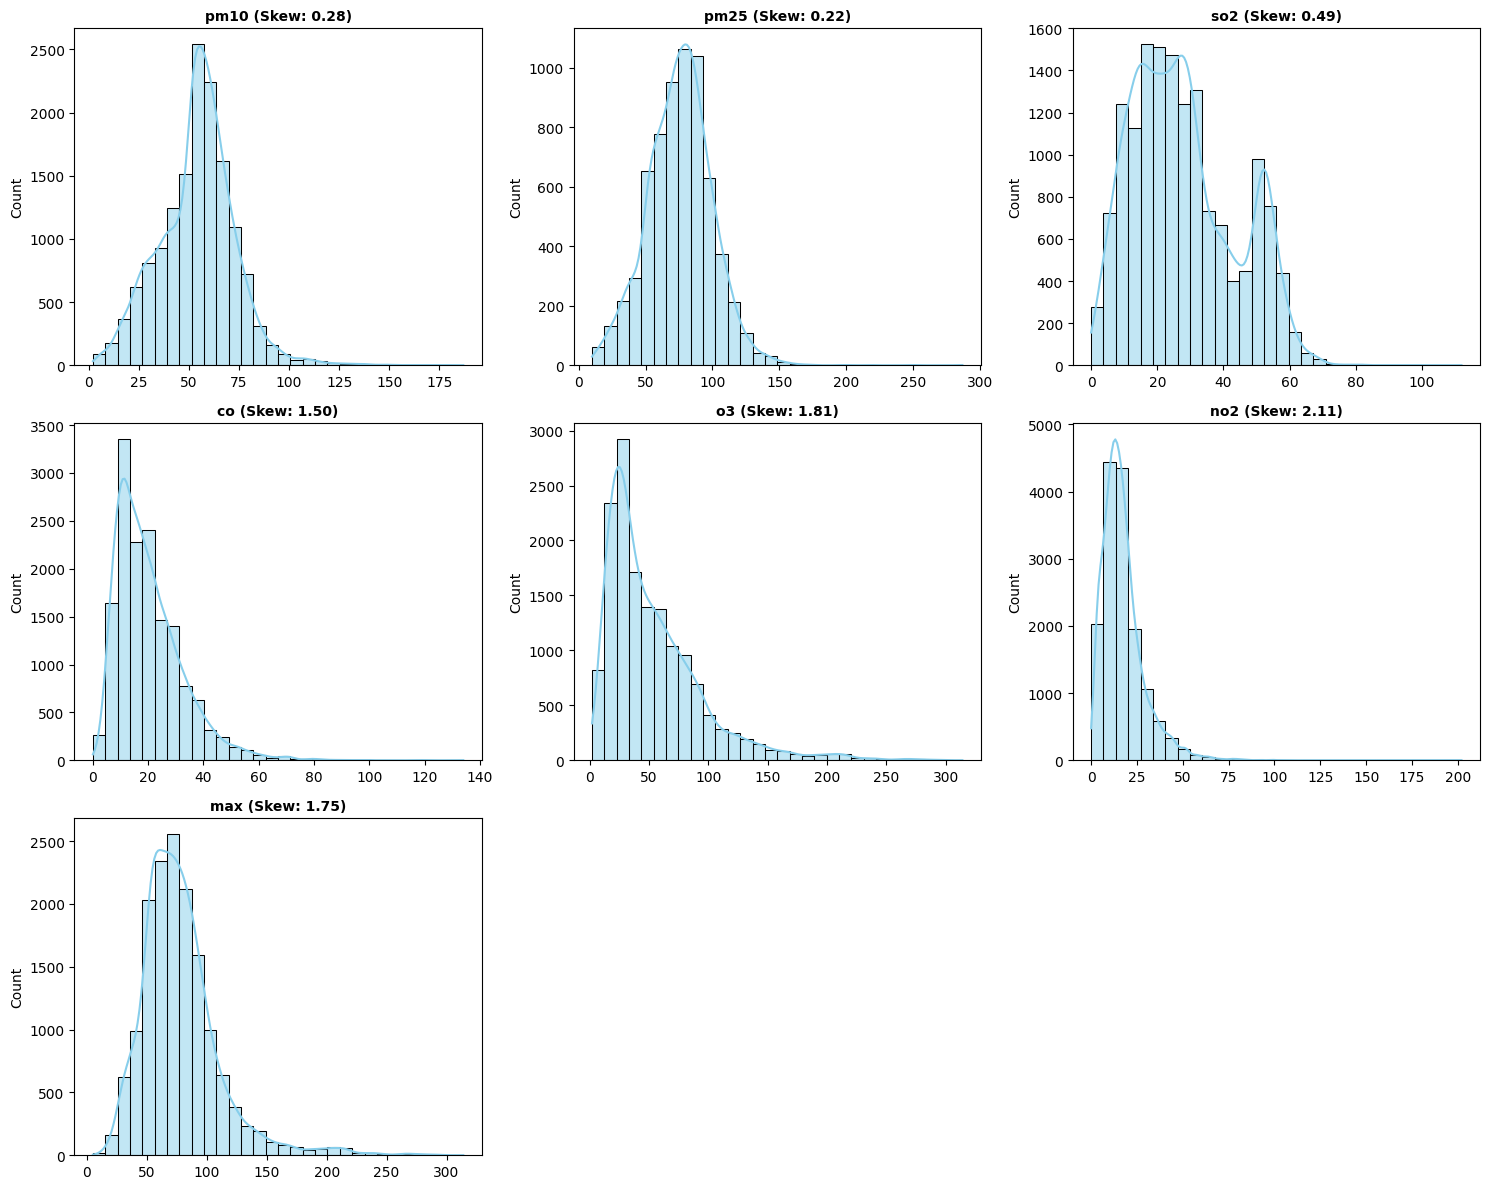

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Konfigurasi plot grid
n_cols = 3
n_rows = math.ceil(len(num_col) / n_cols)

plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(num_col):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Plot Histogram dengan KDE (Kernel Density Estimate)
    sns.histplot(df_ispu_full[col], kde=True, bins=30, color='skyblue')
    
    # Judul dengan nilai Skewness
    skew_val = df_ispu_full[col].skew()
    plt.title(f'{col} (Skew: {skew_val:.2f})', fontsize=10, fontweight='bold')
    plt.xlabel('')
    
plt.tight_layout()
plt.show()

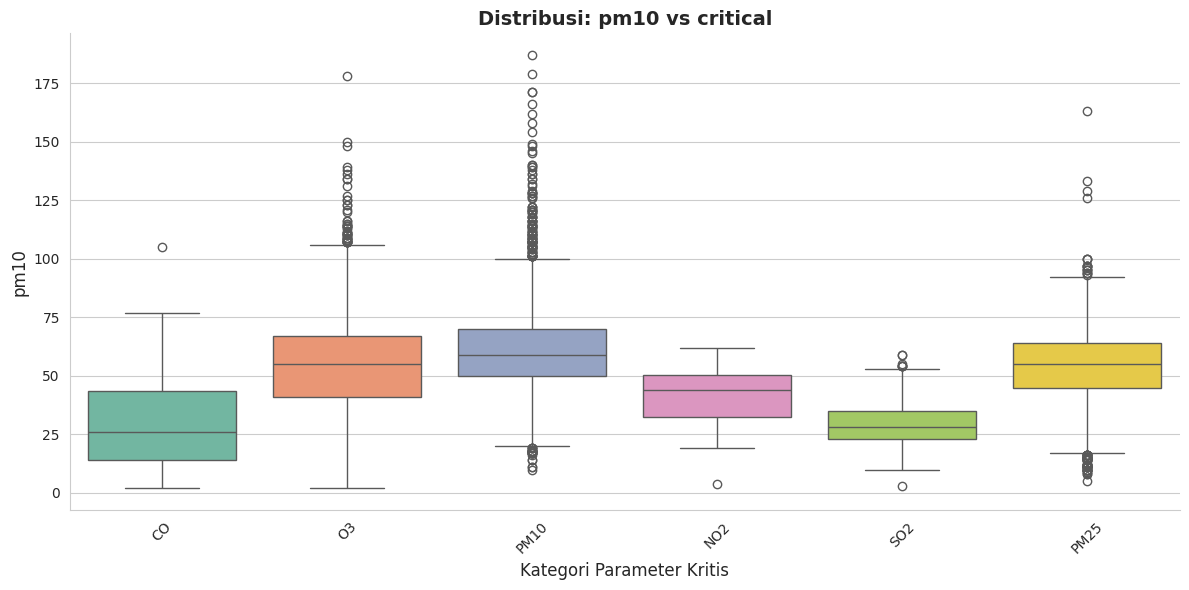

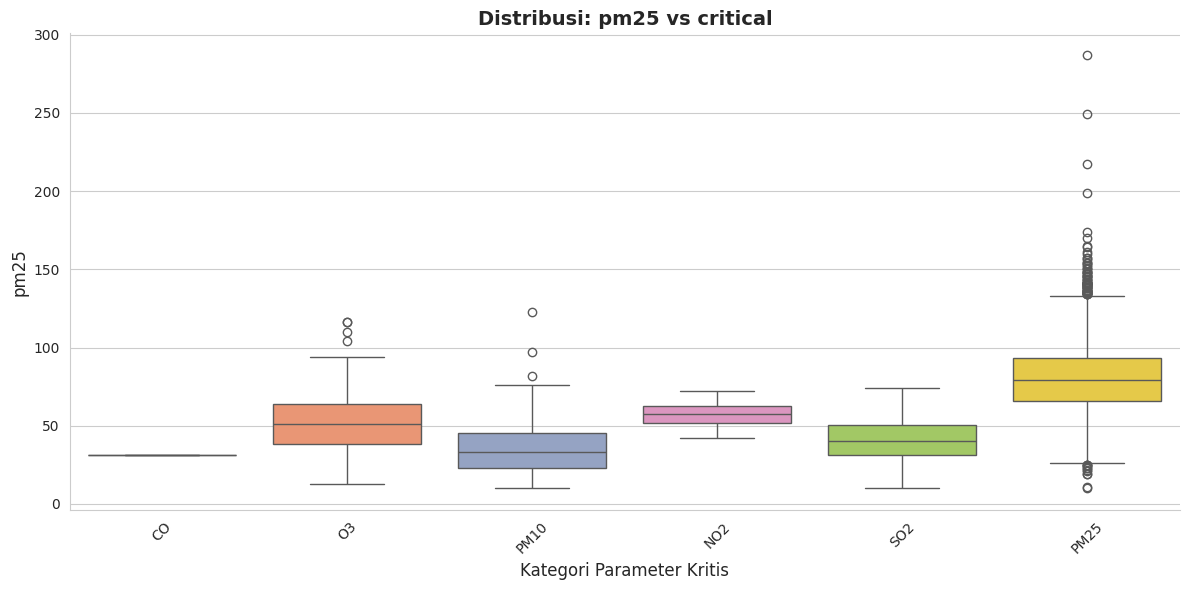

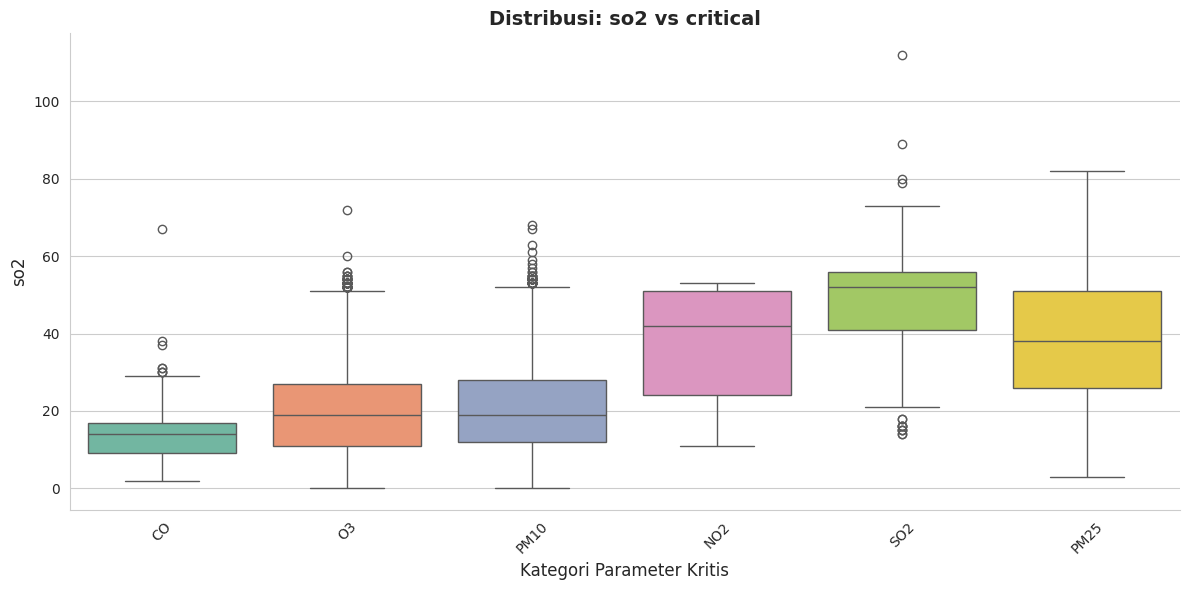

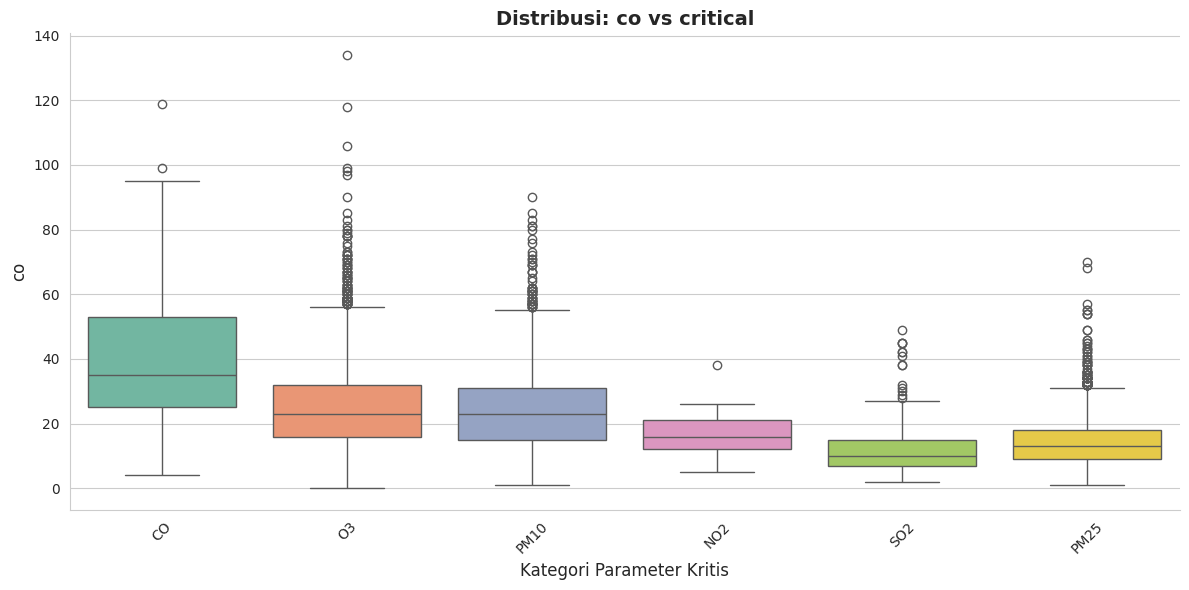

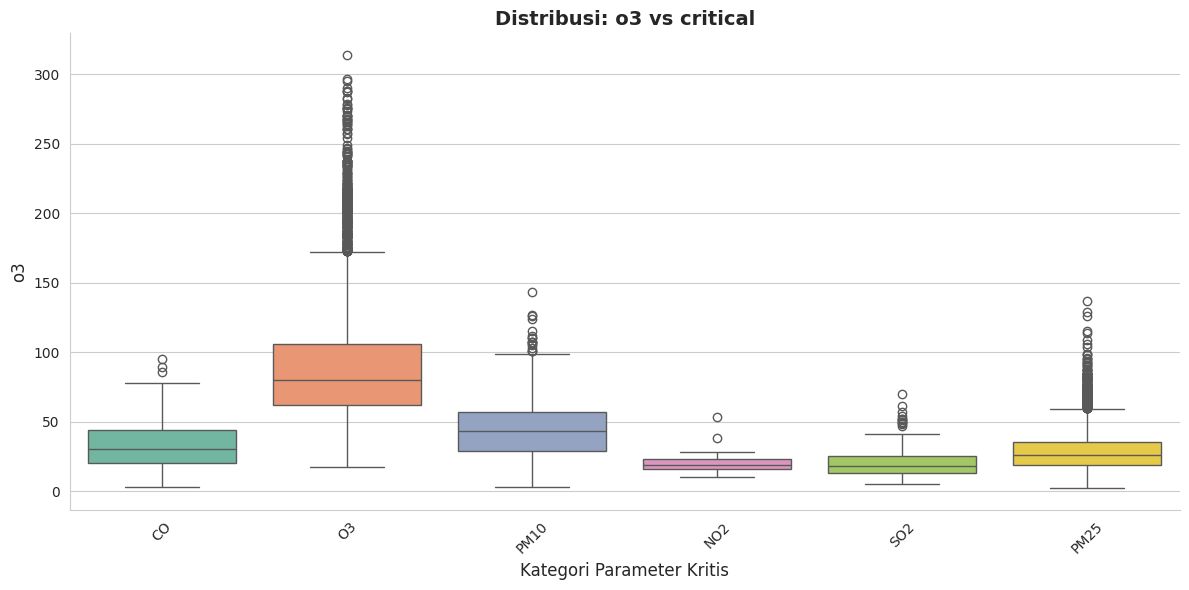

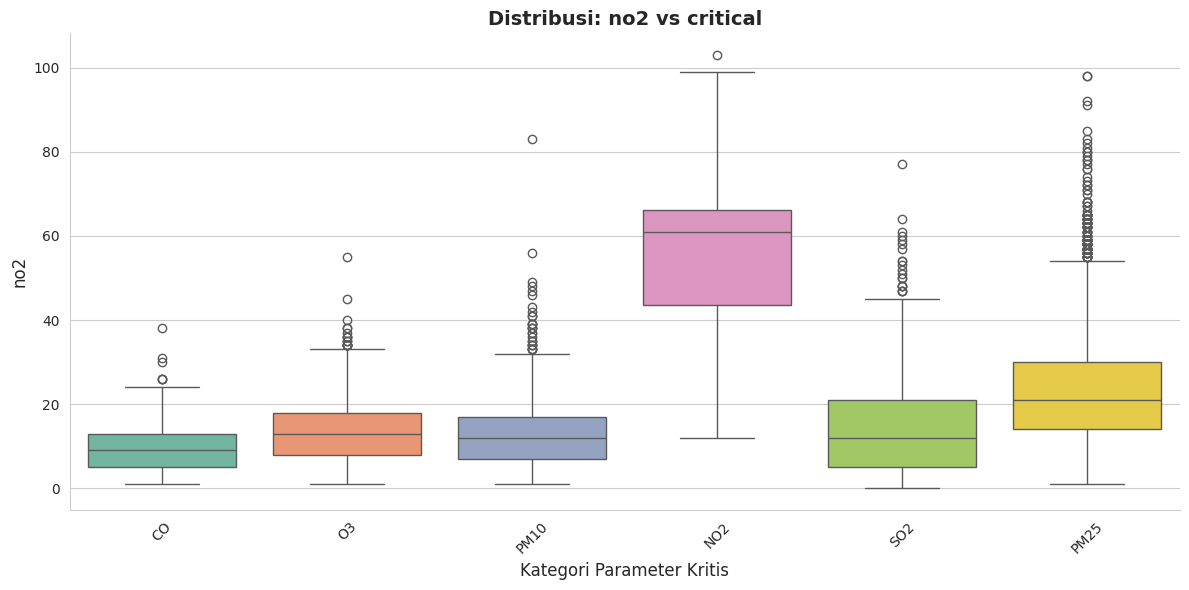

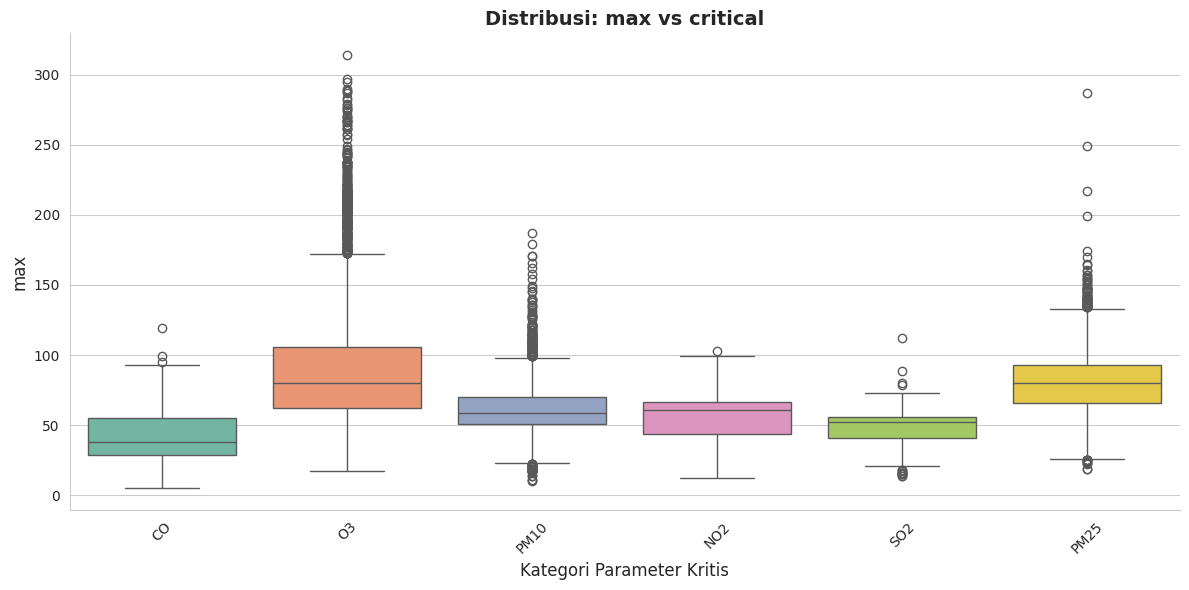

In [45]:
# Konfigurasi Style
sns.set_style("whitegrid")

# Loop Plotting (Menggunakan Box Plot)
for col in num_col:
    plt.figure(figsize=(12, 6))
    
    # Membuat Box Plot
    # Box plot menunjukkan Median (garis tengah), Interquartile Range (kotak), dan Outlier (titik)
    sns.boxplot(data=df_ispu_full, 
                x='critical', 
                y=col, 
                palette="Set2") # Konsisten menggunakan Set2
    
    plt.title(f"Distribusi: {col} vs critical", fontsize=14, fontweight='bold')
    plt.xlabel("Kategori Parameter Kritis", fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.xticks(rotation=45) # Rotasi label agar terbaca jelas
    
    # Menghilangkan batas atas dan kanan
    sns.despine()
    
    plt.tight_layout()
    plt.show()

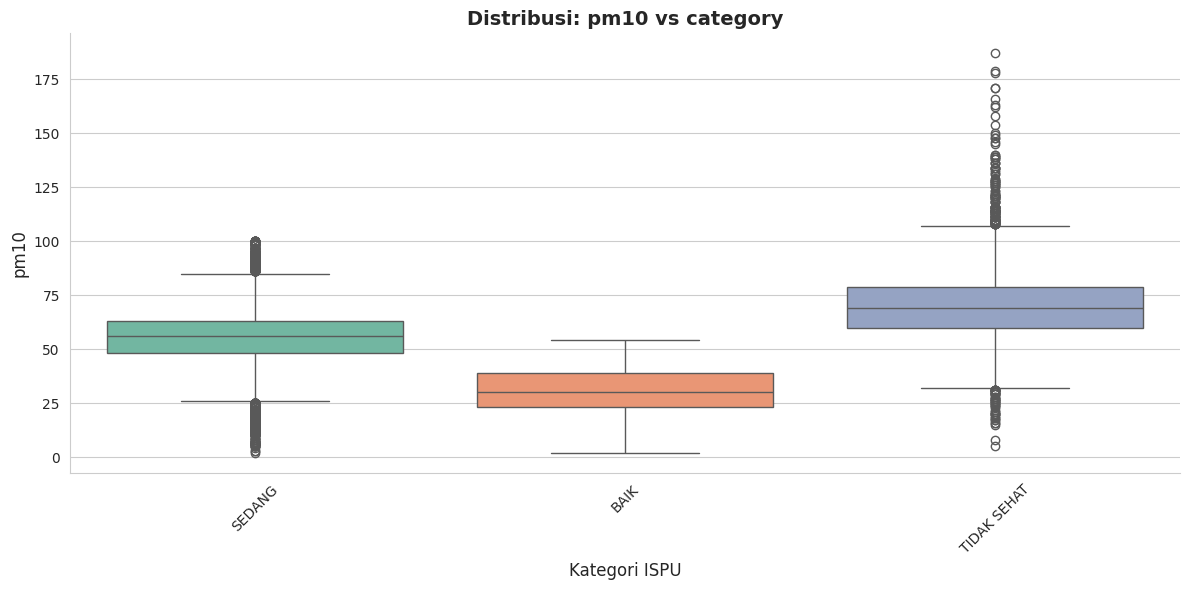

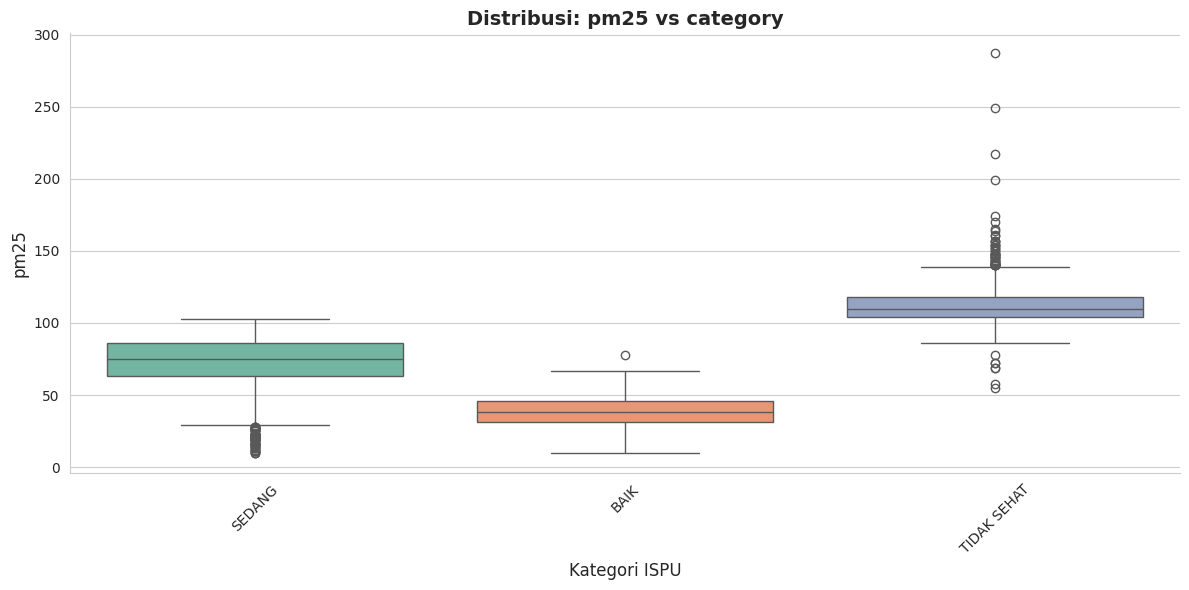

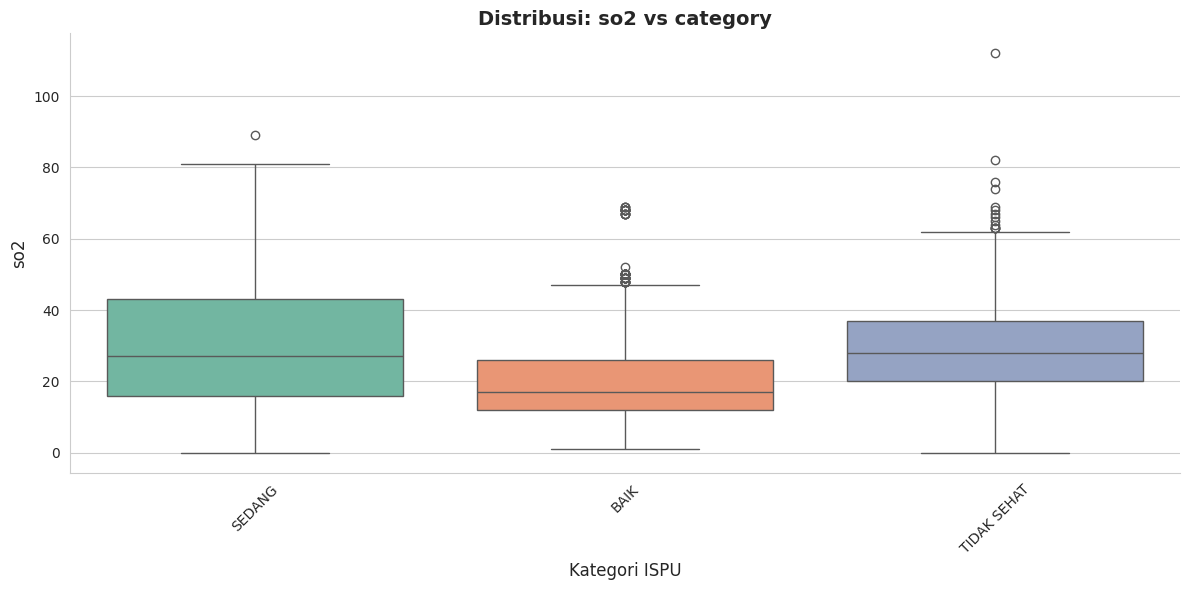

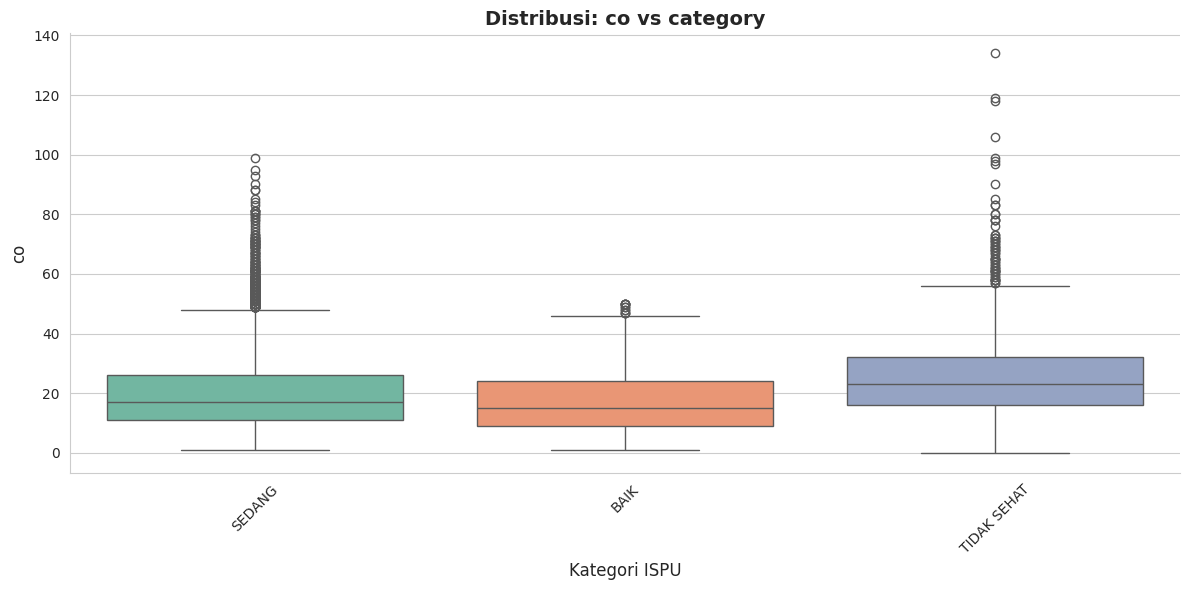

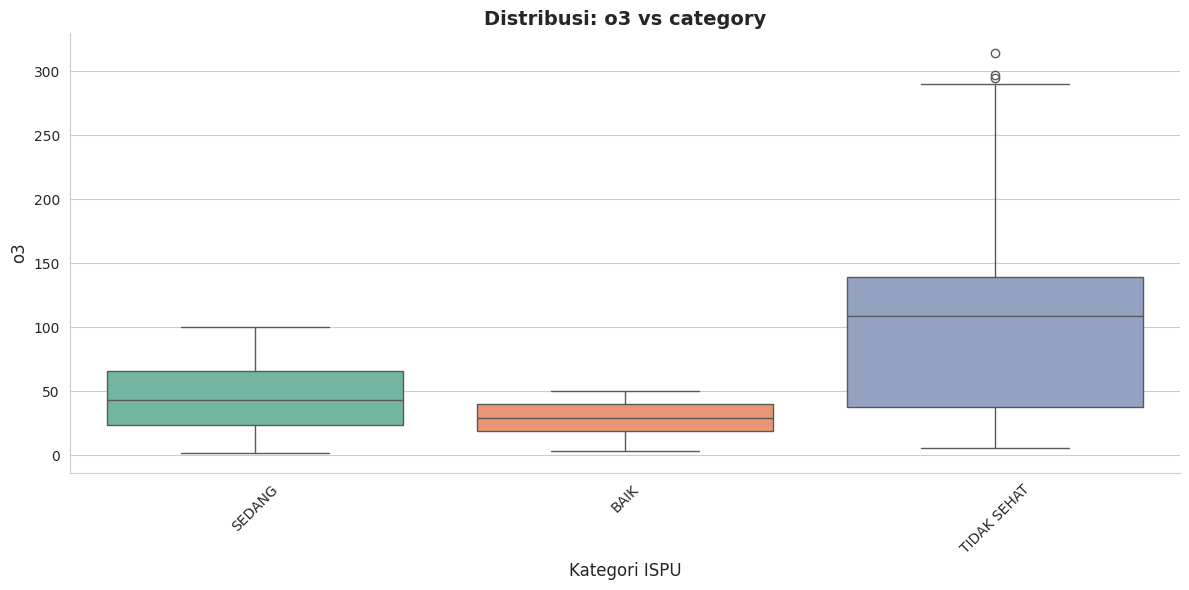

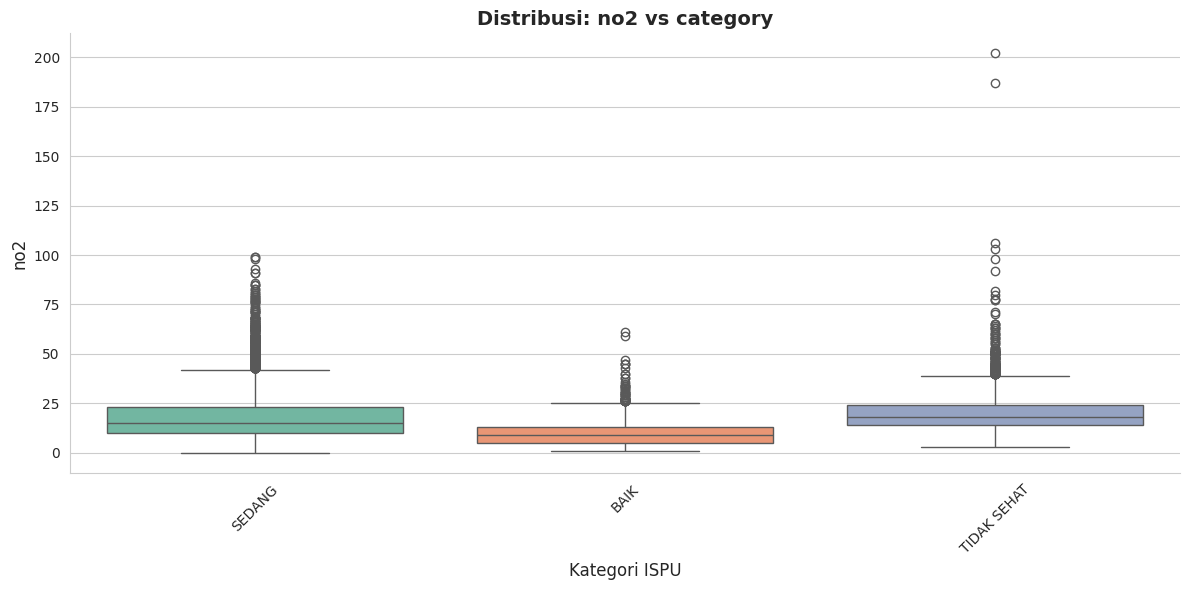

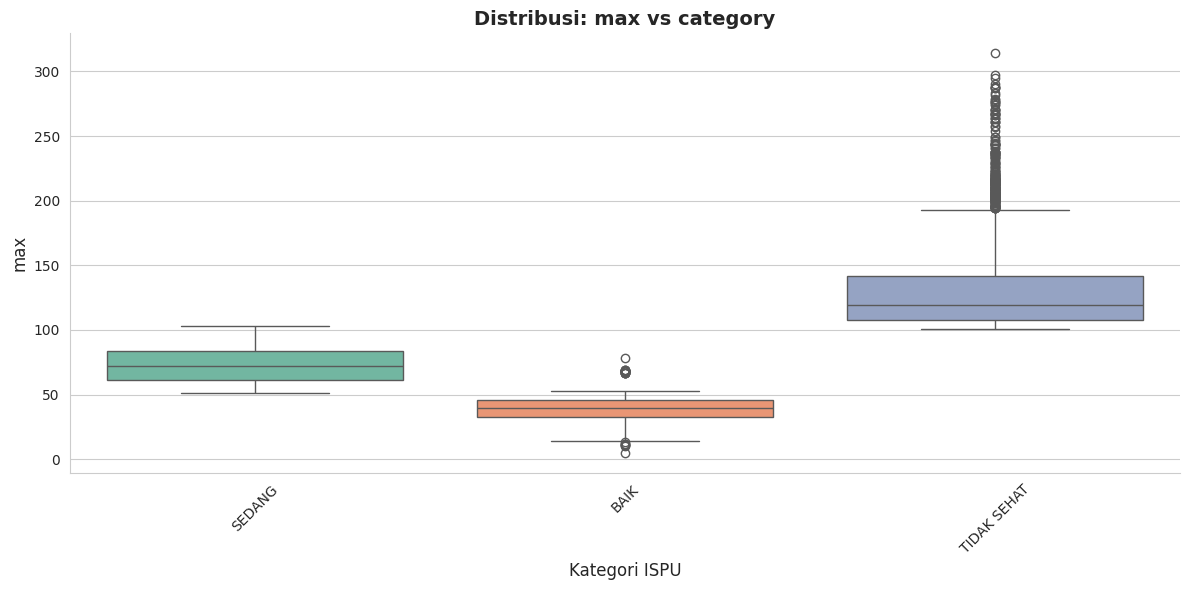

In [46]:
# Konfigurasi Style
sns.set_style("whitegrid")

# Loop Plotting (Menggunakan Box Plot)
for col in num_col:
    plt.figure(figsize=(12, 6))
    
    # Membuat Box Plot
    # Box plot menunjukkan Median (garis tengah), Interquartile Range (kotak), dan Outlier (titik)
    sns.boxplot(data=df_ispu_full, 
                x=target_col, 
                y=col, 
                palette="Set2") # Konsisten menggunakan Set2
    
    plt.title(f"Distribusi: {col} vs {target_col}", fontsize=14, fontweight='bold')
    plt.xlabel("Kategori ISPU", fontsize=12)
    plt.ylabel(col, fontsize=12)
    plt.xticks(rotation=45) # Rotasi label agar terbaca jelas
    
    # Menghilangkan batas atas dan kanan
    sns.despine()
    
    plt.tight_layout()
    plt.show()

--- lokasi_spku ---
lokasi_spku
DKI4    21.92%
DKI2    20.51%
DKI5    19.57%
DKI3    19.41%
DKI1    18.59%
Name: proportion, dtype: object


--- critical ---
critical
PM25    38.83%
O3      35.96%
PM10    20.07%
SO2      3.29%
CO       1.71%
NO2      0.14%
Name: proportion, dtype: object




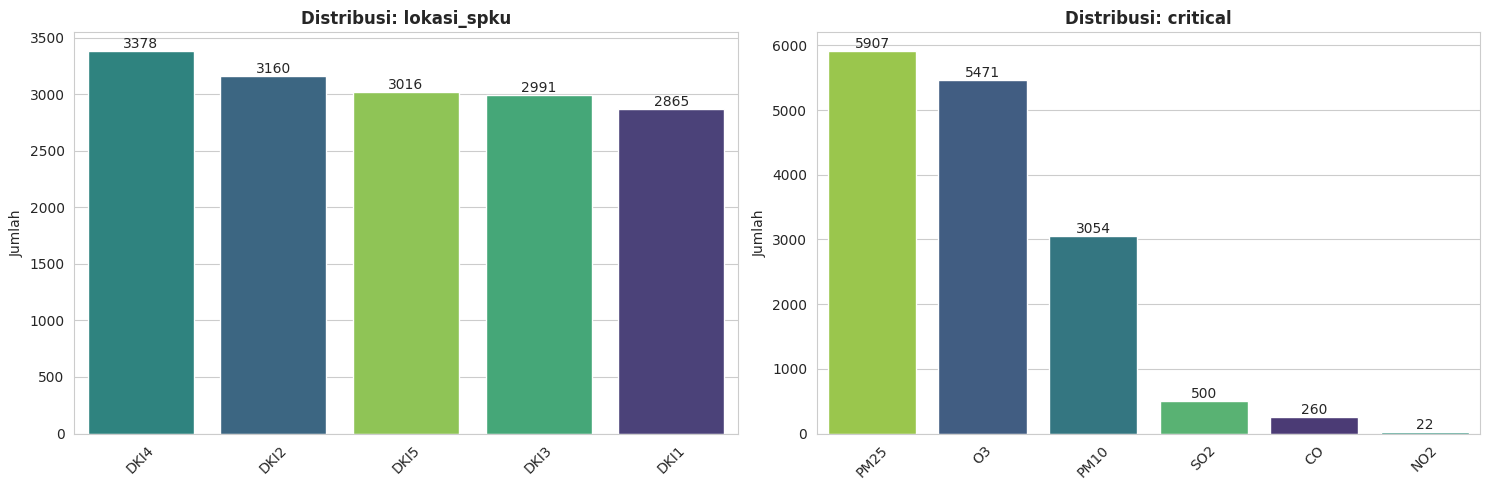

In [47]:
# Daftar kolom kategorikal yang ingin dicek
cat_cols_to_plot = ['lokasi_spku', 'critical']

# Konfigurasi Grid Plot (2 kolom per baris)
n_cols_plot = 2
n_rows_plot = math.ceil(len(cat_cols_to_plot) / n_cols_plot)

plt.figure(figsize=(15, 5 * n_rows_plot))

for i, col in enumerate(cat_cols_to_plot):
    # 1. Visualisasi Bar Chart
    plt.subplot(n_rows_plot, n_cols_plot, i + 1)
    
    # Hitung urutan berdasarkan jumlah terbanyak agar grafik rapi
    order = df_ispu_full[col].value_counts().index
    
    ax = sns.countplot(data=df_ispu_full, x=col, order=order, palette='viridis', hue=col, legend=False)
    plt.title(f'Distribusi: {col}', fontsize=12, fontweight='bold')
    plt.xlabel('')
    plt.ylabel('Jumlah')
    plt.xticks(rotation=45) # Rotasi label agar tidak bertumpuk
    
    # Menambahkan angka jumlah di atas batang
    for container in ax.containers:
        ax.bar_label(container)

    # 2. Print Statistik Persentase di bawah plot (Text Output)
    print(f"--- {col} ---")
    print(df_ispu_full[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
    print("\n")

plt.tight_layout()
plt.show()

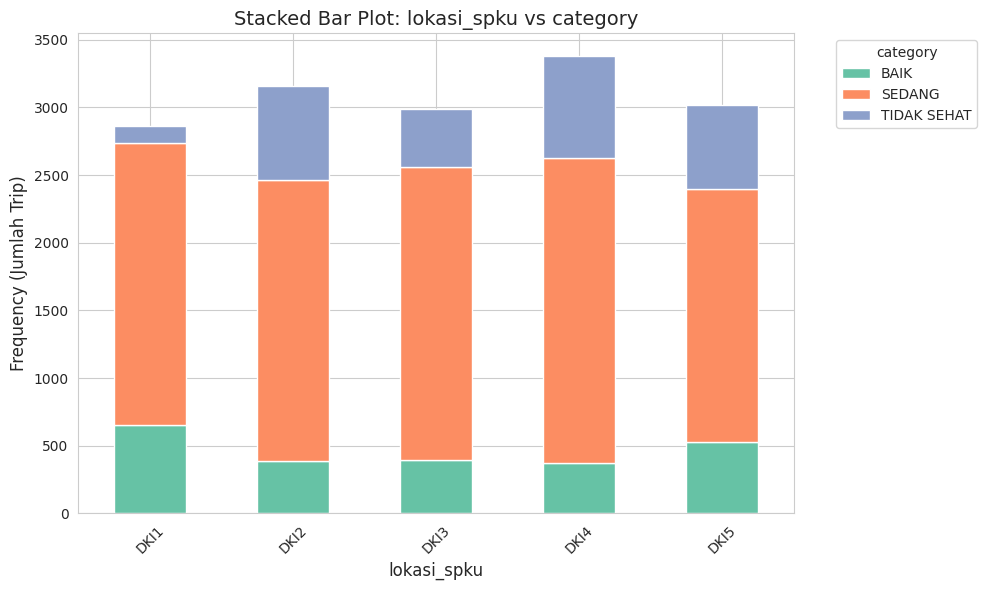

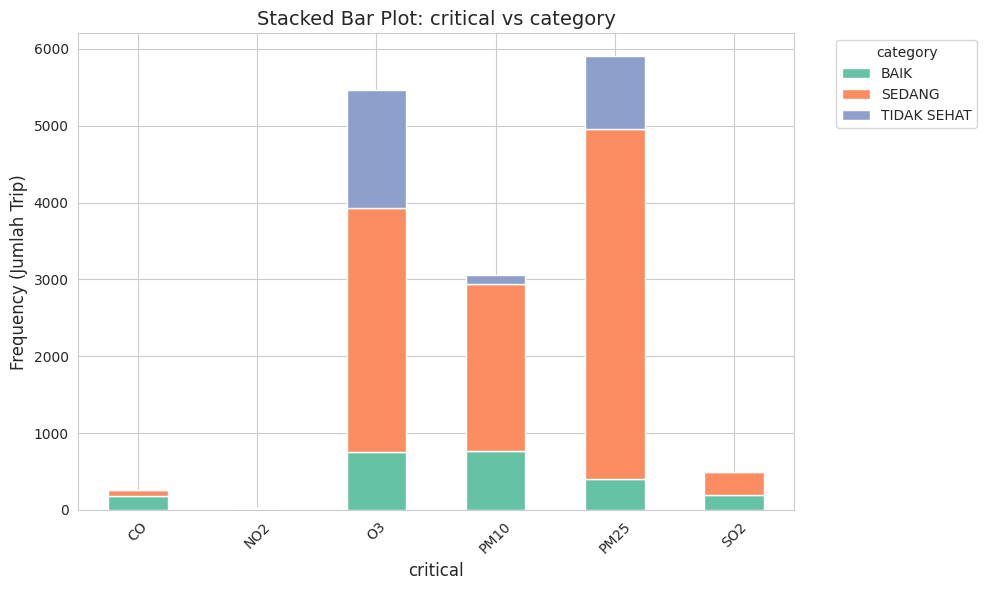

In [48]:
target_col = 'category' # Pastikan variabel ini terdefinisi
cat_col_to_plot = ['lokasi_spku', 'critical']

# 1. Definisikan urutan logis (Aman -> Bahaya)
category_order = ['BAIK', 'SEDANG', 'TIDAK SEHAT']

# Update jumlah warna sesuai target
unique_targets = df_ispu_full[target_col].nunique()
custom_colors = sns.color_palette("Set2", unique_targets)

for col in cat_col_to_plot:
    # Membuat Crosstab
    cross_tab = pd.crosstab(df_ispu_full[col], df_ispu_full[target_col])
    
    # 2. Urutkan kolom crosstab berdasarkan list manual
    # Hanya ambil kategori yang benar-benar ada di data saat ini untuk menghindari error
    existing_order = [cat for cat in category_order if cat in cross_tab.columns]
    cross_tab = cross_tab[existing_order]
    
    # Plotting
    ax = cross_tab.plot(kind='bar', stacked=True, color=custom_colors, figsize=(10, 6))
    
    plt.title(f"Stacked Bar Plot: {col} vs {target_col}", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Frequency (Jumlah Trip)", fontsize=12)
    plt.xticks(rotation=45)
    
    # Legend
    plt.legend(title=target_col, bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

In [49]:
# 1. Siapkan Data Agregasi
target_counts = df_ispu_full[target_col].value_counts().reset_index()
target_counts.columns = [target_col, 'Count']

# --- PROSES PENGURUTAN KATEGORI ---
custom_order = ['BAIK', 'SEDANG', 'TIDAK SEHAT']

# Ubah ke tipe Categorical agar bisa di-sort sesuai urutan logis (bukan abjad/jumlah)
target_counts[target_col] = pd.Categorical(target_counts[target_col], categories=custom_order, ordered=True)
target_counts = target_counts.sort_values(target_col)
# ----------------------------------

# 2. Membuat Interactive Pie Chart
fig = px.pie(
    target_counts, 
    values='Count', 
    names=target_col,
    title=f'Distribusi Kelas Target: {target_col}',
    
    # Menggunakan palet warna pastel
    color_discrete_sequence=px.colors.qualitative.Pastel, 
    
    # Menjamin konsistensi mapping warna terhadap urutan kategori
    category_orders={target_col: custom_order},
    
    hole=0.4 
)

# 3. Kustomisasi Tampilan
fig.update_traces(
    textposition='inside', 
    textinfo='percent+label', 
    hoverinfo='label+value+percent', 
    marker=dict(line=dict(color='#000000', width=1)),
    
    # PENTING: Matikan sorting otomatis by value, agar mengikuti urutan dataframe
    sort=False 
)

fig.update_layout(
    annotations=[dict(text='Total Data', x=0.5, y=0.5, font_size=12, showarrow=False)]
)

fig.show()

In [50]:
# 1. Pilih Hanya Kolom Numerik
# Kita otomatis memilih kolom bertipe angka agar kode ini robust
df_copy = df_ispu_full.copy()
df_copy['category'] = df_copy['category'].replace({"TIDAK SEHAT":0, "SEDANG": 1, "BAIK":2})
numeric_df = df_copy.select_dtypes(include=[np.number])

# 2. Hitung Matriks Korelasi
corr_matrix = numeric_df.corr().round(2) # Pembulatan 2 desimal agar rapi

# 3. Membuat Interactive Heatmap
fig = px.imshow(
    corr_matrix,
    text_auto=True,              # Menampilkan angka korelasi di dalam kotak
    aspect="auto",               # Menyesuaikan rasio aspek agar kotak tidak gepeng
    color_continuous_scale='RdBu_r', # Warna Merah-Biru (Merah=Positif, Biru=Negatif)
    zmin=-1, zmax=1,             # Mengunci skala warna dari -1 hingga 1
    title="Interactive Correlation Matrix"
)

# 4. Kustomisasi Tampilan
fig.update_layout(
    width=1000, 
    height=1000,
    autosize=False
)

# Menghilangkan axis labels jika terlalu panjang/banyak agar lebih bersih
# (Opsional: Hapus baris di bawah ini jika ingin tetap melihat label sumbu X/Y)
fig.update_xaxes(side="bottom")

fig.show()

In [51]:
# Informasi NDVI
df_ndvi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1810 entries, 0 to 1809
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   tanggal      1810 non-null   datetime64[ns]
 1   lokasi_spku  1810 non-null   object        
 2   ndvi         1810 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 42.6+ KB


In [52]:
df_ndvi.describe().T

,count,mean,min,25%,50%,75%,max,std
tanggal,1810,2017-10-22 16:58:20.552485888,2009-12-19 00:00:00,2013-11-17 00:00:00,2017-10-24 00:00:00,2021-09-30 00:00:00,2025-08-29 00:00:00,NaN
ndvi,1810.0,0.342735,0.0138,0.2295,0.33925,0.4642,0.7521,0.142849


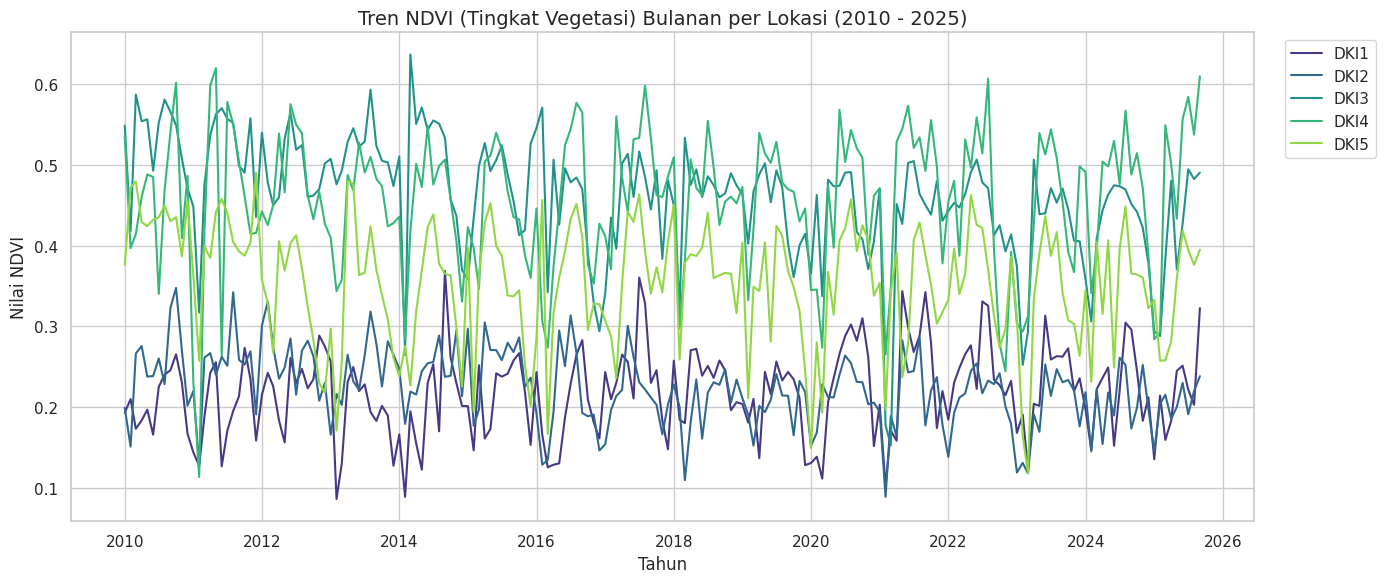

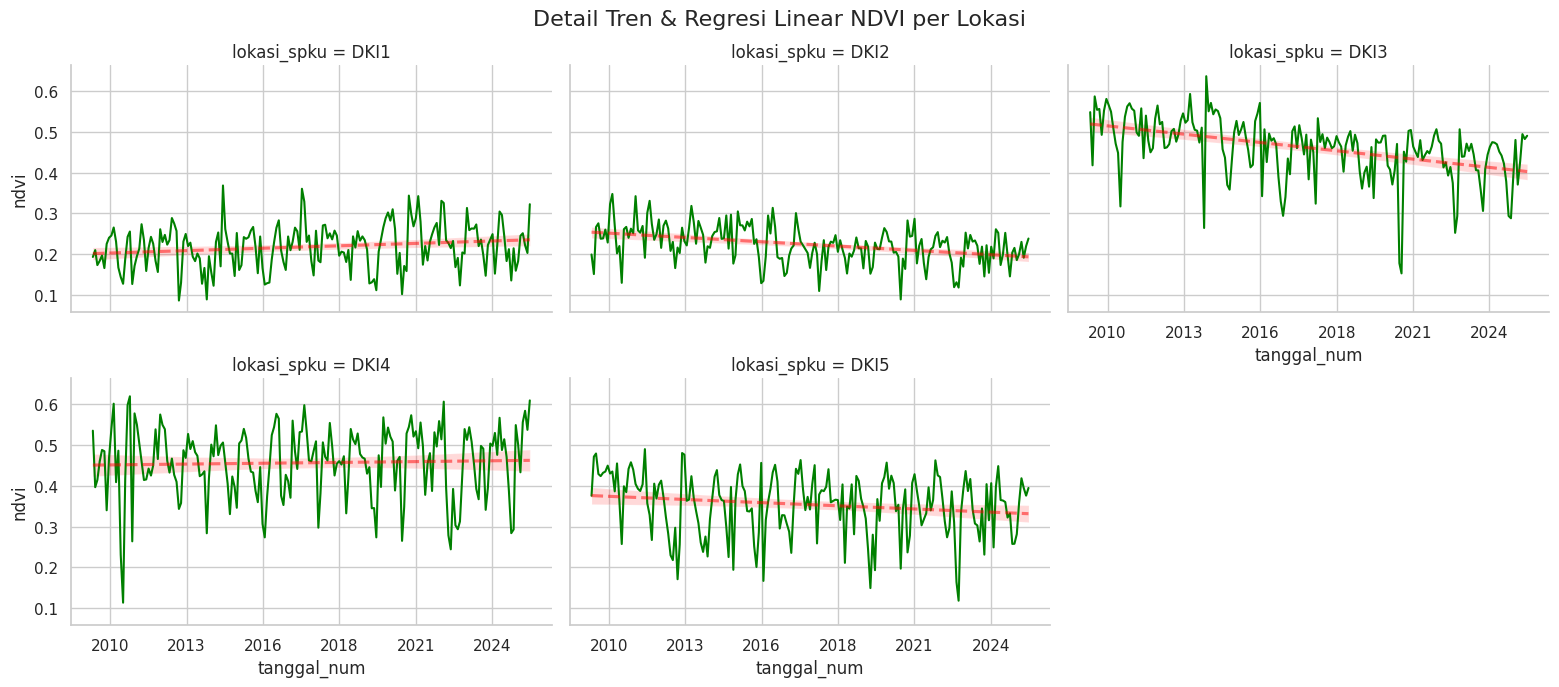

In [53]:
import datetime as dt
# Konfigurasi Style
sns.set(style="whitegrid")

# 1. Agregasi Data ke Level Bulanan
# Kita ambil rata-rata bulanan agar grafik lebih bersih
df_trend = df_ndvi_daily.set_index('tanggal').groupby('lokasi_spku')['ndvi'].resample('M').mean().reset_index()

# 2. Buat Kolom Angka untuk Tanggal (PENTING untuk Regresi)
# Mengubah datetime menjadi angka ordinal agar sns.regplot bisa menghitung matematika garisnya
df_trend['tanggal_num'] = df_trend['tanggal'].map(pd.Timestamp.toordinal)

# --- Visualisasi 1: Plot Gabungan (Overview) ---
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_trend, x='tanggal', y='ndvi', hue='lokasi_spku', palette='viridis', linewidth=1.5)
plt.title('Tren NDVI (Tingkat Vegetasi) Bulanan per Lokasi (2010 - 2025)', fontsize=14)
plt.ylabel('Nilai NDVI')
plt.xlabel('Tahun')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Visualisasi 2: Detail per Lokasi dengan Regresi (FIXED) ---
# Gunakan FacetGrid untuk memisahkan grafik per lokasi
g = sns.FacetGrid(df_trend, col="lokasi_spku", col_wrap=3, height=3.5, aspect=1.5, sharey=True)

# A. Plot Garis Data Asli (Hijau) - Gunakan 'tanggal_num' agar konsisten dengan regplot
g.map(sns.lineplot, "tanggal_num", "ndvi", color="green", linewidth=1.5)

# B. Plot Garis Regresi (Merah) - Menggunakan 'tanggal_num' (angka) untuk menghindari UFuncTypeError
g.map(sns.regplot, "tanggal_num", "ndvi", scatter=False, color="red", line_kws={"linestyle": "--", "alpha": 0.5})

# C. Perbaikan Label Sumbu X (Kembalikan Angka ke Format Tahun)
for ax in g.axes.flat:
    # Ambil posisi ticks saat ini (yang berupa angka ordinal)
    xticks = ax.get_xticks()
    
    # Ubah angka ordinal kembali menjadi string Tahun
    new_labels = []
    for x in xticks:
        try:
            # Konversi ordinal ke tahun
            year_label = dt.date.fromordinal(int(x)).strftime('%Y')
            new_labels.append(year_label)
        except (ValueError, OverflowError):
            new_labels.append("") # Handle jika angka di luar range valid
            
    # Terapkan label baru
    ax.set_xticklabels(new_labels)

g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Detail Tren & Regresi Linear NDVI per Lokasi', fontsize=16)
plt.show()

In [54]:
df_cuaca_dki1.columns

Index(['time', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'precipitation_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_max (km/h)', 'wind_direction_10m_dominant (°)',
       'shortwave_radiation_sum (MJ/m²)', 'temperature_2m_mean (°C)',
       'relative_humidity_2m_mean (%)', 'cloud_cover_mean (%)',
       'surface_pressure_mean (hPa)', 'wind_gusts_10m_max (km/h)',
       'winddirection_10m_dominant (°)', 'relative_humidity_2m_max (%)',
       'relative_humidity_2m_min (%)', 'cloud_cover_max (%)',
       'cloud_cover_min (%)', 'wind_gusts_10m_mean (km/h)',
       'wind_speed_10m_mean (km/h)', 'wind_gusts_10m_min (km/h)',
       'wind_speed_10m_min (km/h)', 'surface_pressure_max (hPa)',
       'surface_pressure_min (hPa)'],
      dtype='object')

In [55]:
cuaca_hourly_dki1.columns

Index(['time', 'precipitation (mm)', 'temperature_2m (?øC)',
       'wind_speed_100m (km/h)', 'wind_direction_100m (?ø)',
       'wind_gusts_10m (km/h)', 'relative_humidity_2m (%)',
       'dew_point_2m (?øC)', 'apparent_temperature (?øC)',
       'weather_code (wmo code)', 'pressure_msl (hPa)',
       'surface_pressure (hPa)', 'cloud_cover (%)', 'cloud_cover_low (%)',
       'cloud_cover_mid (%)', 'cloud_cover_high (%)',
       'et0_fao_evapotranspiration (mm)', 'vapour_pressure_deficit (kPa)',
       'wind_speed_10m (km/h)', 'wind_direction_10m (?ø)',
       'soil_temperature_0_to_7cm (?øC)', 'soil_temperature_7_to_28cm (?øC)',
       'soil_temperature_28_to_100cm (?øC)',
       'soil_temperature_100_to_255cm (?øC)',
       'soil_moisture_0_to_7cm (m??/m??)', 'soil_moisture_7_to_28cm (m??/m??)',
       'soil_moisture_28_to_100cm (m??/m??)',
       'soil_moisture_100_to_255cm (m??/m??)',
       'shortwave_radiation_instant (W/m?ý)',
       'direct_radiation_instant (W/m?ý)', 'diffuse_

# **5. Feature Engineering**

In [56]:
def time_features(_df:pd.DataFrame) -> pd.DataFrame:
    df = _df.copy()
    time = pd.to_datetime(df['time'])
    
    df['year'] = time.dt.year
    df['month'] = time.dt.month
    df['day_year'] = time.dt.day_of_year
    df['day_week'] = time.dt.day_of_week
    df['day'] = time.dt.day
    df['time'] = time
    
    for time, col in zip([df['month'], df['day_year'], df['day_week'], df['day']], ['month', 'day_year', 'dw', 'dm']):
        time_range = {
            'month': 12,
            'day_year': 366,
            'dw': 7,
            'dm': 31,
        }

        df[f'time_{col}_sin'] = np.sin(time * (2 * np.pi / time_range[col]))
        df[f'time_{col}_cos'] = np.cos(time * (2 * np.pi / time_range[col]))
    
    return df

In [57]:
df_cuaca_dki1 = df_cuaca_dki1.pipe(time_features)
df_cuaca_dki2 = df_cuaca_dki2.pipe(time_features)
df_cuaca_dki3 = df_cuaca_dki3.pipe(time_features)
df_cuaca_dki4 = df_cuaca_dki4.pipe(time_features)
df_cuaca_dki5 = df_cuaca_dki5.pipe(time_features)

In [58]:
def wind_features_hour(_df:pd.DataFrame) -> pd.DataFrame:
    df = _df.copy()
    feature_1 = df['wind_speed_10m (km/h)']
    feature_1_1 = np.radians(df['wind_direction_10m (?ø)'])
    feature_2_1 = df['wind_speed_100m (km/h)']
    feature_2_2 = np.radians(df['wind_direction_100m (?ø)'])
    
    df["wind_speed_10m_x"] = feature_1 * np.cos(feature_1_1)
    df["wind_speed_10m_y"] = feature_1 * np.sin(feature_1_1)
    df["wind_speed_100m_x"] = feature_2_1 * np.cos(feature_2_2)
    df["wind_speed_100m_y"] = feature_2_1 * np.sin(feature_2_2)
    
    return df

def wind_features_day(_df:pd.DataFrame) -> pd.DataFrame:
    df = _df.copy()
    feature_1 = df['wind_speed_10m_max (km/h)']
    feature_1_1 = np.radians(df['wind_direction_10m_dominant (°)'])
    
    df["wind_speed_10m_max_x"] = feature_1 * np.cos(feature_1_1)
    df["wind_speed_10m_max_y"] = feature_1 * np.sin(feature_1_1)
    
    return df

In [59]:
df_cuaca_dki1 = df_cuaca_dki1.pipe(wind_features_day)
df_cuaca_dki2 = df_cuaca_dki2.pipe(wind_features_day)
df_cuaca_dki3 = df_cuaca_dki3.pipe(wind_features_day)
df_cuaca_dki4 = df_cuaca_dki4.pipe(wind_features_day)
df_cuaca_dki5 = df_cuaca_dki5.pipe(wind_features_day)

In [60]:
cuaca_hourly_dki1 = cuaca_hourly_dki1.pipe(wind_features_hour)
cuaca_hourly_dki2 = cuaca_hourly_dki2.pipe(wind_features_hour)
cuaca_hourly_dki3 = cuaca_hourly_dki3.pipe(wind_features_hour)
cuaca_hourly_dki4 = cuaca_hourly_dki4.pipe(wind_features_hour)
cuaca_hourly_dki5 = cuaca_hourly_dki5.pipe(wind_features_hour)

In [61]:
def feature_engineering_single_df(df_input: pd.DataFrame, time_col='time') -> pd.DataFrame:
    df = df_input.copy()
    
    if time_col in df.columns:
        df = df.sort_values(by=time_col).reset_index(drop=True)
    else:
        print(f"Peringatan: Kolom '{time_col}' tidak ditemukan. Pastikan nama kolom waktu sesuai.")

    for col in df.select_dtypes(include=['float64', 'float32', 'int64']).columns:
        
        if col == time_col:
            continue

        for lag in range(-4, 5):
            if lag != 0:
                col_name = f'{col}_diff_lag_{lag}' 
                df[col_name] = df[col] - df[col].shift(lag)

    df = df.ffill().bfill()
    
    return df

In [62]:
all_datasets = {
    'df_cuaca_dki1': df_cuaca_dki1,
    'df_cuaca_dki2': df_cuaca_dki2,
    'df_cuaca_dki3': df_cuaca_dki3,
    'df_cuaca_dki4': df_cuaca_dki4,
    'df_cuaca_dki5': df_cuaca_dki5,
    'cuaca_hourly_dki1': cuaca_hourly_dki1,
    'cuaca_hourly_dki2': cuaca_hourly_dki2,
    'cuaca_hourly_dki3': cuaca_hourly_dki3,
    'cuaca_hourly_dki4': cuaca_hourly_dki4,
    'cuaca_hourly_dki5': cuaca_hourly_dki5
}

processed_datasets = {}

for name, df in all_datasets.items():
    print(f"Sedang memproses: {name}...")
    
    processed_df = feature_engineering_single_df(df, time_col='time')
    
    processed_datasets[name] = processed_df

print("Selesai memproses semua data.")

df_cuaca_dki1 = processed_datasets['df_cuaca_dki1']
df_cuaca_dki2 = processed_datasets['df_cuaca_dki2']
df_cuaca_dki3 = processed_datasets['df_cuaca_dki3']
df_cuaca_dki4 = processed_datasets['df_cuaca_dki4']
df_cuaca_dki5 = processed_datasets['df_cuaca_dki5']

cuaca_hourly_dki1 = processed_datasets['cuaca_hourly_dki1']
cuaca_hourly_dki2 = processed_datasets['cuaca_hourly_dki2']
cuaca_hourly_dki3 = processed_datasets['cuaca_hourly_dki3']
cuaca_hourly_dki4 = processed_datasets['cuaca_hourly_dki4']
cuaca_hourly_dki5 = processed_datasets['cuaca_hourly_dki5']

Sedang memproses: df_cuaca_dki1...
Sedang memproses: df_cuaca_dki2...
Sedang memproses: df_cuaca_dki3...
Sedang memproses: df_cuaca_dki4...
Sedang memproses: df_cuaca_dki5...
Sedang memproses: cuaca_hourly_dki1...
Sedang memproses: cuaca_hourly_dki2...
Sedang memproses: cuaca_hourly_dki3...
Sedang memproses: cuaca_hourly_dki4...
Sedang memproses: cuaca_hourly_dki5...
Selesai memproses semua data.


In [63]:
def aggregate_hourly_merge(df_hourly, df_daily):
    df_hourly = df_hourly.copy()
    df_daily = df_daily.copy()

    df_hourly['time'] = pd.to_datetime(df_hourly['time'])
    df_daily['time'] = pd.to_datetime(df_daily['time'])

    df_hourly['date_key'] = df_hourly['time'].dt.floor('D')

    aggregation_functions = {
        'temperature_2m (?øC)': 'std',
        'relative_humidity_2m (%)': ['min', 'max', 'mean', 'std'],
        'dew_point_2m (?øC)': ['min', 'max', 'mean', 'std'],
        'apparent_temperature (?øC)': 'std',
        'pressure_msl (hPa)': ['min', 'max', 'mean', 'std'],
        'surface_pressure (hPa)': ['min', 'max', 'mean', 'std'],
        'cloud_cover (%)': ['min', 'max', 'mean', 'std'],
        'cloud_cover_low (%)': ['min', 'max', 'mean', 'std'],
        'cloud_cover_mid (%)': ['min', 'max', 'mean', 'std'],
        'cloud_cover_high (%)': ['min', 'max', 'mean', 'std'],
        'et0_fao_evapotranspiration (mm)': ['min', 'max', 'mean', 'std'],
        'vapour_pressure_deficit (kPa)': ['min', 'max', 'mean', 'std'],
        'wind_speed_10m (km/h)': ['min', 'mean', 'std'],
        'wind_speed_100m (km/h)': ['min', 'mean', 'std'],
        'wind_direction_10m (?ø)': ['min', 'max', 'mean', 'std'],
        'wind_direction_100m (?ø)': ['min', 'max', 'mean', 'std'],
        'wind_gusts_10m (km/h)': ['min', 'max', 'mean', 'std'],
        'soil_temperature_0_to_7cm (?øC)': ['min', 'max', 'mean', 'std'],
        'soil_temperature_7_to_28cm (?øC)': ['min', 'max', 'mean', 'std'],
        'soil_temperature_28_to_100cm (?øC)': ['min', 'max', 'mean', 'std'],
        'soil_temperature_100_to_255cm (?øC)': ['min', 'max', 'mean', 'std'],
        'soil_moisture_0_to_7cm (m³/m³)': ['min', 'max', 'mean', 'std'],
        'soil_moisture_7_to_28cm (m³/m³)': ['min', 'max', 'mean', 'std'],
        'soil_moisture_28_to_100cm (m³/m³)': ['min', 'max', 'mean', 'std'],
        'soil_moisture_100_to_255cm (m³/m³)': ['min', 'max', 'mean', 'std'],
        'shortwave_radiation_instant (W/m²)': ['min', 'max', 'mean', 'std'],
        'direct_radiation_instant (W/m²)': ['min', 'max', 'mean', 'std'],
        'diffuse_radiation_instant (W/m²)': ['min', 'max', 'mean', 'std'],
        'direct_normal_irradiance_instant (W/m²)': ['min', 'max', 'mean', 'std'],
        'terrestrial_radiation_instant (W/m²)': ['min', 'max', 'mean', 'std'],
        'wind_speed_100m_x': ['min', 'max', 'mean', 'std'],
        'wind_speed_100m_y': ['min', 'max', 'mean', 'std'],
        'wind_speed_10m_x': ['min', 'max', 'mean', 'std'],
        'wind_speed_10m_y': ['min', 'max', 'mean', 'std'],
    }

    valid_agg_funcs = {k: v for k, v in aggregation_functions.items() if k in df_hourly.columns}

    daily_aggregated = df_hourly.groupby('date_key').agg(valid_agg_funcs)
    daily_aggregated.columns = ['_'.join(col).strip('_') for col in daily_aggregated.columns]
    daily_aggregated = daily_aggregated.reset_index()

    final_df = pd.merge(
        df_daily, 
        daily_aggregated, 
        left_on='time',      
        right_on='date_key', 
        how='left'
    )

    if 'date_key' in final_df.columns:
        final_df.drop(columns=['date_key'], inplace=True)

    return final_df

In [64]:
final_dki1 = aggregate_hourly_merge(cuaca_hourly_dki1, df_cuaca_dki1)
final_dki2 = aggregate_hourly_merge(cuaca_hourly_dki2, df_cuaca_dki2)
final_dki3 = aggregate_hourly_merge(cuaca_hourly_dki3, df_cuaca_dki3)
final_dki4 = aggregate_hourly_merge(cuaca_hourly_dki4, df_cuaca_dki4)
final_dki5 = aggregate_hourly_merge(cuaca_hourly_dki5, df_cuaca_dki5)

In [65]:
df_cuaca = {
    'dki1': final_dki1,
    'dki2': final_dki2,
    'dki3': final_dki3,
    'dki4': final_dki4,
    'dki5': final_dki5
}

# **Experiment**

## **1. Metode "Climatology"**

In [66]:
df = df_ispu_full.copy()

df['tanggal'] = pd.to_datetime(df['tanggal'])
df['month'] = df['tanggal'].dt.month
df['day'] = df['tanggal'].dt.day

# Validasi pada tahun 2024
val_start_date = '2024-09-01'
val_end_date = '2024-11-30'

train_data = df[df['tanggal'] < val_start_date].copy()

val_data_original = df[(df['tanggal'] >= val_start_date) & 
                       (df['tanggal'] <= val_end_date)].copy()

feature_cols = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
val_data_blind = val_data_original[['tanggal', 'lokasi_spku', 'month', 'day']].copy()

print(f"Training Data Shape: {train_data.shape}")
print(f"Blind Validation Shape: {val_data_blind.shape}")
print("Kolom pada Blind Data (Fitur Sensor Hilang):", val_data_blind.columns.tolist())

Training Data Shape: (13582, 13)
Blind Validation Shape: (453, 4)
Kolom pada Blind Data (Fitur Sensor Hilang): ['tanggal', 'lokasi_spku', 'month', 'day']


In [67]:
def fill_features_with_climatology(train_df, target_df, feature_cols):
    """
    Mengisi fitur polutan di target_df menggunakan median dari train_df
    berdasarkan Lokasi, Bulan, dan Hari.
    """
    historical_medians = train_df.groupby(['lokasi_spku', 'month', 'day'])[feature_cols].median().reset_index()
    
    df_filled = target_df.merge(historical_medians, 
                                on=['lokasi_spku', 'month', 'day'], 
                                how='left')
    
    fallback_medians = train_df.groupby(['lokasi_spku'])[feature_cols].median()
    
    for col in feature_cols:
        df_filled[col] = df_filled.apply(
            lambda x: fallback_medians.loc[x['lokasi_spku'], col] if pd.isna(x[col]) else x[col], 
            axis=1
        )
        
    return df_filled

val_data_engineered = fill_features_with_climatology(train_data, val_data_blind, feature_cols)

print("Contoh Data Validasi setelah 'direkayasa' (Diisi fitur historis):")
display(val_data_engineered.head())

Contoh Data Validasi setelah 'direkayasa' (Diisi fitur historis):


,tanggal,lokasi_spku,month,day,pm10,pm25,so2,co,o3,no2
0,2024-09-01,DKI1,9.0,1.0,54.0,94.5,23.0,18.0,39.0,15.5
1,2024-09-01,DKI2,9.0,1.0,68.0,101.5,32.0,9.0,55.0,14.0
2,2024-09-01,DKI3,9.0,1.0,57.0,85.5,31.0,12.0,75.0,12.0
3,2024-09-01,DKI4,9.0,1.0,69.5,118.0,40.0,15.0,42.0,24.0
4,2024-09-01,DKI5,9.0,1.0,59.0,95.0,25.0,20.0,65.0,11.5


In [68]:
X_train = train_data[feature_cols].fillna(train_data[feature_cols].median()) # Handle NaN di train
y_train = train_data['max']

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Sedang melatih Random Forest...")
rf_model.fit(X_train, y_train)

X_val = val_data_engineered[feature_cols]

val_predictions_score = rf_model.predict(X_val)

def get_category(score):
    if score <= 50: return "BAIK"
    elif score <= 100: return "SEDANG"
    else: return "TIDAK SEHAT"

v_get_category = np.vectorize(get_category)
val_predictions_cat = v_get_category(val_predictions_score)

y_true = val_data_original['category']

score = f1_score(y_true, val_predictions_cat, average='macro')

print("="*40)
print(f"F1 Macro Score (Climatology Features + Random Forest): {score:.4f}")
print("="*40)
print("\nDetail Performa:")
print(classification_report(y_true, val_predictions_cat))

Sedang melatih Random Forest...
F1 Macro Score (Climatology Features + Random Forest): 0.3281

Detail Performa:
              precision    recall  f1-score   support

        BAIK       0.00      0.00      0.00        14
      SEDANG       0.89      0.86      0.87       403
 TIDAK SEHAT       0.09      0.14      0.11        36

    accuracy                           0.78       453
   macro avg       0.33      0.33      0.33       453
weighted avg       0.79      0.78      0.79       453



Sedang melatih Random Forest (Mode Regresi)...
HASIL EVALUASI REGRESI (Random Forest)
MAE  (Rata-rata Meleset)          : 17.5062
RMSE (Sensitif terhadap Error Besar): 23.3429
R2 Score (Kecocokan Pola 0-1)     : -0.8597


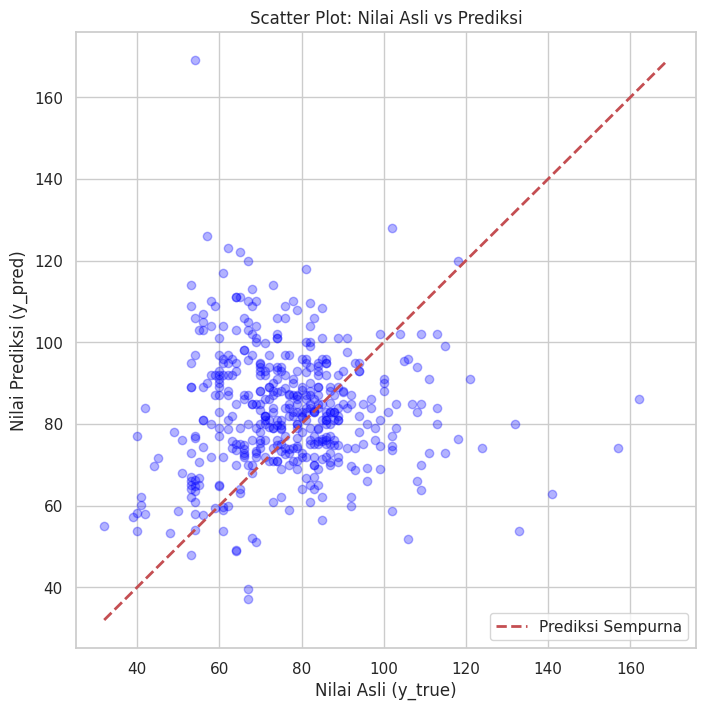

In [69]:
X_train = train_data[feature_cols].fillna(train_data[feature_cols].median())
y_train = train_data['max'] 

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

print("Sedang melatih Random Forest (Mode Regresi)...")
rf_model.fit(X_train, y_train)

X_val = val_data_engineered[feature_cols].fillna(train_data[feature_cols].median())
val_predictions_score = rf_model.predict(X_val)

y_true_numeric = val_data_original['max']

mae = mean_absolute_error(y_true_numeric, val_predictions_score)
rmse = np.sqrt(mean_squared_error(y_true_numeric, val_predictions_score))
r2 = r2_score(y_true_numeric, val_predictions_score)

print("="*50)
print(f"HASIL EVALUASI REGRESI (Random Forest)")
print("="*50)
print(f"MAE  (Rata-rata Meleset)          : {mae:.4f}")
print(f"RMSE (Sensitif terhadap Error Besar): {rmse:.4f}")
print(f"R2 Score (Kecocokan Pola 0-1)     : {r2:.4f}")
print("="*50)

plt.figure(figsize=(8, 8))
plt.scatter(y_true_numeric, val_predictions_score, alpha=0.3, color='blue')

min_val = min(y_true_numeric.min(), val_predictions_score.min())
max_val = max(y_true_numeric.max(), val_predictions_score.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prediksi Sempurna')

plt.title("Scatter Plot: Nilai Asli vs Prediksi")
plt.xlabel("Nilai Asli (y_true)")
plt.ylabel("Nilai Prediksi (y_pred)")
plt.legend()
plt.grid(True)
plt.show()

In [70]:
print(f"LightGBM Version: {lgb.__version__}")

LightGBM Version: 4.6.0


In [71]:
X_train = train_data[feature_cols].fillna(train_data[feature_cols].median())
y_train = train_data['max']

X_val = val_data_engineered[feature_cols]

lgbm_model = LGBMRegressor(
    objective='regression',
    n_estimators=1000,     
    learning_rate=0.05,     
    num_leaves=31,          
    random_state=42,
    n_jobs=-1,              
    importance_type='gain'  
)

print("Sedang melatih LightGBM...")
lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, val_data_original['max'])], 
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), 
        lgb.log_evaluation(100) 
    ]
)

print("Training Selesai.")

Sedang melatih LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001157 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 745
[LightGBM] [Info] Number of data points in the train set: 13582, number of used features: 6
[LightGBM] [Info] Start training from score 78.858710
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's rmse: 17.2989	valid_0's l2: 299.253
Training Selesai.


F1 Macro Score (Climatology Features + LightGBM): 0.3139

Detail Performa per Kategori (LGBM):
              precision    recall  f1-score   support

        BAIK       0.00      0.00      0.00        14
      SEDANG       0.89      1.00      0.94       403
 TIDAK SEHAT       0.00      0.00      0.00        36

    accuracy                           0.89       453
   macro avg       0.30      0.33      0.31       453
weighted avg       0.79      0.89      0.84       453



<Figure size 1000x600 with 0 Axes>

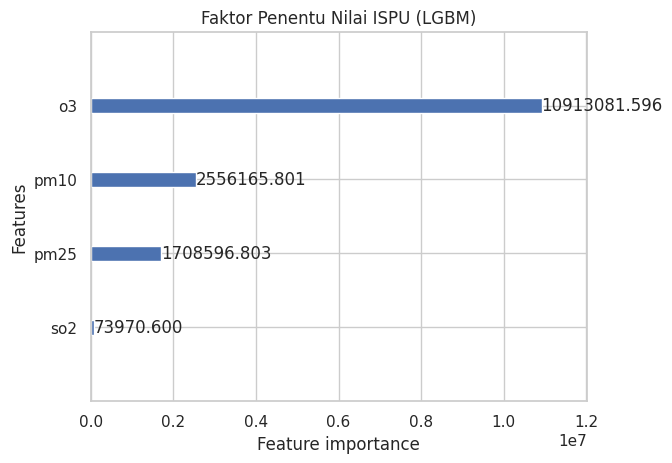

In [72]:
val_predictions_score_lgbm = lgbm_model.predict(X_val)

v_get_category = np.vectorize(get_category)
val_predictions_cat_lgbm = v_get_category(val_predictions_score_lgbm)

y_true = val_data_original['category']
score_lgbm = f1_score(y_true, val_predictions_cat_lgbm, average='macro')

print("="*50)
print(f"F1 Macro Score (Climatology Features + LightGBM): {score_lgbm:.4f}")
print("="*50)

print("\nDetail Performa per Kategori (LGBM):")
print(classification_report(y_true, val_predictions_cat_lgbm))

plt.figure(figsize=(10, 6))
lgb.plot_importance(lgbm_model, max_num_features=10, title='Faktor Penentu Nilai ISPU (LGBM)')
plt.show()

HASIL EVALUASI REGRESI (LightGBM)
MAE  (Rata-rata Meleset)          : 13.1875
RMSE (Sensitif terhadap Error Besar): 17.2989
R2 Score (Kecocokan Pola)         : -0.0213


<Figure size 1000x600 with 0 Axes>

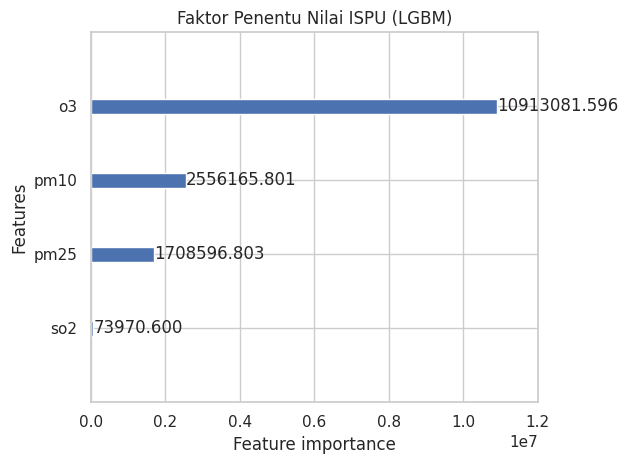

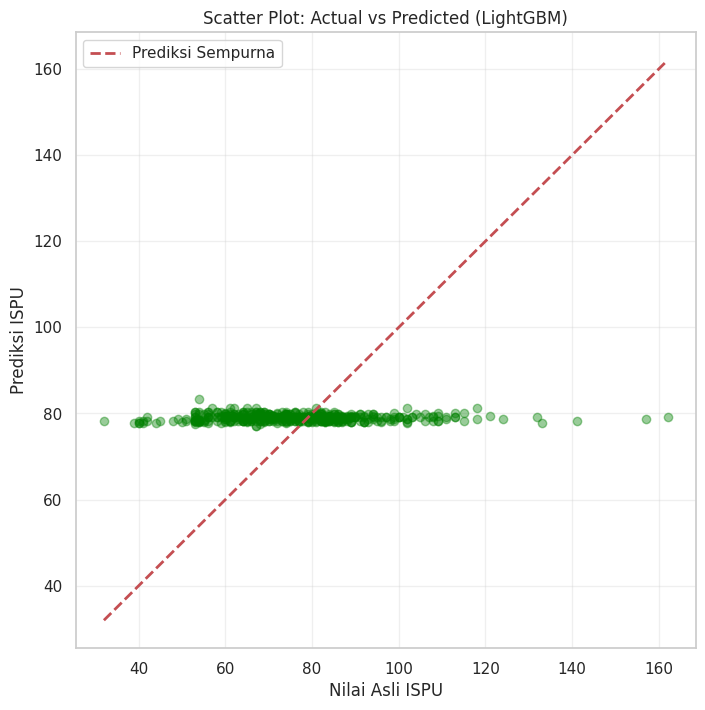

In [73]:
val_predictions_score_lgbm = lgbm_model.predict(X_val)

y_true_numeric = val_data_original['max']

mae_lgbm = mean_absolute_error(y_true_numeric, val_predictions_score_lgbm)
rmse_lgbm = np.sqrt(mean_squared_error(y_true_numeric, val_predictions_score_lgbm))
r2_lgbm = r2_score(y_true_numeric, val_predictions_score_lgbm)

print("="*50)
print(f"HASIL EVALUASI REGRESI (LightGBM)")
print("="*50)
print(f"MAE  (Rata-rata Meleset)          : {mae_lgbm:.4f}")
print(f"RMSE (Sensitif terhadap Error Besar): {rmse_lgbm:.4f}")
print(f"R2 Score (Kecocokan Pola)         : {r2_lgbm:.4f}")
print("="*50)

plt.figure(figsize=(10, 6))
lgb.plot_importance(lgbm_model, max_num_features=10, title='Faktor Penentu Nilai ISPU (LGBM)', importance_type='gain')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(y_true_numeric, val_predictions_score_lgbm, alpha=0.4, color='green')

min_val = min(y_true_numeric.min(), val_predictions_score_lgbm.min())
max_val = max(y_true_numeric.max(), val_predictions_score_lgbm.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Prediksi Sempurna')

plt.title("Scatter Plot: Actual vs Predicted (LightGBM)")
plt.xlabel("Nilai Asli ISPU")
plt.ylabel("Prediksi ISPU")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **2. Metode "Recursive Forecasting" (Walk-Forward)**

In [74]:
df = df_ispu_full.copy()
df['tanggal'] = pd.to_datetime(df['tanggal'])

# 1. Validasi tahun 2024
val_start_date = pd.to_datetime('2024-09-01')
val_end_date = pd.to_datetime('2024-11-30')

train_df = df[df['tanggal'] < val_start_date].copy()

val_df_truth = df[(df['tanggal'] >= val_start_date) & 
                  (df['tanggal'] <= val_end_date)].copy()

train_df['month'] = train_df['tanggal'].dt.month
train_df['day'] = train_df['tanggal'].dt.day

anchor_lookup = train_df.groupby(['lokasi_spku', 'month', 'day'])['max'].median().reset_index()
anchor_lookup.rename(columns={'max': 'anchor_clim_median'}, inplace=True)

fallback_anchor = train_df.groupby('lokasi_spku')['max'].median()

print(f"Data Train: {len(train_df)} baris")
print(f"Data Validasi (Target): {len(val_df_truth)} baris")
print("Contoh Anchor Lookup:")
display(anchor_lookup.head())

Data Train: 13582 baris
Data Validasi (Target): 453 baris
Contoh Anchor Lookup:


,lokasi_spku,month,day,anchor_clim_median
0,DKI1,1,1,61.0
1,DKI1,1,2,49.5
2,DKI1,1,3,49.0
3,DKI1,1,4,54.5
4,DKI1,1,5,50.0


In [75]:
def prepare_training_features(df, anchor_df):
    df = df.copy()
    df = df.dropna(subset=['lokasi_spku']).copy()
    
    df = df.sort_values(['lokasi_spku', 'tanggal'])
    df = df.merge(anchor_df, on=['lokasi_spku', 'month', 'day'], how='left')
    
    fallback_map = df.groupby('lokasi_spku')['max'].median()
    fallback_values = df['lokasi_spku'].map(fallback_map)
    
    df['anchor_clim_median'] = df['anchor_clim_median'].fillna(fallback_values)
    
    global_median = df['max'].median()
    df['anchor_clim_median'] = df['anchor_clim_median'].fillna(global_median)
    
    for lag in [1, 2, 3]:
        df[f'lag_{lag}'] = df.groupby('lokasi_spku')['max'].shift(lag)
        
    df['rolling_mean_7d'] = df.groupby('lokasi_spku')['max'].transform(lambda x: x.rolling(window=7).mean())
    df['rolling_max_7d'] = df.groupby('lokasi_spku')['max'].transform(lambda x: x.rolling(window=7).max())
    df['day_of_week'] = df['tanggal'].dt.dayofweek
    df = df.dropna(subset=['lag_3', 'rolling_mean_7d', 'max'])
    
    return df

train_df_ready = prepare_training_features(train_df, anchor_lookup)

print("Fitur Training Siap.")
print(f"Dimensi Data Training: {train_df_ready.shape}")
display(train_df_ready[['tanggal', 'lokasi_spku', 'max', 'lag_1', 'anchor_clim_median']].tail())

Fitur Training Siap.
Dimensi Data Training: (13550, 20)


,tanggal,lokasi_spku,max,lag_1,anchor_clim_median
13575,2024-08-27,DKI5,116.0,102.0,85.0
13576,2024-08-28,DKI5,87.0,116.0,77.0
13577,2024-08-29,DKI5,107.0,87.0,95.5
13578,2024-08-30,DKI5,127.0,107.0,79.0
13579,2024-08-31,DKI5,80.0,127.0,79.5


In [76]:
from sklearn.ensemble import RandomForestRegressor

features = [
    'lag_1', 'lag_2', 'lag_3', 
    'rolling_mean_7d', 'rolling_max_7d', 
    'anchor_clim_median',
    'month', 'day_of_week'
]
target = 'max'

rf_stabilized = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)

print("Sedang melatih model Random Forest (Stabilized)...")
rf_stabilized.fit(train_df_ready[features], train_df_ready[target])

print("Selesai.")
print("Feature Importances:")
for name, score in zip(features, rf_stabilized.feature_importances_):
    print(f"- {name}: {score:.4f}")

Sedang melatih model Random Forest (Stabilized)...
Selesai.
Feature Importances:
- lag_1: 0.0494
- lag_2: 0.0401
- lag_3: 0.0485
- rolling_mean_7d: 0.7115
- rolling_max_7d: 0.0669
- anchor_clim_median: 0.0465
- month: 0.0211
- day_of_week: 0.0161


In [77]:
pred_dates = pd.date_range(start=val_start_date, end=val_end_date)
locations = df['lokasi_spku'].unique() 
predictions = []

global_max_median = train_df['max'].median()

print("Memulai Stabilized Recursive Forecasting (Safe Mode)...")

for loc in locations:
    history_buffer = train_df_ready[
        (train_df_ready['lokasi_spku'] == loc)
    ].tail(30).copy()
    
    if len(history_buffer) < 3:
        missing_rows = 3 - len(history_buffer)
        
        if len(history_buffer) > 0:
            local_median = history_buffer['max'].median()
        else:
            local_median = global_max_median
            
        dummy_data = []
        for _ in range(missing_rows):
            dummy_data.append({
                'lokasi_spku': loc,
                'max': local_median,
                'tanggal': pd.Timestamp('2000-01-01'), 
                'month': 1, 'day': 1, 'lag_1': local_median, 
                'rolling_mean_7d': local_median
            })
            
        dummy_df = pd.DataFrame(dummy_data)
        history_buffer = pd.concat([dummy_df, history_buffer], ignore_index=True)
    
    loc_anchors = anchor_lookup[anchor_lookup['lokasi_spku'] == loc].set_index(['month', 'day'])
    
    for date in pred_dates:
        
        lag_1 = history_buffer.iloc[-1]['max']
        lag_2 = history_buffer.iloc[-2]['max']
        lag_3 = history_buffer.iloc[-3]['max']
        
        roll_window = history_buffer.tail(7)['max']
        roll_mean = roll_window.mean()
        roll_max = roll_window.max()
        
        try:
            anchor_val = loc_anchors.loc[(date.month, date.day), 'anchor_clim_median']
            if isinstance(anchor_val, pd.Series):
                anchor_val = anchor_val.iloc[0]
        except KeyError:
            anchor_val = global_max_median 
            
        input_row = pd.DataFrame({
            'lag_1': [lag_1],
            'lag_2': [lag_2],
            'lag_3': [lag_3],
            'rolling_mean_7d': [roll_mean],
            'rolling_max_7d': [roll_max],
            'anchor_clim_median': [anchor_val],
            'month': [date.month],
            'day_of_week': [date.dayofweek]
        })
        
        pred_val = rf_stabilized.predict(input_row)[0]
        
        new_row = pd.DataFrame({
            'tanggal': [date],
            'lokasi_spku': [loc],
            'max': [pred_val],
            'month': [date.month],
            'day': [date.day]
        })
        
        history_buffer = pd.concat([history_buffer, new_row], ignore_index=True).tail(30)
        
        predictions.append({
            'tanggal': date,
            'lokasi_spku': loc,
            'pred_max': pred_val
        })

val_predictions_df = pd.DataFrame(predictions)
print(f"Prediksi Selesai. Total prediksi: {len(val_predictions_df)}")
display(val_predictions_df.head())

Memulai Stabilized Recursive Forecasting (Safe Mode)...
Prediksi Selesai. Total prediksi: 546


,tanggal,lokasi_spku,pred_max
0,2024-09-01,DKI1,89.930
1,2024-09-02,DKI1,90.030
2,2024-09-03,DKI1,95.975
3,2024-09-04,DKI1,89.860
4,2024-09-05,DKI1,88.320


STABILIZED RECURSIVE F1 SCORE: 0.2957

Detail Report:
              precision    recall  f1-score   support

        BAIK       0.00      0.00      0.00        14
      SEDANG       0.87      0.78      0.82       403
 TIDAK SEHAT       0.04      0.11      0.06        36

    accuracy                           0.70       453
   macro avg       0.31      0.30      0.30       453
weighted avg       0.78      0.70      0.74       453



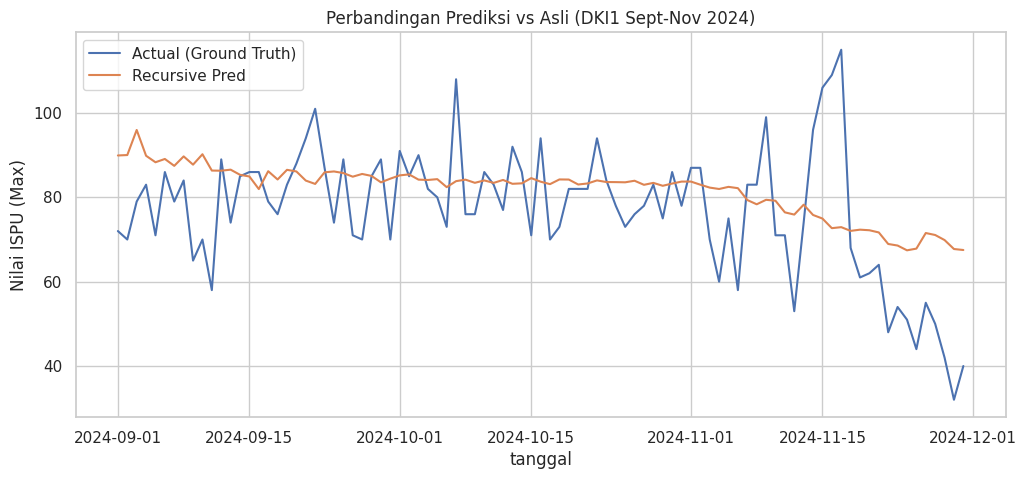

In [78]:
eval_df = val_df_truth[['tanggal', 'lokasi_spku', 'category', 'max']].merge(
    val_predictions_df,
    on=['tanggal', 'lokasi_spku'],
    how='inner'
)

def get_category(score):
    if score <= 50: return "BAIK"
    elif score <= 100: return "SEDANG"
    else: return "TIDAK SEHAT"

eval_df['category_pred'] = eval_df['pred_max'].apply(get_category)
score = f1_score(eval_df['category'], eval_df['category_pred'], average='macro')

print("="*50)
print(f"STABILIZED RECURSIVE F1 SCORE: {score:.4f}")
print("="*50)
print("\nDetail Report:")
print(classification_report(eval_df['category'], eval_df['category_pred']))

plt.figure(figsize=(12, 5))
sns.lineplot(data=eval_df[eval_df['lokasi_spku']=='DKI1'], x='tanggal', y='max', label='Actual (Ground Truth)')
sns.lineplot(data=eval_df[eval_df['lokasi_spku']=='DKI1'], x='tanggal', y='pred_max', label='Recursive Pred')

plt.title("Perbandingan Prediksi vs Asli (DKI1 Sept-Nov 2024)")
plt.ylabel("Nilai ISPU (Max)")
plt.show()

EVALUASI MODEL (REGRESI)
MAE  (Mean Absolute Error)    : 20.0848
RMSE (Root Mean Squared Error): 28.1101


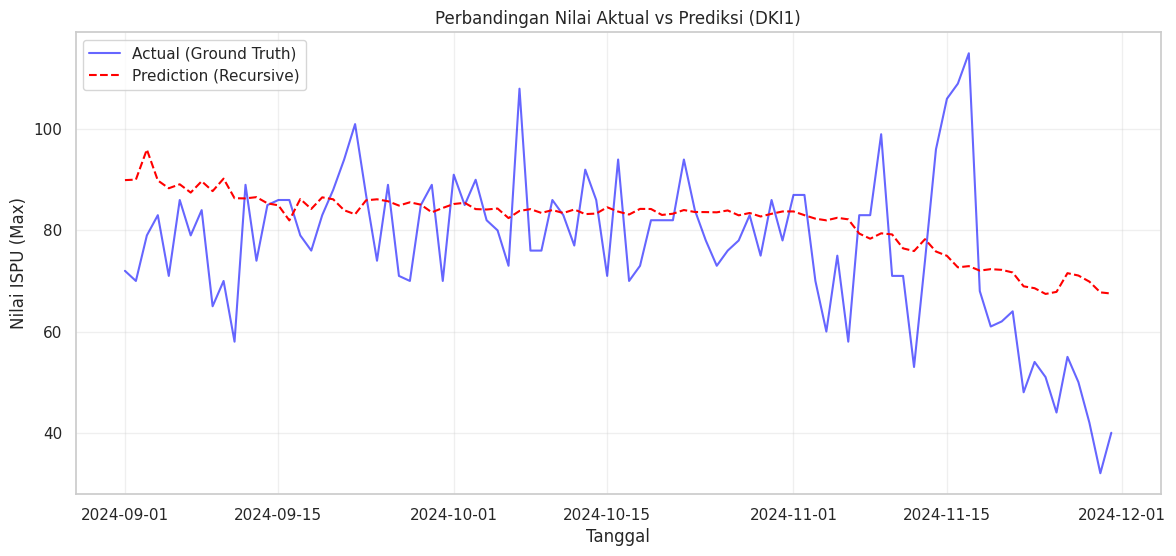

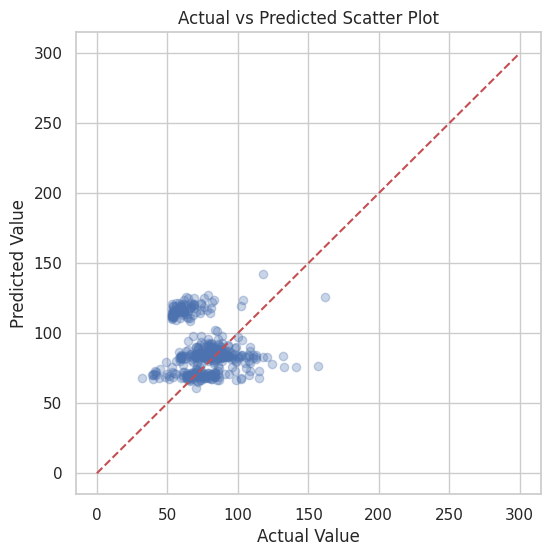

In [79]:
# 1. Gabungkan Ground Truth dengan Prediksi
# Kita hanya butuh kolom 'max' (aktual) dan 'pred_max' (prediksi)
eval_df = val_df_truth[['tanggal', 'lokasi_spku', 'max']].merge(
    val_predictions_df, 
    on=['tanggal', 'lokasi_spku'], 
    how='inner'
)

# 2. Hitung MAE dan RMSE
mae_score = mean_absolute_error(eval_df['max'], eval_df['pred_max'])
rmse_score = np.sqrt(mean_squared_error(eval_df['max'], eval_df['pred_max']))

print("="*50)
print(f"EVALUASI MODEL (REGRESI)")
print("="*50)
print(f"MAE  (Mean Absolute Error)    : {mae_score:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse_score:.4f}")
print("="*50)

# 3. Visualisasi Perbandingan Nilai (Time Series)
plt.figure(figsize=(14, 6))

# Contoh mengambil satu lokasi untuk visualisasi (misal: DKI1)
loc_sample = 'DKI1'
subset_eval = eval_df[eval_df['lokasi_spku'] == loc_sample]

sns.lineplot(data=subset_eval, x='tanggal', y='max', label='Actual (Ground Truth)', color='blue', alpha=0.6)
sns.lineplot(data=subset_eval, x='tanggal', y='pred_max', label='Prediction (Recursive)', color='red', linestyle='--')

plt.title(f"Perbandingan Nilai Aktual vs Prediksi ({loc_sample})")
plt.ylabel("Nilai ISPU (Max)")
plt.xlabel("Tanggal")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 4. Scatter Plot (Optional: Melihat sebaran error)
plt.figure(figsize=(6, 6))
plt.scatter(eval_df['max'], eval_df['pred_max'], alpha=0.3)
plt.plot([0, 300], [0, 300], 'r--') # Garis diagonal sempurna
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Actual vs Predicted Scatter Plot")
plt.grid(True)
plt.show()

In [80]:
df = df_ispu_full.copy()
df['tanggal'] = pd.to_datetime(df['tanggal'])

# 1. Tentukan Periode Validasi (Sept - Nov 2024)
val_start_date = pd.to_datetime('2024-09-01')
val_end_date = pd.to_datetime('2024-11-30')

# 2. Split Data
train_df = df[df['tanggal'] < val_start_date].copy()
val_df_truth = df[(df['tanggal'] >= val_start_date) & 
                  (df['tanggal'] <= val_end_date)].copy()

# 3. Buat "Jangkar" (Anchor) dari Training Data
# Median historis per Lokasi-Bulan-Hari
train_df['month'] = train_df['tanggal'].dt.month
train_df['day'] = train_df['tanggal'].dt.day

anchor_lookup = train_df.groupby(['lokasi_spku', 'month', 'day'])['max'].median().reset_index()
anchor_lookup.rename(columns={'max': 'anchor_clim_median'}, inplace=True)

print(f"Data Train: {len(train_df)} baris")
print(f"Data Validasi (Target): {len(val_df_truth)} baris")

Data Train: 13582 baris
Data Validasi (Target): 453 baris


In [81]:
def prepare_training_features(df, anchor_df):
    df = df.copy()
    
    df = df.dropna(subset=['lokasi_spku', 'max']).copy()
    df = df.sort_values(['lokasi_spku', 'tanggal'])
    df = df.merge(anchor_df, on=['lokasi_spku', 'month', 'day'], how='left')
    
    fallback_map = df.groupby('lokasi_spku')['max'].median()
    fallback_values = df['lokasi_spku'].map(fallback_map)
    df['anchor_clim_median'] = df['anchor_clim_median'].fillna(fallback_values)
    
    df['anchor_clim_median'] = df['anchor_clim_median'].fillna(df['max'].median())
    
    for lag in [1, 2, 3]:
        df[f'lag_{lag}'] = df.groupby('lokasi_spku')['max'].shift(lag)
        
    df['rolling_mean_7d'] = df.groupby('lokasi_spku')['max'].transform(lambda x: x.rolling(window=7).mean())
    df['rolling_max_7d'] = df.groupby('lokasi_spku')['max'].transform(lambda x: x.rolling(window=7).max())
    df['day_of_week'] = df['tanggal'].dt.dayofweek
    
    df = df.dropna(subset=['lag_3', 'rolling_mean_7d'])
    
    return df

train_df_ready = prepare_training_features(train_df, anchor_lookup)

print("Fitur Training Siap.")
display(train_df_ready[['tanggal', 'lokasi_spku', 'max', 'lag_1', 'anchor_clim_median']].tail())

Fitur Training Siap.


,tanggal,lokasi_spku,max,lag_1,anchor_clim_median
13575,2024-08-27,DKI5,116.0,102.0,85.0
13576,2024-08-28,DKI5,87.0,116.0,77.0
13577,2024-08-29,DKI5,107.0,87.0,95.5
13578,2024-08-30,DKI5,127.0,107.0,79.0
13579,2024-08-31,DKI5,80.0,127.0,79.5


Sedang melatih LightGBM (Stabilized)...
Selesai.
Feature Importances:


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

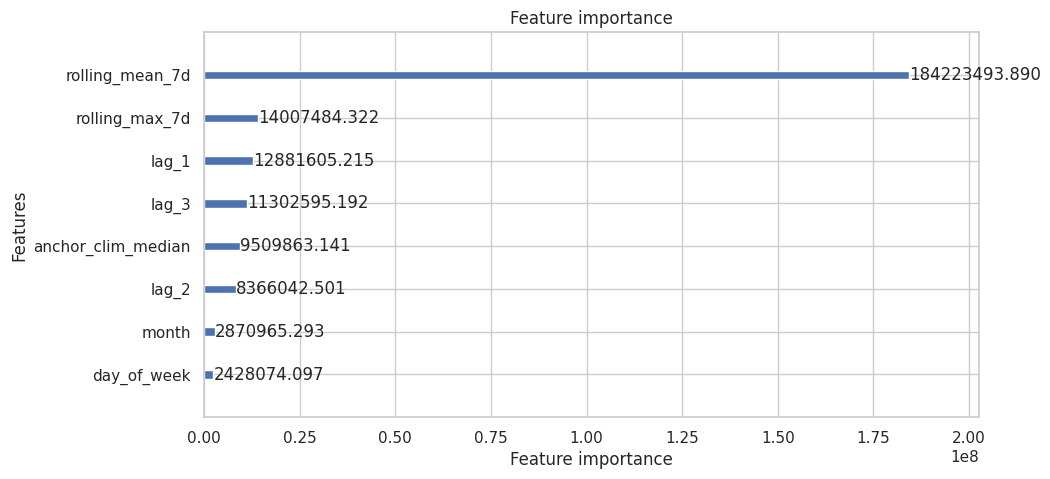

In [82]:
features = [
    'lag_1', 'lag_2', 'lag_3', 
    'rolling_mean_7d', 'rolling_max_7d', 
    'anchor_clim_median', 
    'month', 'day_of_week'
]
target = 'max'

lgbm_stabilized = LGBMRegressor(
    objective='regression',
    n_estimators=2000,      
    learning_rate=0.03,     
    num_leaves=31,
    reg_alpha=0.1,          
    reg_lambda=0.1,         
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

print("Sedang melatih LightGBM (Stabilized)...")
lgbm_stabilized.fit(train_df_ready[features], train_df_ready[target])

print("Selesai.")
print("Feature Importances:")
lgb.plot_importance(lgbm_stabilized, max_num_features=10, importance_type='gain', figsize=(10,5))

In [83]:
pred_dates = pd.date_range(start=val_start_date, end=val_end_date)
locations = df['lokasi_spku'].unique()
predictions = []

global_max_median = train_df_ready['max'].median()

print("Memulai Stabilized Recursive Forecasting dengan LGBM...")

for loc in locations:
    history_buffer = train_df_ready[
        (train_df_ready['lokasi_spku'] == loc)
    ].tail(30).copy()
    
    if len(history_buffer) < 3:
        dummy_df = pd.DataFrame([{
            'lokasi_spku': loc, 'max': global_max_median,
            'tanggal': pd.Timestamp('2000-01-01'), 'month': 1, 'day': 1
        }] * 3)
        history_buffer = pd.concat([dummy_df, history_buffer], ignore_index=True)

    loc_anchors = anchor_lookup[anchor_lookup['lokasi_spku'] == loc].set_index(['month', 'day'])
    
    for date in pred_dates:
        lag_1 = history_buffer.iloc[-1]['max']
        lag_2 = history_buffer.iloc[-2]['max']
        lag_3 = history_buffer.iloc[-3]['max']
        
        roll_window = history_buffer.tail(7)['max']
        roll_mean = roll_window.mean()
        roll_max = roll_window.max()
        
        try:
            anchor_val = loc_anchors.loc[(date.month, date.day), 'anchor_clim_median']
            if isinstance(anchor_val, pd.Series): anchor_val = anchor_val.iloc[0]
        except KeyError:
            anchor_val = global_max_median
            
        input_row = pd.DataFrame({
            'lag_1': [lag_1], 'lag_2': [lag_2], 'lag_3': [lag_3],
            'rolling_mean_7d': [roll_mean], 'rolling_max_7d': [roll_max],
            'anchor_clim_median': [anchor_val],
            'month': [date.month], 'day_of_week': [date.dayofweek]
        })
        
        pred_val = lgbm_stabilized.predict(input_row)[0]
        
        new_row = pd.DataFrame({
            'tanggal': [date], 'lokasi_spku': [loc], 'max': [pred_val],
            'month': [date.month], 'day': [date.day]
        })
        history_buffer = pd.concat([history_buffer, new_row], ignore_index=True).tail(30)
        
        predictions.append({
            'tanggal': date, 'lokasi_spku': loc, 'pred_max': pred_val
        })

val_predictions_lgbm = pd.DataFrame(predictions)
print(f"Prediksi LGBM Selesai. Total baris: {len(val_predictions_lgbm)}")

Memulai Stabilized Recursive Forecasting dengan LGBM...
Prediksi LGBM Selesai. Total baris: 546


LGBM RECURSIVE F1 SCORE: 0.4243

Detail Report:
              precision    recall  f1-score   support

        BAIK       0.45      0.36      0.40        14
      SEDANG       0.88      0.75      0.81       403
 TIDAK SEHAT       0.04      0.11      0.06        36

    accuracy                           0.69       453
   macro avg       0.46      0.41      0.42       453
weighted avg       0.80      0.69      0.74       453



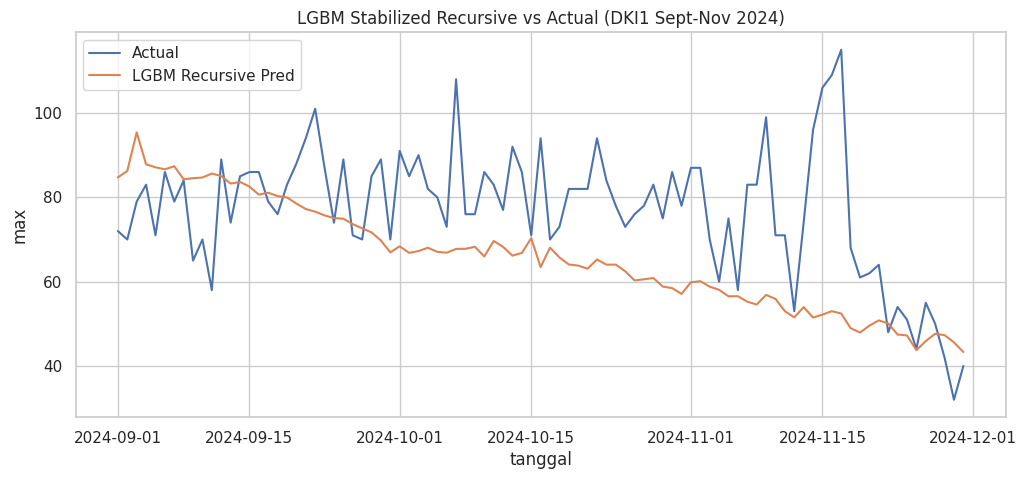

In [84]:
eval_df = val_df_truth[['tanggal', 'lokasi_spku', 'category', 'max']].merge(
    val_predictions_lgbm,
    on=['tanggal', 'lokasi_spku'],
    how='inner'
)

def get_category(score):
    if score <= 50: return "BAIK"
    elif score <= 100: return "SEDANG"
    else: return "TIDAK SEHAT"

eval_df['category_pred'] = eval_df['pred_max'].apply(get_category)

score = f1_score(eval_df['category'], eval_df['category_pred'], average='macro')

print("="*50)
print(f"LGBM RECURSIVE F1 SCORE: {score:.4f}")
print("="*50)

print("\nDetail Report:")
print(classification_report(eval_df['category'], eval_df['category_pred']))

# Visualisasi
plt.figure(figsize=(12, 5))
sns.lineplot(data=eval_df[eval_df['lokasi_spku']=='DKI1'], x='tanggal', y='max', label='Actual')
sns.lineplot(data=eval_df[eval_df['lokasi_spku']=='DKI1'], x='tanggal', y='pred_max', label='LGBM Recursive Pred')
plt.title("LGBM Stabilized Recursive vs Actual (DKI1 Sept-Nov 2024)")
plt.show()

EVALUASI MODEL LGBM RECURSIVE (REGRESI)
MAE  (Rata-rata Kesalahan Mutlak) : 21.4091
RMSE (Akar Kuadrat Galat)         : 29.1007


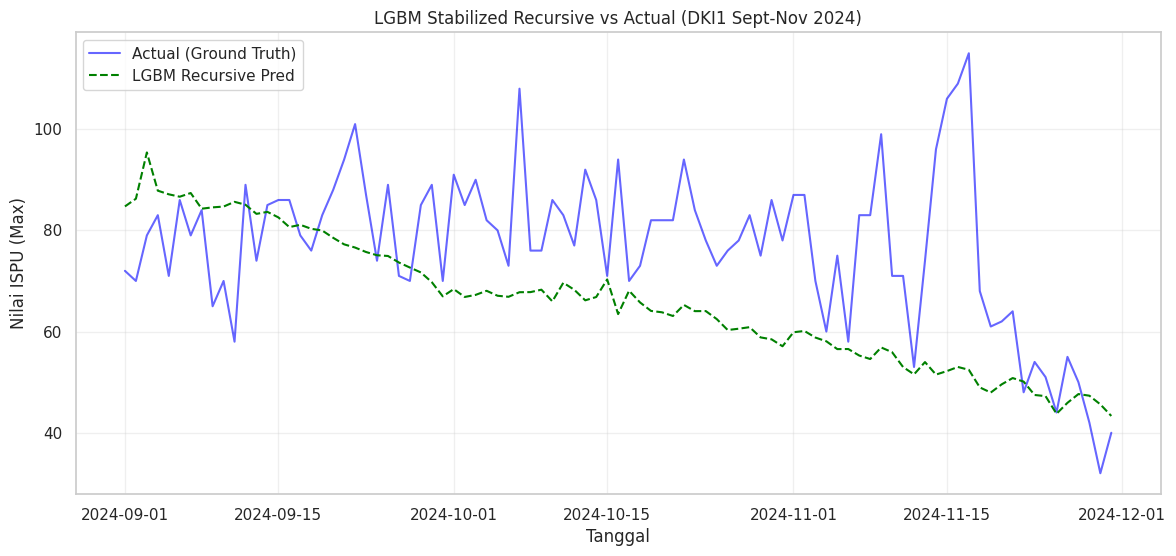

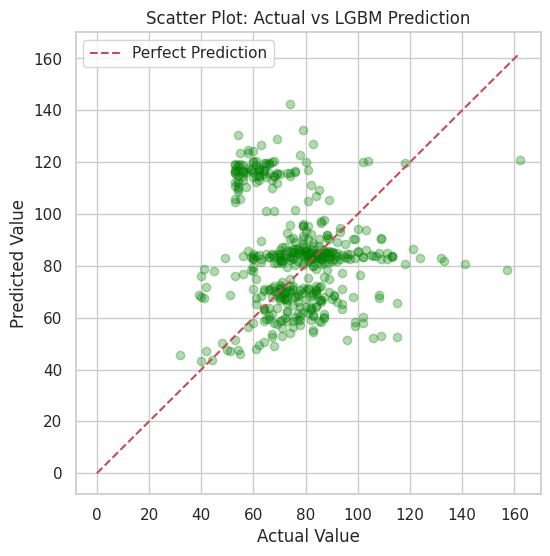

In [85]:
eval_df = val_df_truth[['tanggal', 'lokasi_spku', 'max']].merge(
    val_predictions_lgbm, 
    on=['tanggal', 'lokasi_spku'], 
    how='inner'
)

mae_score = mean_absolute_error(eval_df['max'], eval_df['pred_max'])
rmse_score = np.sqrt(mean_squared_error(eval_df['max'], eval_df['pred_max']))

print("="*50)
print(f"EVALUASI MODEL LGBM RECURSIVE (REGRESI)")
print("="*50)
print(f"MAE  (Rata-rata Kesalahan Mutlak) : {mae_score:.4f}")
print(f"RMSE (Akar Kuadrat Galat)         : {rmse_score:.4f}")
print("="*50)

plt.figure(figsize=(14, 6))

target_loc = 'DKI1'
subset_df = eval_df[eval_df['lokasi_spku'] == target_loc]

# Plot Garis
sns.lineplot(data=subset_df, x='tanggal', y='max', label='Actual (Ground Truth)', color='blue', alpha=0.6)
sns.lineplot(data=subset_df, x='tanggal', y='pred_max', label='LGBM Recursive Pred', color='green', linestyle='--')

plt.title(f"LGBM Stabilized Recursive vs Actual ({target_loc} Sept-Nov 2024)")
plt.ylabel("Nilai ISPU (Max)")
plt.xlabel("Tanggal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# (Optional) Scatter Plot untuk melihat sebaran error
plt.figure(figsize=(6, 6))
plt.scatter(eval_df['max'], eval_df['pred_max'], alpha=0.3, color='green')
# Garis diagonal sempurna (jika titik ada di garis ini, berarti prediksi 100% tepat)
max_val = max(eval_df['max'].max(), eval_df['pred_max'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect Prediction')

plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Scatter Plot: Actual vs LGBM Prediction")
plt.grid(True)
plt.legend()
plt.show()

## 3. Metode penggabungan dengan data cuaca dan ndvi

In [86]:
df_ispu_full['tanggal'] = pd.to_datetime(df_ispu_full['tanggal'])

for df in [final_dki1, final_dki2, final_dki3, final_dki4, final_dki5]:
    df['time'] = pd.to_datetime(df['time'])

station_mapping = {
    'dki1': 'DKI1',  
    'dki2': 'DKI2', 
    'dki3': 'DKI3',    
    'dki4': 'DKI4', 
    'dki5': 'DKI5'    
}

def merge_data(df_weather, df_ispu, station_name_ispu):
    ispu_subset = df_ispu[df_ispu['lokasi_spku'] == station_name_ispu].copy()
    
    merged_df = pd.merge(
        df_weather,
        ispu_subset,
        left_on='time',     # Key di data cuaca
        right_on='tanggal', # Key di data ISPU
        how='inner'         
    )
    
    if 'tanggal' in merged_df.columns:
        merged_df = merged_df.drop(columns=['tanggal'])
        
    return merged_df

try:
    dataset_dki1 = merge_data(final_dki1, df_ispu_full, station_mapping['dki1'])
    dataset_dki2 = merge_data(final_dki2, df_ispu_full, station_mapping['dki2'])
    dataset_dki3 = merge_data(final_dki3, df_ispu_full, station_mapping['dki3'])
    dataset_dki4 = merge_data(final_dki4, df_ispu_full, station_mapping['dki4'])
    dataset_dki5 = merge_data(final_dki5, df_ispu_full, station_mapping['dki5'])

    print("Penggabungan Berhasil!")
    print(f"Dimensi Dataset DKI1: {dataset_dki1.shape}")
    print(f"Contoh kolom hasil: {dataset_dki1.columns[:5]}") # Cek 5 kolom pertama

except Exception as e:
    print("Terjadi kesalahan. Cek kembali nama lokasi di station_mapping.")
    print(e)

Penggabungan Berhasil!
Dimensi Dataset DKI1: (2865, 405)
Contoh kolom hasil: Index(['time', 'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'precipitation_sum (mm)', 'precipitation_hours (h)'],
      dtype='object')


In [87]:
dataset_dki1['lokasi_spku'] = 'DKI1'
dataset_dki2['lokasi_spku'] = 'DKI2'
dataset_dki3['lokasi_spku'] = 'DKI3'
dataset_dki4['lokasi_spku'] = 'DKI4'
dataset_dki5['lokasi_spku'] = 'DKI5'

df_combined = pd.concat([
    dataset_dki1, dataset_dki2, dataset_dki3, dataset_dki4, dataset_dki5
], ignore_index=True)

df_combined['time'] = pd.to_datetime(df_combined['time'])
df_combined = df_combined.sort_values(['lokasi_spku', 'time']).reset_index(drop=True)

target_col = 'max'
lags = [1, 2, 3]

for lag in lags:
    df_combined[f'target_lag_{lag}'] = df_combined.groupby('lokasi_spku')[target_col].shift(lag)

df_combined = df_combined.dropna(subset=[f'target_lag_{max(lags)}'])

print("Total Data Combined:", len(df_combined))

Total Data Combined: 15376


In [88]:
df_ndvi_daily = df_ndvi_daily.rename(columns={'tanggal': 'time'})
df_ndvi_daily['time'] = pd.to_datetime(df_ndvi_daily['time'])

df_combined = pd.merge(
    df_combined, 
    df_ndvi_daily[['time', 'lokasi_spku', 'ndvi']], 
    on=['time', 'lokasi_spku'], 
    how='left'
)

df_combined['ndvi'] = df_combined.groupby('lokasi_spku')['ndvi'].ffill().bfill()

print("Total Baris:", len(df_combined))

Total Baris: 15376


In [89]:
ndvi_lags = [1, 2, 3]

for lag in ndvi_lags:
    column_name = f'ndvi_lag_{lag}'
    df_combined[column_name] = df_combined.groupby('lokasi_spku')['ndvi'].shift(lag)

max_lag = max(lags + ndvi_lags)
df_combined = df_combined.dropna(subset=[f'target_lag_{max_lag}', f'ndvi_lag_{max_lag}'])

### Visualisasi singkat kemiripan pola data 2025 dengan versi 340 hari yang lalu

--- VISUALISASI REAL VS PREDIKSI (BACKTEST 2025) ---
Target (Ground Truth) : 2025-01-01 s/d 2025-08-31 (Data 2025)
Sumber (Prediksi)     : Data 2024 (Mundur 340 Hari)


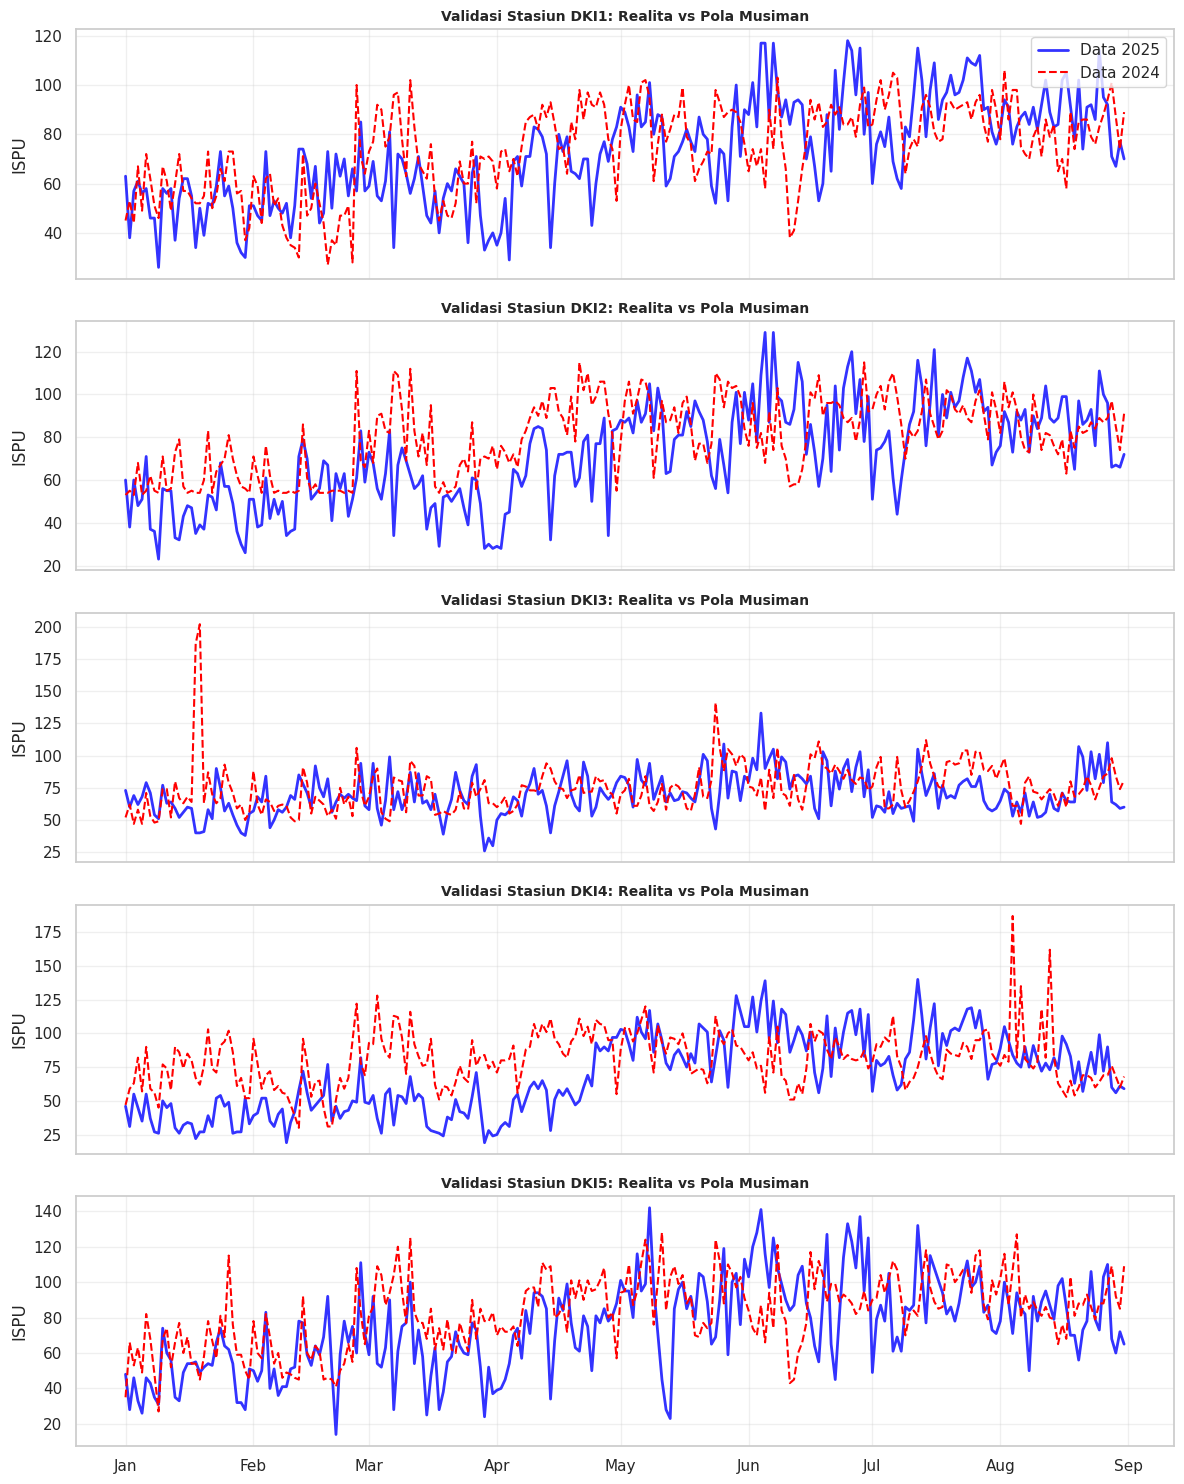

In [90]:
import matplotlib.dates as mdates

target_start = pd.to_datetime('2025-01-01')
target_end = pd.to_datetime('2025-08-31') 

days_lag = 340 

print(f"--- VISUALISASI REAL VS PREDIKSI (BACKTEST 2025) ---")
print(f"Target (Ground Truth) : {target_start.date()} s/d {target_end.date()} (Data 2025)")
print(f"Sumber (Prediksi)     : Data 2024 (Mundur 340 Hari)")

# Loop Stasiun
stations = ['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5']

fig, axes = plt.subplots(len(stations), 1, figsize=(12, 15), sharex=True)

for i, st in enumerate(stations):
    ax = axes[i]
    
    mask_target = (df_combined['lokasi_spku'] == st) & \
                  (df_combined['time'] >= target_start) & \
                  (df_combined['time'] <= target_end)
    df_target = df_combined[mask_target].sort_values('time')
    
    source_start = target_start - pd.Timedelta(days=days_lag)
    source_end = target_end - pd.Timedelta(days=days_lag)
    
    mask_source = (df_combined['lokasi_spku'] == st) & \
                  (df_combined['time'] >= source_start) & \
                  (df_combined['time'] <= source_end)
    df_source = df_combined[mask_source].sort_values('time').copy()
    
    if not df_source.empty:
        df_source['time_shifted'] = df_source['time'] + pd.Timedelta(days=days_lag)
    
    ax.plot(df_target['time'], df_target['max'], color='blue', label='Data 2025', linewidth=2, alpha=0.8)
    
    if not df_source.empty:
        ax.plot(df_source['time_shifted'], df_source['max'], color='red', linestyle='--', label='Data 2024', linewidth=1.5)
    
    ax.set_title(f'Validasi Stasiun {st}: Realita vs Pola Musiman', fontsize=10, fontweight='bold')
    ax.set_ylabel('ISPU')
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(loc='upper right')

# Format Sumbu X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

In [91]:
val_start_date = pd.to_datetime('2024-09-01')
val_end_date = pd.to_datetime('2024-11-30')

train_df = df_combined[df_combined['time'] < val_start_date].copy()
val_df_truth = df_combined[(df_combined['time'] >= val_start_date) & 
                           (df_combined['time'] <= val_end_date)].copy()

train_df['month'] = train_df['time'].dt.month
train_df['day'] = train_df['time'].dt.day

# Hitung median
anchor_lookup = train_df.groupby(['lokasi_spku', 'month', 'day'])['max'].median().reset_index()
anchor_lookup.rename(columns={'max': 'anchor_clim_median'}, inplace=True)

train_df = pd.merge(train_df, anchor_lookup, on=['lokasi_spku', 'month', 'day'], how='left')
val_df_truth = pd.merge(val_df_truth, anchor_lookup, on=['lokasi_spku', 'month', 'day'], how='left')

val_df_truth['anchor_clim_median'] = val_df_truth['anchor_clim_median'].fillna(train_df['max'].median())

print(f"Data Train: {len(train_df)} baris")
print(f"Data Validasi (Target): {len(val_df_truth)} baris")

Data Train: 13550 baris
Data Validasi (Target): 453 baris


In [92]:
ignore_cols = ['time', 'lokasi_spku', 'tanggal', 'date_key', 'max', 'category', 'critical', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2']

features = [col for col in train_df.columns if col not in ignore_cols]
target = 'max'

X_train = train_df[features]
y_train = train_df[target]

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'random_state': 42,
    'verbose': -1
}

model = lgb.LGBMRegressor(**params)

print("Sedang melatih model...")
model.fit(X_train, y_train)
print("Training selesai.")

feature_imp = pd.DataFrame({'Value': model.feature_importances_, 'Feature': features})
print(feature_imp.sort_values(by="Value", ascending=False).head(10))

Sedang melatih model...
Training selesai.
     Value                          Feature
394    938                     target_lag_1
395    669                     target_lag_2
396    634                     target_lag_3
401    476               anchor_clim_median
23     436                             year
361    173        wind_gusts_10m (km/h)_std
397    171                             ndvi
311    168   apparent_temperature (?øC)_std
393    158             wind_speed_10m_y_std
298    156  wind_speed_10m_max_y_diff_lag_1


In [93]:
def recursive_forecast(model, val_df, features, target_col='max', lags=[1, 2, 3]):
    """
    Melakukan forecasting harian secara rekursif per lokasi.
    """
    val_df = val_df.copy()
    
    val_df = val_df.sort_values('time')
    predictions = []
    
    unique_dates = val_df['time'].unique()
    unique_locations = val_df['lokasi_spku'].unique()
    
    print(f"Memulai Recursive Forecasting untuk {len(unique_dates)} hari...")

    for current_date in unique_dates:
        current_day_mask = val_df['time'] == current_date
        X_current = val_df.loc[current_day_mask, features]
        if len(X_current) == 0: continue
        preds_current = model.predict(X_current)
        val_df.loc[current_day_mask, 'pred_max'] = preds_current
        for loc_idx, loc_name in enumerate(val_df.loc[current_day_mask, 'lokasi_spku']):
            pred_value = preds_current[loc_idx]
            future_mask = (val_df['lokasi_spku'] == loc_name) & (val_df['time'] > current_date)
            future_indices = val_df.loc[future_mask].index
            for lag in lags:
                target_date_for_lag = current_date + pd.Timedelta(days=lag)
                target_idx = val_df.loc[
                    (val_df['time'] == target_date_for_lag) & 
                    (val_df['lokasi_spku'] == loc_name)
                ].index
                if len(target_idx) > 0:
                    val_df.loc[target_idx, f'target_lag_{lag}'] = pred_value

    return val_df

val_df_result = recursive_forecast(model, val_df_truth, features, lags=[1, 2, 3])

y_true = val_df_result['max']
y_pred = val_df_result['pred_max']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print(f"\nHasil Evaluasi Recursive:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

# Tampilkan beberapa hasil
print(val_df_result[['time', 'lokasi_spku', 'max', 'pred_max', 'target_lag_1']].head(10))

Memulai Recursive Forecasting untuk 91 hari...

Hasil Evaluasi Recursive:
MAE: 17.75
RMSE: 22.23
          time lokasi_spku   max    pred_max  target_lag_1
0   2024-09-01        DKI1  72.0   82.859097     75.000000
91  2024-09-01        DKI2  74.0   97.225075     80.000000
362 2024-09-01        DKI5  93.0   91.421632     80.000000
182 2024-09-01        DKI3  79.0   64.119634     47.000000
272 2024-09-01        DKI4  81.0  127.495248    135.000000
1   2024-09-02        DKI1  70.0   80.062396     82.859097
92  2024-09-02        DKI2  73.0   93.513292     97.225075
363 2024-09-02        DKI5  85.0  100.496571     91.421632
183 2024-09-02        DKI3  84.0   73.413185     64.119634
2   2024-09-03        DKI1  79.0   77.369659     80.062396


HASIL EVALUASI KLASIFIKASI (Recursive Forecasting)
F1 Score (Macro) : 0.4280
Accuracy         : 0.7726

Detail Laporan per Kategori:
              precision    recall  f1-score   support

        BAIK       1.00      0.21      0.35        14
      SEDANG       0.89      0.85      0.87       403
 TIDAK SEHAT       0.05      0.08      0.06        36

    accuracy                           0.77       453
   macro avg       0.64      0.38      0.43       453
weighted avg       0.82      0.77      0.79       453



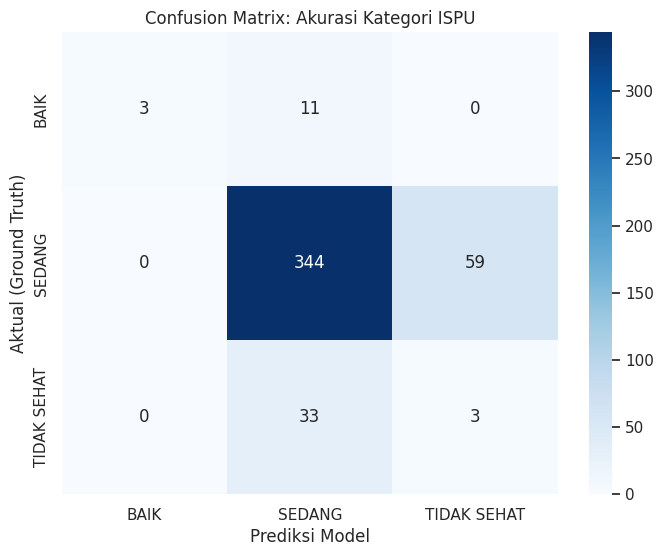


Contoh kesalahan prediksi (Miss-classification):


,time,lokasi_spku,max,pred_max,cat_actual,cat_pred
272,2024-09-01,DKI4,81.0,127.495248,SEDANG,TIDAK SEHAT
363,2024-09-02,DKI5,85.0,100.496571,SEDANG,TIDAK SEHAT
364,2024-09-03,DKI5,89.0,100.328069,SEDANG,TIDAK SEHAT
274,2024-09-04,DKI4,79.0,102.334583,SEDANG,TIDAK SEHAT
275,2024-09-05,DKI4,118.0,93.153343,TIDAK SEHAT,SEDANG
276,2024-09-06,DKI4,82.0,102.619634,SEDANG,TIDAK SEHAT
97,2024-09-07,DKI2,81.0,100.035728,SEDANG,TIDAK SEHAT
278,2024-09-08,DKI4,83.0,103.062778,SEDANG,TIDAK SEHAT
282,2024-09-12,DKI4,65.0,101.262179,SEDANG,TIDAK SEHAT
373,2024-09-12,DKI5,103.0,89.841113,TIDAK SEHAT,SEDANG


In [94]:
y_true_numeric = val_df_result['max']
y_pred_numeric = val_df_result['pred_max']

def get_category(score):
    if score <= 50: return "BAIK"
    elif score <= 100: return "SEDANG"
    else: return "TIDAK SEHAT"

v_get_category = np.vectorize(get_category)

y_true_cat = v_get_category(y_true_numeric)
y_pred_cat = v_get_category(y_pred_numeric)

f1_macro = f1_score(y_true_cat, y_pred_cat, average='macro')
accuracy = accuracy_score(y_true_cat, y_pred_cat)

print("="*50)
print(f"HASIL EVALUASI KLASIFIKASI (Recursive Forecasting)")
print("="*50)
print(f"F1 Score (Macro) : {f1_macro:.4f}")
print(f"Accuracy         : {accuracy:.4f}")
print("="*50)

print("\nDetail Laporan per Kategori:")
print(classification_report(y_true_cat, y_pred_cat))

plt.figure(figsize=(8, 6))

labels = ["BAIK", "SEDANG", "TIDAK SEHAT"] 
existing_labels = [label for label in labels if label in np.unique(y_true_cat) or label in np.unique(y_pred_cat)]

cm = confusion_matrix(y_true_cat, y_pred_cat, labels=existing_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=existing_labels, yticklabels=existing_labels)

plt.xlabel('Prediksi Model')
plt.ylabel('Aktual (Ground Truth)')
plt.title('Confusion Matrix: Akurasi Kategori ISPU')
plt.show()

print("\nContoh kesalahan prediksi (Miss-classification):")
val_df_result['cat_actual'] = y_true_cat
val_df_result['cat_pred'] = y_pred_cat

misses = val_df_result[val_df_result['cat_actual'] != val_df_result['cat_pred']]
if not misses.empty:
    display(misses[['time', 'lokasi_spku', 'max', 'pred_max', 'cat_actual', 'cat_pred']].head(10))
else:
    print("Hebat! Tidak ada kesalahan klasifikasi.")

In [95]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, classification_report

# --- 1. Persiapan Data ---
results_per_station = []
df_optimized = val_df_result.copy()

# Buat kolom baru untuk prediksi hasil tuning
df_optimized['pred_cat_optimized'] = "TIDAK DITENTUKAN" 

# Ground Truth selalu menggunakan aturan baku (Standard ISPU)
def get_standard_category(score):
    if score <= 50: return 0      # BAIK
    elif score <= 100: return 1   # SEDANG
    else: return 2                # TIDAK SEHAT

v_standard = np.vectorize(get_standard_category)

# --- 2. Loop Tuning Per Stasiun ---
stations = df_optimized['lokasi_spku'].unique()

print(f"Memulai Tuning Threshold Spesifik untuk {len(stations)} Stasiun...\n")
print(f"{'STASIUN':<10} | {'F1 AWAL':<10} | {'F1 BARU':<10} | {'BEST T1':<8} | {'BEST T2':<8}")
print("-" * 65)

# Range pencarian threshold (Grid Search)
search_range_t1 = np.arange(40, 65, 1)   # Sekitar 50
search_range_t2 = np.arange(90, 115, 1)  # Sekitar 100

station_thresholds = {}

for station in stations:
    # Filter data khusus stasiun ini
    mask = df_optimized['lokasi_spku'] == station
    y_true_local = df_optimized.loc[mask, 'max'].values
    y_pred_local = df_optimized.loc[mask, 'pred_max'].values
    
    # Ground Truth Lokal (Label Asli)
    y_true_encoded = v_standard(y_true_local)
    
    # Hitung F1 Awal (Pakai threshold standar 50 & 100)
    preds_initial = np.zeros(len(y_pred_local))
    preds_initial[y_pred_local > 50] = 1
    preds_initial[y_pred_local > 100] = 2
    initial_f1 = f1_score(y_true_encoded, preds_initial, average='macro')
    
    # --- Grid Search Lokal ---
    best_f1 = -1
    best_t1 = 50
    best_t2 = 100
    
    for t1 in search_range_t1:
        for t2 in search_range_t2:
            if t1 >= t2: continue 

            # Prediksi dengan threshold dinamis
            preds_candidate = np.zeros(len(y_pred_local))
            preds_candidate[y_pred_local > t1] = 1
            preds_candidate[y_pred_local > t2] = 2
            
            score = f1_score(y_true_encoded, preds_candidate, average='macro')
            
            if score > best_f1:
                best_f1 = score
                best_t1 = t1
                best_t2 = t2
    
    # Simpan threshold terbaik
    station_thresholds[station] = {'t1': best_t1, 't2': best_t2}
    
    # Terapkan prediksi terbaik ke DataFrame utama
    final_preds_encoded = np.zeros(len(y_pred_local))
    final_preds_encoded[y_pred_local > best_t1] = 1
    final_preds_encoded[y_pred_local > best_t2] = 2
    
    # Konversi balik ke Label Teks
    label_map = {0: 'BAIK', 1: 'SEDANG', 2: 'TIDAK SEHAT'}
    final_labels = [label_map[x] for x in final_preds_encoded]
    
    df_optimized.loc[mask, 'pred_cat_optimized'] = final_labels
    
    # Tampilkan Progress
    print(f"{station:<10} | {initial_f1:.4f}     | {best_f1:.4f}     | {best_t1:<8} | {best_t2:<8}")

print("-" * 65)

# --- 3. Evaluasi Global Setelah Tuning ---
# Bandingkan F1 Score Global sebelum dan sesudah tuning per stasiun
y_true_global_numeric = df_optimized['max'].values
y_true_global_cat = [label_map[x] for x in v_standard(y_true_global_numeric)]

# Kategori Awal (Standard Threshold)
y_pred_initial_cat = df_optimized['pred_max'].apply(lambda x: 'BAIK' if x <= 50 else ('SEDANG' if x <= 100 else 'TIDAK SEHAT'))

score_initial_global = f1_score(y_true_global_cat, y_pred_initial_cat, average='macro')
score_optimized_global = f1_score(y_true_global_cat, df_optimized['pred_cat_optimized'], average='macro')

print("\n" + "="*50)
print("PERBANDINGAN AKHIR (GLOBAL SCORE)")
print("="*50)
print(f"F1 Macro Awal (Threshold Standar) : {score_initial_global:.4f}")
print(f"F1 Macro Baru (Threshold Lokal)   : {score_optimized_global:.4f}")
print(f"Peningkatan Score                 : +{(score_optimized_global - score_initial_global):.4f}")
print("="*50)

print("\nDetail Laporan (Optimized):")
print(classification_report(y_true_global_cat, df_optimized['pred_cat_optimized']))

Memulai Tuning Threshold Spesifik untuk 5 Stasiun...

STASIUN    | F1 AWAL    | F1 BARU    | BEST T1  | BEST T2 
-----------------------------------------------------------------
DKI1       | 0.4090     | 0.4822     | 52       | 99      
DKI2       | 0.4417     | 0.4770     | 40       | 112     
DKI5       | 0.4044     | 0.4817     | 60       | 99      
DKI3       | 0.4886     | 0.4886     | 40       | 97      
DKI4       | 0.4034     | 0.5198     | 40       | 109     
-----------------------------------------------------------------

PERBANDINGAN AKHIR (GLOBAL SCORE)
F1 Macro Awal (Threshold Standar) : 0.4280
F1 Macro Baru (Threshold Lokal)   : 0.5073
Peningkatan Score                 : +0.0793

Detail Laporan (Optimized):
              precision    recall  f1-score   support

        BAIK       1.00      0.36      0.53        14
      SEDANG       0.90      0.95      0.93       403
 TIDAK SEHAT       0.10      0.06      0.07        36

    accuracy                           0.86     

In [96]:
val_start_date = pd.to_datetime('2024-09-01')
val_end_date = pd.to_datetime('2024-11-30')
warmup_start_date = val_start_date - pd.Timedelta(days=7) # 25 Agustus 2024

exclude_cols = ['max', 'time', 'tanggal', 'date_key', 'year', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2', 'category', 'critical']
exclude_cols += [col for col in df_combined.columns if 'target_lag' in col]

exclude_cols.extend(['month', 'day']) 

weather_features = [col for col in df_combined.select_dtypes(include=[np.number]).columns 
                    if col not in exclude_cols]

train_data_hist = df_combined[df_combined['time'] < val_start_date].copy()
train_data_hist['month'] = train_data_hist['time'].dt.month
train_data_hist['day'] = train_data_hist['time'].dt.day

print(f"Data Training Historis: {train_data_hist['time'].min().date()} s.d {train_data_hist['time'].max().date()}")
print(f"Fitur Cuaca yang akan diklimatologi ({len(weather_features)}): {weather_features[:5]}...")

Data Training Historis: 2010-01-07 s.d 2024-08-31
Fitur Cuaca yang akan diklimatologi (395): ['temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'precipitation_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)']...


In [97]:
# Pastikan weather_features benar-benar bersih (Double check)
weather_features = [f for f in weather_features if f not in ['month', 'day', 'lokasi_spku']]

# Hitung Rata-rata Cuaca per Lokasi, Bulan, dan Hari dari data Training
climatology_df = train_data_hist.groupby(['lokasi_spku', 'month', 'day'])[weather_features].mean().reset_index()

# Opsional: Hitung juga rata-rata target (max) sebagai fallback/referensi
target_climatology = train_data_hist.groupby(['lokasi_spku', 'month', 'day'])['max'].mean().reset_index()
target_climatology.rename(columns={'max': 'historical_max_avg'}, inplace=True)

# Gabungkan
climatology_df = pd.merge(climatology_df, target_climatology, on=['lokasi_spku', 'month', 'day'])

print("Data Klimatologi (Rata-rata Historis) Berhasil Dibuat!")
display(climatology_df.head())

Data Klimatologi (Rata-rata Historis) Berhasil Dibuat!


,lokasi_spku,month,day,temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),temperature_2m_mean (°C),relative_humidity_2m_mean (%),cloud_cover_mean (%),surface_pressure_mean (hPa),wind_gusts_10m_max (km/h),winddirection_10m_dominant (°),relative_humidity_2m_max (%),relative_humidity_2m_min (%),cloud_cover_max (%),cloud_cover_min (%),wind_gusts_10m_mean (km/h),wind_speed_10m_mean (km/h),wind_gusts_10m_min (km/h),wind_speed_10m_min (km/h),surface_pressure_max (hPa),surface_pressure_min (hPa),day_year,day_week,time_month_sin,time_month_cos,time_day_year_sin,time_day_year_cos,time_dw_sin,time_dw_cos,time_dm_sin,time_dm_cos,wind_speed_10m_max_x,wind_speed_10m_max_y,temperature_2m_max (°C)_diff_lag_-4,temperature_2m_max (°C)_diff_lag_-3,temperature_2m_max (°C)_diff_lag_-2,temperature_2m_max (°C)_diff_lag_-1,temperature_2m_max (°C)_diff_lag_1,temperature_2m_max (°C)_diff_lag_2,temperature_2m_max (°C)_diff_lag_3,temperature_2m_max (°C)_diff_lag_4,temperature_2m_min (°C)_diff_lag_-4,temperature_2m_min (°C)_diff_lag_-3,temperature_2m_min (°C)_diff_lag_-2,temperature_2m_min (°C)_diff_lag_-1,temperature_2m_min (°C)_diff_lag_1,temperature_2m_min (°C)_diff_lag_2,temperature_2m_min (°C)_diff_lag_3,temperature_2m_min (°C)_diff_lag_4,precipitation_sum (mm)_diff_lag_-4,precipitation_sum (mm)_diff_lag_-3,precipitation_sum (mm)_diff_lag_-2,precipitation_sum (mm)_diff_lag_-1,precipitation_sum (mm)_diff_lag_1,precipitation_sum (mm)_diff_lag_2,precipitation_sum (mm)_diff_lag_3,precipitation_sum (mm)_diff_lag_4,precipitation_hours (h)_diff_lag_-4,precipitation_hours (h)_diff_lag_-3,precipitation_hours (h)_diff_lag_-2,precipitation_hours (h)_diff_lag_-1,precipitation_hours (h)_diff_lag_1,precipitation_hours (h)_diff_lag_2,precipitation_hours (h)_diff_lag_3,precipitation_hours (h)_diff_lag_4,wind_speed_10m_max (km/h)_diff_lag_-4,wind_speed_10m_max (km/h)_diff_lag_-3,wind_speed_10m_max (km/h)_diff_lag_-2,wind_speed_10m_max (km/h)_diff_lag_-1,wind_speed_10m_max (km/h)_diff_lag_1,wind_speed_10m_max (km/h)_diff_lag_2,wind_speed_10m_max (km/h)_diff_lag_3,wind_speed_10m_max (km/h)_diff_lag_4,wind_direction_10m_dominant (°)_diff_lag_-4,wind_direction_10m_dominant (°)_diff_lag_-3,wind_direction_10m_dominant (°)_diff_lag_-2,wind_direction_10m_dominant (°)_diff_lag_-1,wind_direction_10m_dominant (°)_diff_lag_1,wind_direction_10m_dominant (°)_diff_lag_2,wind_direction_10m_dominant (°)_diff_lag_3,wind_direction_10m_dominant (°)_diff_lag_4,shortwave_radiation_sum (MJ/m²)_diff_lag_-4,shortwave_radiation_sum (MJ/m²)_diff_lag_-3,shortwave_radiation_sum (MJ/m²)_diff_lag_-2,shortwave_radiation_sum (MJ/m²)_diff_lag_-1,shortwave_radiation_sum (MJ/m²)_diff_lag_1,shortwave_radiation_sum (MJ/m²)_diff_lag_2,shortwave_radiation_sum (MJ/m²)_diff_lag_3,shortwave_radiation_sum (MJ/m²)_diff_lag_4,temperature_2m_mean (°C)_diff_lag_-4,temperature_2m_mean (°C)_diff_lag_-3,temperature_2m_mean (°C)_diff_lag_-2,temperature_2m_mean (°C)_diff_lag_-1,temperature_2m_mean (°C)_diff_lag_1,temperature_2m_mean (°C)_diff_lag_2,temperature_2m_mean (°C)_diff_lag_3,temperature_2m_mean (°C)_diff_lag_4,relative_humidity_2m_mean (%)_diff_lag_-4,relative_humidity_2m_mean (%)_diff_lag_-3,relative_humidity_2m_mean (%)_diff_lag_-2,relative_humidity_2m_mean (%)_diff_lag_-1,relative_humidity_2m_mean (%)_diff_lag_1,relative_humidity_2m_mean (%)_diff_lag_2,relative_humidity_2m_mean (%)_diff_lag_3,relative_humidity_2m_mean (%)_diff_lag_4,cloud_cover_mean (%)_diff_lag_-4,cloud_cover_mean (%)_diff_lag_-3,cloud_cover_mean (%)_diff_lag_-2,cloud_cover_mean (%)_diff_lag_-1,cloud_cover_mean (%)_diff_lag_1,cloud_cover_mean (%)_diff_lag_2,cloud_cover_mean (%)_diff_lag_3,cloud_cover_mean (%)_diff_lag_4,surface_pressure_mean (hPa)_diff_lag_-4,surface_pressure_mean (hPa)_diff_lag_-3,surface_pressure_mean (hPa)_diff_lag_-2,surface_pressure_mean (hPa)_diff_lag_-1,surface_pressure_mean (hPa)_dif

In [98]:
# 1. Buat Rentang Tanggal (Warmup + Validasi)
dates_val = pd.date_range(start=warmup_start_date, end=val_end_date, freq='D')
unique_locations = df_combined['lokasi_spku'].unique()

# 2. Buat Skeleton Dataframe
val_sim_df = pd.MultiIndex.from_product(
    [dates_val, unique_locations], 
    names=['time', 'lokasi_spku']
).to_frame(index=False)

val_sim_df['month'] = val_sim_df['time'].dt.month
val_sim_df['day'] = val_sim_df['time'].dt.day

# 3. Merge dengan Data Klimatologi (Menggantikan Cuaca Asli)
val_sim_df = pd.merge(val_sim_df, climatology_df, on=['lokasi_spku', 'month', 'day'], how='left')

# 4. Merge dengan Anchor Median (Fitur Penting Anda)
if 'anchor_clim_median' not in val_sim_df.columns:
    # Pastikan anchor_lookup sudah ada dari proses training sebelumnya
    val_sim_df = pd.merge(val_sim_df, anchor_lookup, on=['lokasi_spku', 'month', 'day'], how='left')
    # Isi NaN pada anchor jika ada
    val_sim_df['anchor_clim_median'] = val_sim_df['anchor_clim_median'].fillna(train_data_hist['max'].median())

# 5. SETUP WARM-UP vs BLIND TARGET
# Ambil data asli untuk mengisi periode Warm-up (agar Lag terbentuk benar)
original_subset = df_combined[['time', 'lokasi_spku', 'max']].copy()
val_sim_df = pd.merge(val_sim_df, original_subset, on=['time', 'lokasi_spku'], how='left', suffixes=('', '_original'))

# Kolom 'max' adalah yang akan kita prediksi
# Aturan:
# - Periode Warmup (< 1 Sept): Pakai Nilai Asli
# - Periode Validasi (>= 1 Sept): Set NaN (Blind)

mask_warmup = val_sim_df['time'] < val_start_date
val_sim_df.loc[~mask_warmup, 'max'] = np.nan # Kosongkan target masa depan

print("Dataset Simulasi Validasi Terbentuk.")
print(f"Warm-up (Isi Asli): {warmup_start_date.date()} s.d {(val_start_date - pd.Timedelta(days=1)).date()}")
print(f"Target (NaN/Blind): {val_start_date.date()} s.d {val_end_date.date()}")

Dataset Simulasi Validasi Terbentuk.
Warm-up (Isi Asli): 2024-08-25 s.d 2024-08-31
Target (NaN/Blind): 2024-09-01 s.d 2024-11-30


In [99]:
# 1. Generate Lags Awal
val_sim_df = val_sim_df.sort_values(['lokasi_spku', 'time'])
lags = [1, 2, 3]

for lag in lags:
    val_sim_df[f'target_lag_{lag}'] = val_sim_df.groupby('lokasi_spku')['max'].shift(lag)

# 2. Filter hanya mulai dari tanggal forecast (setelah warmup)
val_forecast_input = val_sim_df[val_sim_df['time'] >= val_start_date].copy()

# Tambahkan fitur 'year' statis 2024 (karena ini validasi 2024)
if 'year' in features:
    val_forecast_input['year'] = 2024

# 3. Jalankan Recursive Forecast
print("Menjalankan Recursive Forecast pada Data Validasi (Blind)...")
val_results_clim = recursive_forecast(model, val_forecast_input, features, lags=[1, 2, 3])

print("\nSelesai. Contoh Hasil:")
display(val_results_clim[['time', 'lokasi_spku', 'pred_max', 'target_lag_1']].head())

Menjalankan Recursive Forecast pada Data Validasi (Blind)...
Memulai Recursive Forecasting untuk 91 hari...

Selesai. Contoh Hasil:


,time,lokasi_spku,pred_max,target_lag_1
35,2024-09-01,DKI1,76.157025,75.0
36,2024-09-01,DKI2,89.038743,80.0
37,2024-09-01,DKI3,61.724028,47.0
38,2024-09-01,DKI4,117.752402,135.0
39,2024-09-01,DKI5,89.495085,80.0


METRIK REGRESI (Climatology Validation)
MAE  : 15.2524
RMSE : 19.2523
R2   : -0.2650

METRIK KLASIFIKASI (Climatology Validation)
F1 Score (Macro) : 0.3721
Accuracy         : 0.8808
--------------------------------------------------
              precision    recall  f1-score   support

        BAIK       1.00      0.07      0.13        14
      SEDANG       0.89      0.99      0.94       403
 TIDAK SEHAT       0.14      0.03      0.05        36

    accuracy                           0.88       453
   macro avg       0.68      0.36      0.37       453
weighted avg       0.84      0.88      0.84       453



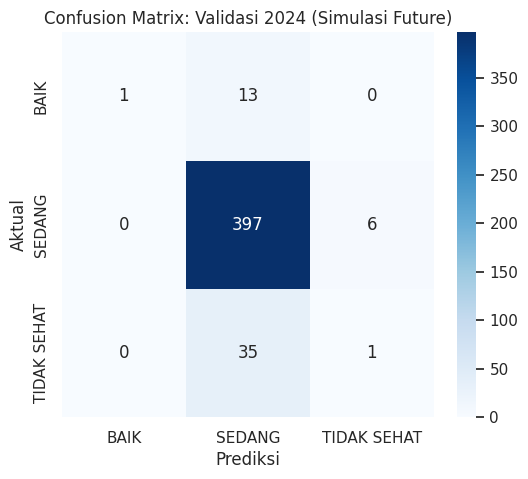

In [100]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Persiapan Data ---
# Ambil Ground Truth (Nilai Asli) dari df_combined original
truth_df = df_combined[(df_combined['time'] >= val_start_date) & 
                       (df_combined['time'] <= val_end_date)][['time', 'lokasi_spku', 'max']].copy()
truth_df.rename(columns={'max': 'actual_max'}, inplace=True)

# Merge dengan Hasil Prediksi
eval_df = pd.merge(val_results_clim, truth_df, on=['time', 'lokasi_spku'], how='inner')

y_true = eval_df['actual_max']
y_pred = eval_df['pred_max']

# --- 2. Evaluasi Regresi ---
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("="*50)
print("METRIK REGRESI (Climatology Validation)")
print("="*50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

# --- 3. Evaluasi Klasifikasi ---
# Fungsi Kategori
def get_category(score):
    if score <= 50: return "BAIK"
    elif score <= 100: return "SEDANG"
    else: return "TIDAK SEHAT"

v_cat = np.vectorize(get_category)
y_true_cat = v_cat(y_true)
y_pred_cat = v_cat(y_pred)

f1 = f1_score(y_true_cat, y_pred_cat, average='macro')
acc = (y_true_cat == y_pred_cat).mean()

print("\n" + "="*50)
print("METRIK KLASIFIKASI (Climatology Validation)")
print("="*50)
print(f"F1 Score (Macro) : {f1:.4f}")
print(f"Accuracy         : {acc:.4f}")
print("-" * 50)
print(classification_report(y_true_cat, y_pred_cat))

# --- 4. Visualisasi Confusion Matrix ---
plt.figure(figsize=(6, 5))
labels = ["BAIK", "SEDANG", "TIDAK SEHAT"]
existing_labels = [l for l in labels if l in np.unique(y_true_cat) or l in np.unique(y_pred_cat)]
cm = confusion_matrix(y_true_cat, y_pred_cat, labels=existing_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=existing_labels, yticklabels=existing_labels)
plt.title("Confusion Matrix: Validasi 2024 (Simulasi Future)")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

In [101]:
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, classification_report

# --- 1. Persiapan Data (Gabungkan Prediksi & Kebenaran) ---
# Ambil Ground Truth (Nilai Asli)
truth_df = df_combined[(df_combined['time'] >= val_start_date) & 
                       (df_combined['time'] <= val_end_date)][['time', 'lokasi_spku', 'max']].copy()
truth_df.rename(columns={'max': 'actual_max'}, inplace=True)

# Merge dengan Hasil Prediksi Recursive
df_tuning = pd.merge(val_results_clim, truth_df, on=['time', 'lokasi_spku'], how='inner')

# Buat kolom untuk menyimpan hasil optimasi
df_tuning['pred_cat_optimized'] = "TIDAK DITENTUKAN"

# Fungsi Ground Truth (Selalu Pakai Standar Baku Pemerintah)
def get_standard_category(score):
    if score <= 50: return 0      # 0 = BAIK
    elif score <= 100: return 1   # 1 = SEDANG
    else: return 2                # 2 = TIDAK SEHAT

v_standard = np.vectorize(get_standard_category)

# --- 2. Loop Tuning Per Stasiun ---
stations = df_tuning['lokasi_spku'].unique()

print(f"Sedang Mencari Threshold Terbaik untuk {len(stations)} Stasiun (Validasi 2024)...\n")
print(f"{'STASIUN':<10} | {'F1 AWAL':<10} | {'F1 BARU':<10} | {'BEST T1':<8} | {'BEST T2':<8}")
print("-" * 65)

# Range Grid Search
search_range_t1 = np.arange(40, 65, 1)   # Cari sekitar 50 (40 s.d 64)
search_range_t2 = np.arange(90, 115, 1)  # Cari sekitar 100 (90 s.d 114)

station_thresholds = {} # Simpan kamus threshold untuk dipakai nanti

for station in stations:
    # Filter data per stasiun
    mask = df_tuning['lokasi_spku'] == station
    y_true_local = df_tuning.loc[mask, 'actual_max'].values
    y_pred_local = df_tuning.loc[mask, 'pred_max'].values
    
    # Encode Ground Truth (Standar)
    y_true_encoded = v_standard(y_true_local)
    
    # 1. Hitung F1 Baseline (Standar 50 & 100)
    preds_initial = np.zeros(len(y_pred_local))
    preds_initial[y_pred_local > 50] = 1
    preds_initial[y_pred_local > 100] = 2
    initial_f1 = f1_score(y_true_encoded, preds_initial, average='macro')
    
    # 2. Grid Search Mencari T1 dan T2 Terbaik
    best_f1 = -1
    best_t1 = 50
    best_t2 = 100
    
    for t1 in search_range_t1:
        for t2 in search_range_t2:
            if t1 >= t2: continue # T1 harus lebih kecil dari T2

            # Prediksi dummy dengan threshold saat ini
            preds_candidate = np.zeros(len(y_pred_local))
            preds_candidate[y_pred_local > t1] = 1
            preds_candidate[y_pred_local > t2] = 2
            
            # Hitung F1 Score
            score = f1_score(y_true_encoded, preds_candidate, average='macro')
            
            if score > best_f1:
                best_f1 = score
                best_t1 = t1
                best_t2 = t2
    
    # Simpan Hasil Terbaik
    station_thresholds[station] = {'t1': best_t1, 't2': best_t2}
    
    # Terapkan Threshold Terbaik ke DataFrame
    final_preds_encoded = np.zeros(len(y_pred_local))
    final_preds_encoded[y_pred_local > best_t1] = 1
    final_preds_encoded[y_pred_local > best_t2] = 2
    
    label_map = {0: 'BAIK', 1: 'SEDANG', 2: 'TIDAK SEHAT'}
    final_labels = [label_map[x] for x in final_preds_encoded]
    
    df_tuning.loc[mask, 'pred_cat_optimized'] = final_labels
    
    print(f"{station:<10} | {initial_f1:.4f}     | {best_f1:.4f}     | {best_t1:<8} | {best_t2:<8}")

print("-" * 65)

# --- 3. Evaluasi Global (Sebelum vs Sesudah) ---
# Siapkan Kategori Asli (Ground Truth)
y_true_global_labels = [label_map[x] for x in v_standard(df_tuning['actual_max'].values)]

# Siapkan Prediksi Awal (Standar)
y_pred_initial_labels = df_tuning['pred_max'].apply(lambda x: 'BAIK' if x <= 50 else ('SEDANG' if x <= 100 else 'TIDAK SEHAT'))

# Hitung Score Global
score_initial = f1_score(y_true_global_labels, y_pred_initial_labels, average='macro')
score_optimized = f1_score(y_true_global_labels, df_tuning['pred_cat_optimized'], average='macro')
print("="*50)

print("\nDetail Laporan Klasifikasi (Setelah Optimasi):")
print(classification_report(y_true_global_labels, df_tuning['pred_cat_optimized']))

Sedang Mencari Threshold Terbaik untuk 5 Stasiun (Validasi 2024)...

STASIUN    | F1 AWAL    | F1 BARU    | BEST T1  | BEST T2 
-----------------------------------------------------------------
DKI1       | 0.3119     | 0.4822     | 57       | 90      
DKI2       | 0.4830     | 0.4830     | 40       | 94      
DKI3       | 0.4886     | 0.4886     | 40       | 92      
DKI4       | 0.5765     | 0.6076     | 40       | 102     
DKI5       | 0.3536     | 0.5098     | 64       | 101     
-----------------------------------------------------------------

Detail Laporan Klasifikasi (Setelah Optimasi):
              precision    recall  f1-score   support

        BAIK       1.00      0.43      0.60        14
      SEDANG       0.90      0.99      0.95       403
 TIDAK SEHAT       0.25      0.03      0.05        36

    accuracy                           0.90       453
   macro avg       0.72      0.48      0.53       453
weighted avg       0.85      0.90      0.86       453



In [102]:
exclude_cols = ['max', 'time', 'tanggal', 'date_key', 'year', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2']
exclude_cols += [col for col in df_combined.columns if 'target_lag' in col]

weather_features = [col for col in df_combined.select_dtypes(include=[np.number]).columns 
                    if col not in exclude_cols]

print(f"Fitur cuaca yang akan dirata-rata ({len(weather_features)} kolom):")
print(weather_features[:5]) # Tampilkan 5 contoh

Fitur cuaca yang akan dirata-rata (397 kolom):
['temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'precipitation_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)']


In [103]:
exclude_cols = ['max', 'time', 'tanggal', 'date_key', 'year', 'pm10', 'pm25', 'so2', 'co', 'o3', 'no2']

exclude_cols.extend(['month', 'day']) 
exclude_cols += [col for col in df_combined.columns if 'target_lag' in col]

weather_features = [col for col in df_combined.select_dtypes(include=[np.number]).columns 
                    if col not in exclude_cols]

print(f"Fitur cuaca yang akan dirata-rata ({len(weather_features)} kolom):")
print(weather_features[:5]) 

relevant_months = [8, 9, 10, 11]

historical_data = df_combined[df_combined['time'].dt.month.isin(relevant_months)].copy()
historical_data['month'] = historical_data['time'].dt.month
historical_data['day'] = historical_data['time'].dt.day

climatology_df = historical_data.groupby(['lokasi_spku', 'month', 'day'])[weather_features].mean().reset_index()

target_climatology = historical_data.groupby(['lokasi_spku', 'month', 'day'])['max'].mean().reset_index()
target_climatology.rename(columns={'max': 'historical_max_avg'}, inplace=True)

climatology_df = pd.merge(climatology_df, target_climatology, on=['lokasi_spku', 'month', 'day'])

print("Data Klimatologi Berhasil Dibuat!")

Fitur cuaca yang akan dirata-rata (395 kolom):
['temperature_2m_max (°C)', 'temperature_2m_min (°C)', 'precipitation_sum (mm)', 'precipitation_hours (h)', 'wind_speed_10m_max (km/h)']
Data Klimatologi Berhasil Dibuat!


In [104]:
dates_2025 = pd.date_range(start='2025-08-25', end='2025-11-30', freq='D')
unique_locations = df_combined['lokasi_spku'].unique()

future_df_clim = pd.MultiIndex.from_product(
    [dates_2025, unique_locations], 
    names=['time', 'lokasi_spku']
).to_frame(index=False)

future_df_clim['month'] = future_df_clim['time'].dt.month
future_df_clim['day'] = future_df_clim['time'].dt.day

future_df_clim = pd.merge(future_df_clim, climatology_df, on=['lokasi_spku', 'month', 'day'], how='left')

forecast_start_date = pd.to_datetime('2025-09-01')

future_df_clim['max'] = np.nan  

warmup_mask = future_df_clim['time'] < forecast_start_date
future_df_clim.loc[warmup_mask, 'max'] = future_df_clim.loc[warmup_mask, 'historical_max_avg']

future_df_clim.drop(columns=['historical_max_avg'], inplace=True)

if 'anchor_clim_median' not in future_df_clim.columns:
    future_df_clim = pd.merge(future_df_clim, anchor_lookup, on=['lokasi_spku', 'month', 'day'], how='left')

print("Dataset Future 2025 terbentuk.")
print(f"Warm-up data (Climatology): 25 Ags - 31 Ags (Terisi: {future_df_clim.loc[warmup_mask, 'max'].notna().all()})")
print(f"Target data (To be predicted): 1 Sept - 30 Nov (Isi Masih NaN)")

Dataset Future 2025 terbentuk.
Warm-up data (Climatology): 25 Ags - 31 Ags (Terisi: True)
Target data (To be predicted): 1 Sept - 30 Nov (Isi Masih NaN)


In [105]:
future_df_clim = future_df_clim.sort_values(['lokasi_spku', 'time'])

lags = [1, 2, 3]
target_col = 'max'

for lag in lags:
    future_df_clim[f'target_lag_{lag}'] = future_df_clim.groupby('lokasi_spku')[target_col].shift(lag)

future_forecast_clim = future_df_clim[future_df_clim['time'] >= forecast_start_date].copy()

if 'year' in features:
    print("Menambahkan kolom 'year' ke dataset forecast...")
    future_forecast_clim['year'] = 2025  
else:
    print("Kolom 'year' tidak ditemukan di fitur model, aman.")
    
future_results_clim = recursive_forecast(model, future_forecast_clim, features, lags=[1, 2, 3])

print("\n=== HASIL FORECAST 2025 (METODE CLIMATOLOGY/RATA-RATA) ===")
print(future_results_clim[['time', 'lokasi_spku', 'pred_max', 'target_lag_1']].head())

Menambahkan kolom 'year' ke dataset forecast...
Memulai Recursive Forecasting untuk 91 hari...

=== HASIL FORECAST 2025 (METODE CLIMATOLOGY/RATA-RATA) ===
         time lokasi_spku    pred_max  target_lag_1
35 2025-09-01        DKI1   71.704174     72.000000
36 2025-09-01        DKI2   89.849025     86.000000
37 2025-09-01        DKI3   77.215456     70.444444
38 2025-09-01        DKI4  102.053927     99.666667
39 2025-09-01        DKI5   86.609639     84.111111


In [106]:
import matplotlib.dates as mdates

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

viz_df = future_results_clim.copy()

viz_df['time'] = pd.to_datetime(viz_df['time'])

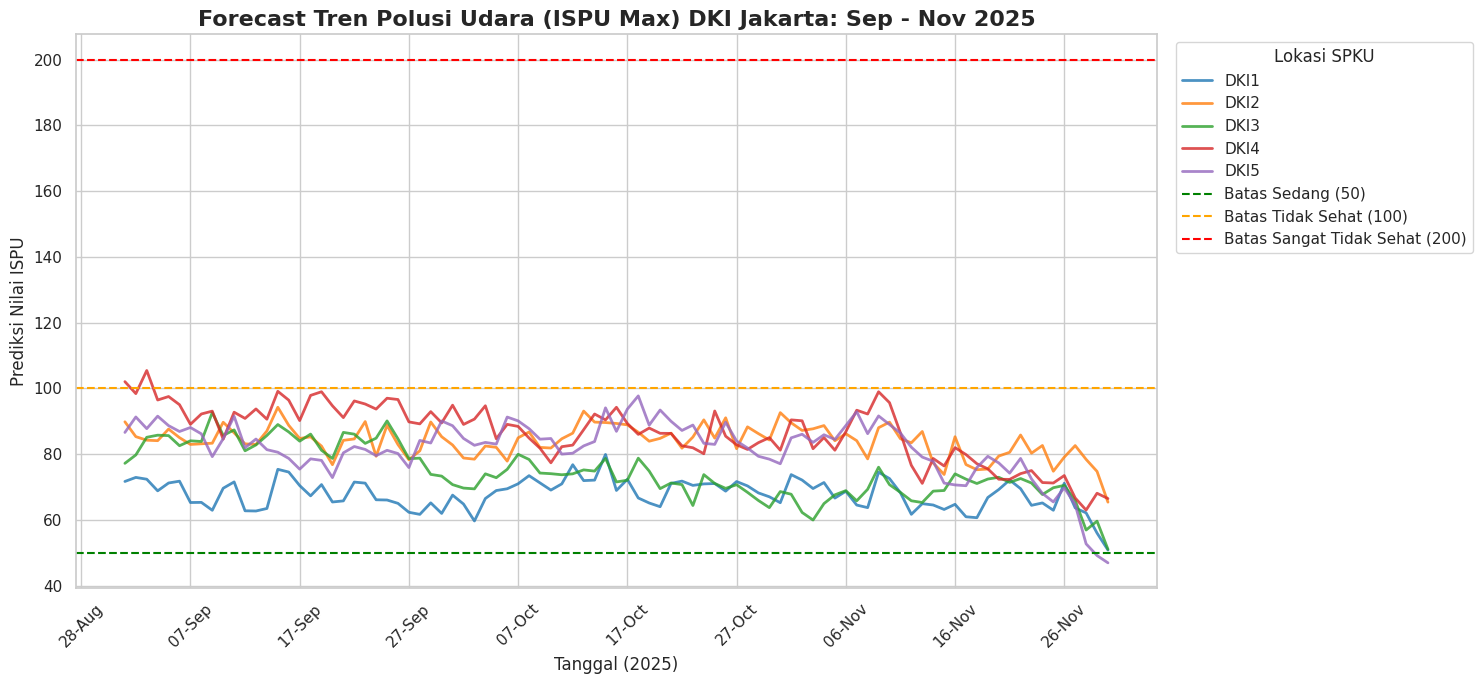

In [107]:
plt.figure(figsize=(15, 7))

sns.lineplot(
    data=viz_df, 
    x='time', 
    y='pred_max', 
    hue='lokasi_spku', 
    palette='tab10', 
    linewidth=2,
    alpha=0.8
)

plt.axhline(y=50, color='green', linestyle='--', linewidth=1.5, label='Batas Sedang (50)')
plt.axhline(y=100, color='orange', linestyle='--', linewidth=1.5, label='Batas Tidak Sehat (100)')
plt.axhline(y=200, color='red', linestyle='--', linewidth=1.5, label='Batas Sangat Tidak Sehat (200)')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))

plt.title('Forecast Tren Polusi Udara (ISPU Max) DKI Jakarta: Sep - Nov 2025', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal (2025)', fontsize=12)
plt.ylabel('Prediksi Nilai ISPU', fontsize=12)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Lokasi SPKU')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [108]:
import pandas as pd
import numpy as np

# --- 1. Setup Tanggal Validasi (Target: 2024) ---
# Kita gunakan periode yang sama dengan validasi sebelumnya agar apple-to-apple
val_start_date = pd.to_datetime('2024-09-01')
val_end_date = pd.to_datetime('2024-11-30')

# Geser 11 Bulan ke belakang untuk mencari data sumber
shift_months = 11
source_start_date = val_start_date - pd.DateOffset(months=shift_months) 
source_end_date = val_end_date - pd.DateOffset(months=shift_months)
source_start_with_buffer = source_start_date - pd.Timedelta(days=14) # Buffer untuk lag

print(f"Target Validasi : {val_start_date.date()} s.d {val_end_date.date()}")
print(f"Data Sumber (Asli): {source_start_date.date()} s.d {source_end_date.date()} (Mundur {shift_months} bulan)")

# --- 2. Ambil Data Sumber ---
# Ambil data dari masa lalu (2023)
val_df_11mo = df_combined[(df_combined['time'] >= source_start_with_buffer) & 
                          (df_combined['time'] <= source_end_date)].copy()

if len(val_df_11mo) == 0:
    print("ERROR: Data sumber tidak ditemukan!")
else:
    # --- 3. Shift Waktu ke Target (2024) ---
    # Ubah tanggal data lama menjadi tanggal target validasi
    val_df_11mo['time'] = val_df_11mo['time'] + pd.DateOffset(months=shift_months)
    
    # Update fitur waktu
    val_df_11mo['month'] = val_df_11mo['time'].dt.month
    val_df_11mo['day'] = val_df_11mo['time'].dt.day
    val_df_11mo['year'] = val_df_11mo['time'].dt.year

    # --- 4. Persiapan Blind Test ---
    # Hapus target asli di periode validasi agar model benar-benar meramal
    mask_future = val_df_11mo['time'] >= val_start_date
    val_df_11mo.loc[mask_future, 'max'] = np.nan

    # --- 5. Pasang Anchor/Climatology ---
    # Hapus anchor lama (jika terbawa dari 2023) dan pasang anchor training
    if 'anchor_clim_median' in val_df_11mo.columns:
        val_df_11mo = val_df_11mo.drop(columns=['anchor_clim_median'])
    
    # Merge anchor lookup (yang dibuat dari data training < Sept 2024)
    val_df_11mo = pd.merge(val_df_11mo, anchor_lookup, on=['lokasi_spku', 'month', 'day'], how='left')
    
    # Isi missing anchor dengan median global jika ada
    global_median = train_df['max'].median()
    val_df_11mo['anchor_clim_median'] = val_df_11mo['anchor_clim_median'].fillna(global_median)

    # --- 6. Generate Lags ---
    val_df_11mo = val_df_11mo.sort_values(['lokasi_spku', 'time'])
    lags = [1, 2, 3]
    for lag in lags:
        val_df_11mo[f'target_lag_{lag}'] = val_df_11mo.groupby('lokasi_spku')['max'].shift(lag)

    # Filter hanya data validasi (buang buffer)
    val_forecast_input = val_df_11mo[val_df_11mo['time'] >= val_start_date].copy()

    # --- 7. Jalankan Recursive Forecast ---
    print(f"Memulai forecast untuk {len(val_forecast_input)} baris...")
    results_11mo = recursive_forecast(model, val_forecast_input, features, lags=[1, 2, 3])

    print("\nForecast Selesai.")
    display(results_11mo[['time', 'lokasi_spku', 'pred_max']].head())

Target Validasi : 2024-09-01 s.d 2024-11-30
Data Sumber (Asli): 2023-10-01 s.d 2023-12-30 (Mundur 11 bulan)
Memulai forecast untuk 304 baris...
Memulai Recursive Forecasting untuk 60 hari...

Forecast Selesai.


,time,lokasi_spku,pred_max
13,2024-09-01,DKI1,114.751530
235,2024-09-01,DKI4,196.346034
307,2024-09-01,DKI5,89.368349
87,2024-09-01,DKI2,117.383967
161,2024-09-01,DKI3,97.354626


In [109]:
truth_df = df_combined[(df_combined['time'] >= val_start_date) & 
                       (df_combined['time'] <= val_end_date)][['time', 'lokasi_spku', 'max']].copy()
truth_df.rename(columns={'max': 'actual_max'}, inplace=True)

# Merge
eval_df_11mo = pd.merge(results_11mo, truth_df, on=['time', 'lokasi_spku'], how='inner')

y_true = eval_df_11mo['actual_max']
y_pred = eval_df_11mo['pred_max']

# --- 2. Metrik Regresi ---
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("="*50)
print("METRIK REGRESI (Metode Shift 11 Bulan)")
print("="*50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

# --- 3. Metrik Klasifikasi (Threshold Standar) ---
def get_standard_category(score):
    if score <= 50: return "BAIK"
    elif score <= 100: return "SEDANG"
    else: return "TIDAK SEHAT"

v_cat = np.vectorize(get_standard_category)
y_true_cat = v_cat(y_true)
y_pred_cat = v_cat(y_pred)

f1_std = f1_score(y_true_cat, y_pred_cat, average='macro')
print("\n" + "="*50)
print(f"METRIK KLASIFIKASI STANDAR (F1 Macro: {f1_std:.4f})")
print("="*50)
print(classification_report(y_true_cat, y_pred_cat))

METRIK REGRESI (Metode Shift 11 Bulan)
MAE  : 16.8407
RMSE : 23.4994
R2   : -1.9906

METRIK KLASIFIKASI STANDAR (F1 Macro: 0.5069)
              precision    recall  f1-score   support

      SEDANG       0.94      0.85      0.89       283
 TIDAK SEHAT       0.09      0.20      0.12        20

    accuracy                           0.81       303
   macro avg       0.51      0.53      0.51       303
weighted avg       0.88      0.81      0.84       303



In [110]:
# --- Tuning Threshold Per Stasiun ---
stations = eval_df_11mo['lokasi_spku'].unique()
df_tuning_11mo = eval_df_11mo.copy()
df_tuning_11mo['pred_cat_optimized'] = "TIDAK DITENTUKAN"

# Helper fungsi konversi angka 0,1,2
def get_numeric_cat(score):
    if score <= 50: return 0
    elif score <= 100: return 1
    else: return 2

v_num_cat = np.vectorize(get_numeric_cat)

print(f"Memulai Tuning Threshold (Metode 11 Bulan) untuk {len(stations)} Stasiun...\n")
print(f"{'STASIUN':<10} | {'F1 AWAL':<10} | {'F1 BARU':<10} | {'BEST T1':<8} | {'BEST T2':<8}")
print("-" * 65)

# Range Pencarian
search_range_t1 = np.arange(35, 65, 1)
search_range_t2 = np.arange(90, 115, 1)

station_thresholds_11mo = {}

for station in stations:
    mask = df_tuning_11mo['lokasi_spku'] == station
    y_true_local = df_tuning_11mo.loc[mask, 'actual_max'].values
    y_pred_local = df_tuning_11mo.loc[mask, 'pred_max'].values
    
    y_true_encoded = v_num_cat(y_true_local)
    
    # F1 Awal
    preds_init = np.zeros(len(y_pred_local))
    preds_init[y_pred_local > 50] = 1
    preds_init[y_pred_local > 100] = 2
    f1_initial = f1_score(y_true_encoded, preds_init, average='macro')
    
    # Grid Search
    best_f1 = -1
    best_t1, best_t2 = 50, 100
    
    for t1 in search_range_t1:
        for t2 in search_range_t2:
            if t1 >= t2: continue
            
            p_cand = np.zeros(len(y_pred_local))
            p_cand[y_pred_local > t1] = 1
            p_cand[y_pred_local > t2] = 2
            
            sc = f1_score(y_true_encoded, p_cand, average='macro')
            if sc > best_f1:
                best_f1 = sc
                best_t1, best_t2 = t1, t2
                
    # Simpan
    station_thresholds_11mo[station] = {'t1': best_t1, 't2': best_t2}
    
    # Apply
    final_preds = np.zeros(len(y_pred_local))
    final_preds[y_pred_local > best_t1] = 1
    final_preds[y_pred_local > best_t2] = 2
    
    label_map = {0: 'BAIK', 1: 'SEDANG', 2: 'TIDAK SEHAT'}
    df_tuning_11mo.loc[mask, 'pred_cat_optimized'] = [label_map[x] for x in final_preds]
    
    print(f"{station:<10} | {f1_initial:.4f}     | {best_f1:.4f}     | {best_t1:<8} | {best_t2:<8}")

print("-" * 65)

# Evaluasi Global Akhir
y_global_true = [label_map[x] for x in v_num_cat(df_tuning_11mo['actual_max'])]
f1_final_global = f1_score(y_global_true, df_tuning_11mo['pred_cat_optimized'], average='macro')

print(f"\nF1 Global Akhir (Optimized): {f1_final_global:.4f}")
print(classification_report(y_global_true, df_tuning_11mo['pred_cat_optimized']))

print("\n[PENTING] Simpan thresholds ini untuk dipakai saat forecast 2025:")
print(station_thresholds_11mo)

Memulai Tuning Threshold (Metode 11 Bulan) untuk 5 Stasiun...

STASIUN    | F1 AWAL    | F1 BARU    | BEST T1  | BEST T2 
-----------------------------------------------------------------
DKI1       | 0.4649     | 0.4874     | 35       | 112     
DKI4       | 0.4064     | 0.5083     | 35       | 114     
DKI5       | 0.4505     | 0.5379     | 35       | 98      
DKI2       | 0.4786     | 0.4831     | 35       | 102     
DKI3       | 0.4874     | 0.6494     | 35       | 97      
-----------------------------------------------------------------

F1 Global Akhir (Optimized): 0.5701
              precision    recall  f1-score   support

      SEDANG       0.95      0.90      0.92       283
 TIDAK SEHAT       0.17      0.30      0.22        20

    accuracy                           0.86       303
   macro avg       0.56      0.60      0.57       303
weighted avg       0.90      0.86      0.88       303


[PENTING] Simpan thresholds ini untuk dipakai saat forecast 2025:
{'DKI1': {'t1': np.i

In [111]:
forecast_start_date = pd.to_datetime('2025-09-01')
forecast_end_date = pd.to_datetime('2025-11-30')

shift_months = 11

source_start_date = forecast_start_date - pd.DateOffset(months=shift_months) 
source_start_with_buffer = source_start_date - pd.Timedelta(days=10) 

source_end_date = forecast_end_date - pd.DateOffset(months=shift_months)

print(f"Target Forecast: {forecast_start_date.date()} s.d {forecast_end_date.date()}")
print(f"Mengambil Data Sumber dari: {source_start_date.date()} s.d {source_end_date.date()} (Shift {shift_months} bulan)")

future_df_11mo = df_combined[(df_combined['time'] >= source_start_with_buffer) & 
                             (df_combined['time'] <= source_end_date)].copy()

if len(future_df_11mo) == 0:
    print("ERROR: Data sumber tidak ditemukan pada rentang tanggal tersebut!")
else:
    future_df_11mo['time'] = future_df_11mo['time'] + pd.DateOffset(months=shift_months)

    future_df_11mo['month'] = future_df_11mo['time'].dt.month
    future_df_11mo['day'] = future_df_11mo['time'].dt.day
    
    future_df_11mo['year'] = future_df_11mo['time'].dt.year

    mask_future = future_df_11mo['time'] >= forecast_start_date
    future_df_11mo.loc[mask_future, 'max'] = np.nan

    if 'anchor_clim_median' in future_df_11mo.columns:
        future_df_11mo = future_df_11mo.drop(columns=['anchor_clim_median'])
    
    future_df_11mo = pd.merge(future_df_11mo, anchor_lookup, on=['lokasi_spku', 'month', 'day'], how='left')

  
    future_df_11mo = future_df_11mo.sort_values(['lokasi_spku', 'time'])
    lags = [1, 2, 3]
    for lag in lags:
        future_df_11mo[f'target_lag_{lag}'] = future_df_11mo.groupby('lokasi_spku')['max'].shift(lag)

    future_forecast_11mo = future_df_11mo[future_df_11mo['time'] >= forecast_start_date].copy()

    print(f"Memulai forecast untuk {len(future_forecast_11mo)} baris data...")
    results_11mo = recursive_forecast(model, future_forecast_11mo, features, lags=[1, 2, 3])

    print("\n=== HASIL (Source: 11 Bulan Lalu) ===")
    print(results_11mo[['time', 'lokasi_spku', 'pred_max']].head())

Target Forecast: 2025-09-01 s.d 2025-11-30
Mengambil Data Sumber dari: 2024-10-01 s.d 2024-12-30 (Shift 11 bulan)
Memulai forecast untuk 454 baris data...
Memulai Recursive Forecasting untuk 90 hari...

=== HASIL (Source: 11 Bulan Lalu) ===
          time lokasi_spku   pred_max
10  2025-09-01        DKI1  80.976742
312 2025-09-01        DKI4  78.581768
212 2025-09-01        DKI3  72.924335
111 2025-09-01        DKI2  81.874137
413 2025-09-01        DKI5  93.057975


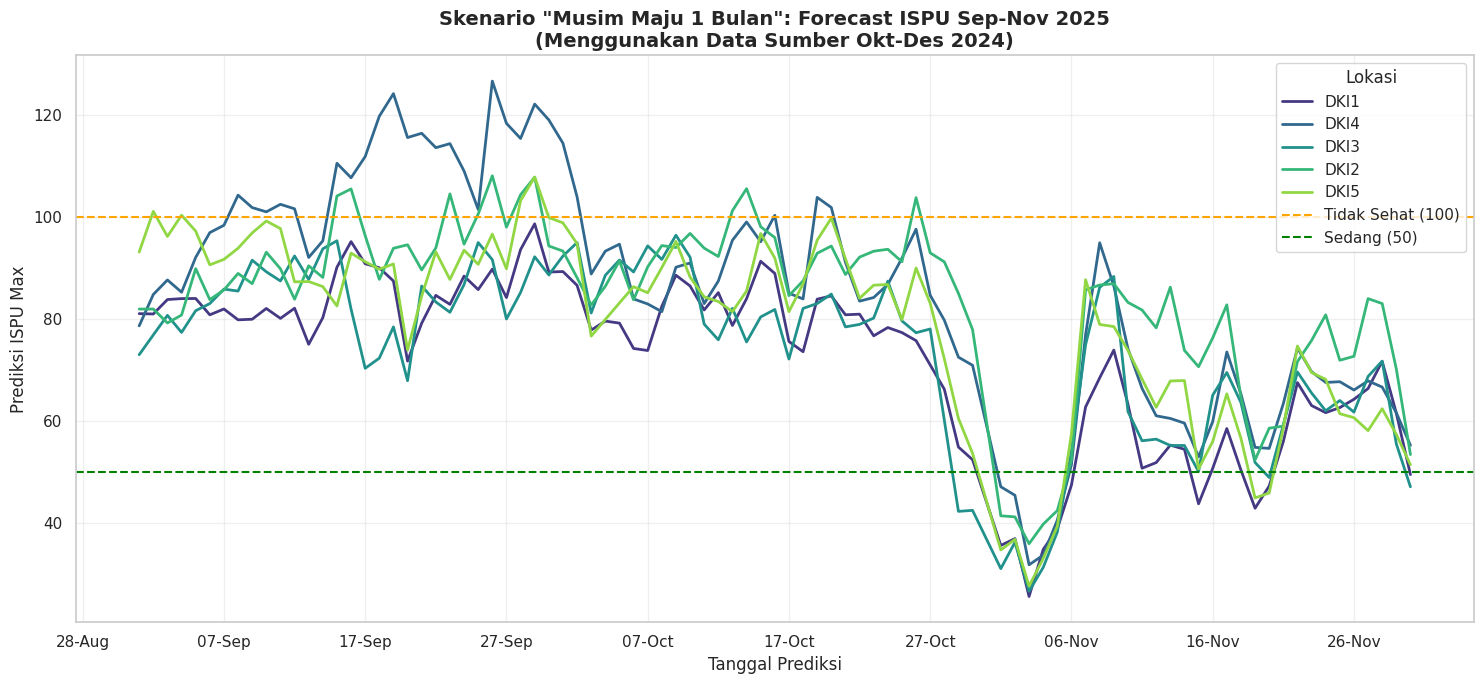

In [112]:
# Persiapan Data
viz_11mo = results_11mo.copy()
viz_11mo['time'] = pd.to_datetime(viz_11mo['time'])

plt.figure(figsize=(15, 7))

# 1. Plot Garis per Lokasi
sns.lineplot(
    data=viz_11mo, 
    x='time', 
    y='pred_max', 
    hue='lokasi_spku', 
    palette='viridis', 
    linewidth=2
)

# 2. Garis Batas Kategori
plt.axhline(100, color='orange', linestyle='--', label='Tidak Sehat (100)')
plt.axhline(50, color='green', linestyle='--', label='Sedang (50)')

# 3. Format Tanggal
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))

plt.title('Skenario "Musim Maju 1 Bulan": Forecast ISPU Sep-Nov 2025\n(Menggunakan Data Sumber Okt-Des 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal Prediksi')
plt.ylabel('Prediksi ISPU Max')
plt.legend(title='Lokasi')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [113]:
val_start_date = pd.to_datetime('2024-09-01')
val_end_date = pd.to_datetime('2024-11-30')

# Skenario: Mundur 340 Hari
days_back = 340

source_start_date = val_start_date - pd.Timedelta(days=days_back)
source_start_with_buffer = source_start_date - pd.Timedelta(days=14) 

duration = val_end_date - val_start_date
source_end_date = source_start_date + duration

print(f"Skenario        : Mundur {days_back} Hari")
print(f"Target Validasi : {val_start_date.date()} s.d {val_end_date.date()}")
print(f"Sumber Data     : {source_start_date.date()} s.d {source_end_date.date()} (Tahun 2023)")

# --- 2. Ambil Data Sumber ---
df_days = df_combined[(df_combined['time'] >= source_start_with_buffer) & 
                      (df_combined['time'] <= source_end_date)].copy()

if len(df_days) == 0:
    print("ERROR: Tidak ada data pada rentang hari tersebut!")
else:
    df_days['time'] = df_days['time'] + pd.Timedelta(days=days_back)

    # Update fitur waktu
    df_days['month'] = df_days['time'].dt.month
    df_days['day'] = df_days['time'].dt.day
    df_days['year'] = df_days['time'].dt.year

    mask_future = df_days['time'] >= val_start_date
    df_days.loc[mask_future, 'max'] = np.nan

    if 'anchor_clim_median' in df_days.columns:
        df_days = df_days.drop(columns=['anchor_clim_median'])
    
    df_days = pd.merge(df_days, anchor_lookup, on=['lokasi_spku', 'month', 'day'], how='left')
    
    global_median = train_df['max'].median()
    df_days['anchor_clim_median'] = df_days['anchor_clim_median'].fillna(global_median)

    df_days = df_days.sort_values(['lokasi_spku', 'time'])
    lags = [1, 2, 3]
    for lag in lags:
        df_days[f'target_lag_{lag}'] = df_days.groupby('lokasi_spku')['max'].shift(lag)

    val_forecast_days = df_days[df_days['time'] >= val_start_date].copy()

    print(f"Memulai forecast untuk {len(val_forecast_days)} baris data...")
    results_days = recursive_forecast(model, val_forecast_days, features, lags=[1, 2, 3])

    print("\nForecast Selesai.")
    display(results_days[['time', 'lokasi_spku', 'pred_max']].head())

Skenario        : Mundur 340 Hari
Target Validasi : 2024-09-01 s.d 2024-11-30
Sumber Data     : 2023-09-27 s.d 2023-12-26 (Tahun 2023)
Memulai forecast untuk 319 baris data...
Memulai Recursive Forecasting untuk 64 hari...

Forecast Selesai.


,time,lokasi_spku,pred_max
14,2024-09-01,DKI1,89.512990
248,2024-09-01,DKI4,217.054344
170,2024-09-01,DKI3,74.756262
324,2024-09-01,DKI5,81.725625
92,2024-09-01,DKI2,104.514338


In [114]:
truth_df = df_combined[(df_combined['time'] >= val_start_date) & 
                       (df_combined['time'] <= val_end_date)][['time', 'lokasi_spku', 'max']].copy()
truth_df.rename(columns={'max': 'actual_max'}, inplace=True)

# Merge
eval_df_days = pd.merge(results_days, truth_df, on=['time', 'lokasi_spku'], how='inner')

y_true = eval_df_days['actual_max']
y_pred = eval_df_days['pred_max']

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("="*50)
print(f"METRIK REGRESI (Metode Mundur {days_back} Hari)")
print("="*50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

def get_standard_category(score):
    if score <= 50: return "BAIK"
    elif score <= 100: return "SEDANG"
    else: return "TIDAK SEHAT"

v_cat = np.vectorize(get_standard_category)
y_true_cat = v_cat(y_true)
y_pred_cat = v_cat(y_pred)

f1_std = f1_score(y_true_cat, y_pred_cat, average='macro')
print("\n" + "="*50)
print(f"METRIK KLASIFIKASI STANDAR (F1 Macro: {f1_std:.4f})")
print("="*50)
print(classification_report(y_true_cat, y_pred_cat))

METRIK REGRESI (Metode Mundur 340 Hari)
MAE  : 17.0786
RMSE : 24.3326
R2   : -2.1426

METRIK KLASIFIKASI STANDAR (F1 Macro: 0.4919)
              precision    recall  f1-score   support

      SEDANG       0.94      0.83      0.88       297
 TIDAK SEHAT       0.07      0.19      0.11        21

    accuracy                           0.79       318
   macro avg       0.50      0.51      0.49       318
weighted avg       0.88      0.79      0.83       318



In [115]:
# --- Tuning Threshold Per Stasiun ---
stations = eval_df_days['lokasi_spku'].unique()
df_tuning_days = eval_df_days.copy()
df_tuning_days['pred_cat_optimized'] = "TIDAK DITENTUKAN"

# Helper fungsi konversi angka 0,1,2
def get_numeric_cat(score):
    if score <= 50: return 0
    elif score <= 100: return 1
    else: return 2

v_num_cat = np.vectorize(get_numeric_cat)

print(f"Memulai Tuning Threshold (Metode {days_back} Hari) untuk {len(stations)} Stasiun...\n")
print(f"{'STASIUN':<10} | {'F1 AWAL':<10} | {'F1 BARU':<10} | {'BEST T1':<8} | {'BEST T2':<8}")
print("-" * 65)

# Range Pencarian
search_range_t1 = np.arange(40, 65, 1)
search_range_t2 = np.arange(90, 120, 1)

station_thresholds_days = {}

for station in stations:
    mask = df_tuning_days['lokasi_spku'] == station
    y_true_local = df_tuning_days.loc[mask, 'actual_max'].values
    y_pred_local = df_tuning_days.loc[mask, 'pred_max'].values
    
    y_true_encoded = v_num_cat(y_true_local)
    
    # F1 Awal (Threshold Standar)
    preds_init = np.zeros(len(y_pred_local))
    preds_init[y_pred_local > 50] = 1
    preds_init[y_pred_local > 100] = 2
    f1_initial = f1_score(y_true_encoded, preds_init, average='macro')
    
    # Grid Search
    best_f1 = -1
    best_t1, best_t2 = 50, 100
    
    for t1 in search_range_t1:
        for t2 in search_range_t2:
            if t1 >= t2: continue
            
            p_cand = np.zeros(len(y_pred_local))
            p_cand[y_pred_local > t1] = 1
            p_cand[y_pred_local > t2] = 2
            
            sc = f1_score(y_true_encoded, p_cand, average='macro')
            if sc > best_f1:
                best_f1 = sc
                best_t1, best_t2 = t1, t2
                
    # Simpan Threshold Terbaik
    station_thresholds_days[station] = {'t1': best_t1, 't2': best_t2}
    
    # Apply Threshold Baru
    final_preds = np.zeros(len(y_pred_local))
    final_preds[y_pred_local > best_t1] = 1
    final_preds[y_pred_local > best_t2] = 2
    
    label_map = {0: 'BAIK', 1: 'SEDANG', 2: 'TIDAK SEHAT'}
    df_tuning_days.loc[mask, 'pred_cat_optimized'] = [label_map[x] for x in final_preds]
    
    print(f"{station:<10} | {f1_initial:.4f}     | {best_f1:.4f}     | {best_t1:<8} | {best_t2:<8}")

print("-" * 65)

# Evaluasi Global Akhir
y_global_true = [label_map[x] for x in v_num_cat(df_tuning_days['actual_max'])]
f1_final_global = f1_score(y_global_true, df_tuning_days['pred_cat_optimized'], average='macro')

print(f"\nF1 Global Akhir (Optimized): {f1_final_global:.4f}")
print(classification_report(y_global_true, df_tuning_days['pred_cat_optimized']))

print("\n[PENTING] Simpan thresholds ini untuk dipakai saat forecast 2025:")
print(station_thresholds_days)

Memulai Tuning Threshold (Metode 340 Hari) untuk 5 Stasiun...

STASIUN    | F1 AWAL    | F1 BARU    | BEST T1  | BEST T2 
-----------------------------------------------------------------
DKI1       | 0.6222     | 0.6878     | 40       | 103     
DKI4       | 0.3623     | 0.5027     | 40       | 117     
DKI3       | 0.4880     | 0.5661     | 40       | 92      
DKI5       | 0.4386     | 0.4781     | 40       | 90      
DKI2       | 0.4530     | 0.4880     | 40       | 116     
-----------------------------------------------------------------

F1 Global Akhir (Optimized): 0.5459
              precision    recall  f1-score   support

      SEDANG       0.95      0.87      0.91       297
 TIDAK SEHAT       0.14      0.29      0.18        21

    accuracy                           0.83       318
   macro avg       0.54      0.58      0.55       318
weighted avg       0.89      0.83      0.86       318


[PENTING] Simpan thresholds ini untuk dipakai saat forecast 2025:
{'DKI1': {'t1': np.i

In [116]:
forecast_start_date = pd.to_datetime('2025-09-01')
forecast_end_date = pd.to_datetime('2025-11-30')

days_back = 340

source_start_date = forecast_start_date - pd.Timedelta(days=days_back)
source_start_with_buffer = source_start_date - pd.Timedelta(days=10)

duration = forecast_end_date - forecast_start_date
source_end_date = source_start_date + duration

print(f"Skenario     : Mundur {days_back} Hari")
print(f"Target Forecast : {forecast_start_date.date()} s.d {forecast_end_date.date()}")
print(f"Sumber Data     : {source_start_date.date()} s.d {source_end_date.date()}")

df_days = df_combined[(df_combined['time'] >= source_start_with_buffer) & 
                      (df_combined['time'] <= source_end_date)].copy()

if len(df_days) == 0:
    print("ERROR: Tidak ada data pada rentang hari tersebut!")
else:
    df_days['time'] = df_days['time'] + pd.Timedelta(days=days_back)

    df_days['month'] = df_days['time'].dt.month
    df_days['day'] = df_days['time'].dt.day
    df_days['year'] = df_days['time'].dt.year

    mask_future = df_days['time'] >= forecast_start_date
    df_days.loc[mask_future, 'max'] = np.nan

    if 'anchor_clim_median' in df_days.columns:
        df_days = df_days.drop(columns=['anchor_clim_median'])
    
    df_days = pd.merge(df_days, anchor_lookup, on=['lokasi_spku', 'month', 'day'], how='left')

    df_days = df_days.sort_values(['lokasi_spku', 'time'])
    lags = [1, 2, 3]
    for lag in lags:
        df_days[f'target_lag_{lag}'] = df_days.groupby('lokasi_spku')['max'].shift(lag)

    # Filter Periode Forecast
    future_forecast_days = df_days[df_days['time'] >= forecast_start_date].copy()

    print(f"Memulai forecast...")
    results_days = recursive_forecast(model, future_forecast_days, features, lags=[1, 2, 3])

    print("\n=== HASIL (Shift by Days) ===")
    print(results_days[['time', 'lokasi_spku', 'pred_max']].head())

Skenario     : Mundur 340 Hari
Target Forecast : 2025-09-01 s.d 2025-11-30
Sumber Data     : 2024-09-26 s.d 2024-12-25
Memulai forecast...
Memulai Recursive Forecasting untuk 91 hari...

=== HASIL (Shift by Days) ===
          time lokasi_spku   pred_max
10  2025-09-01        DKI1  87.832042
312 2025-09-01        DKI4  78.269773
212 2025-09-01        DKI3  80.643777
111 2025-09-01        DKI2  94.991619
413 2025-09-01        DKI5  97.485235


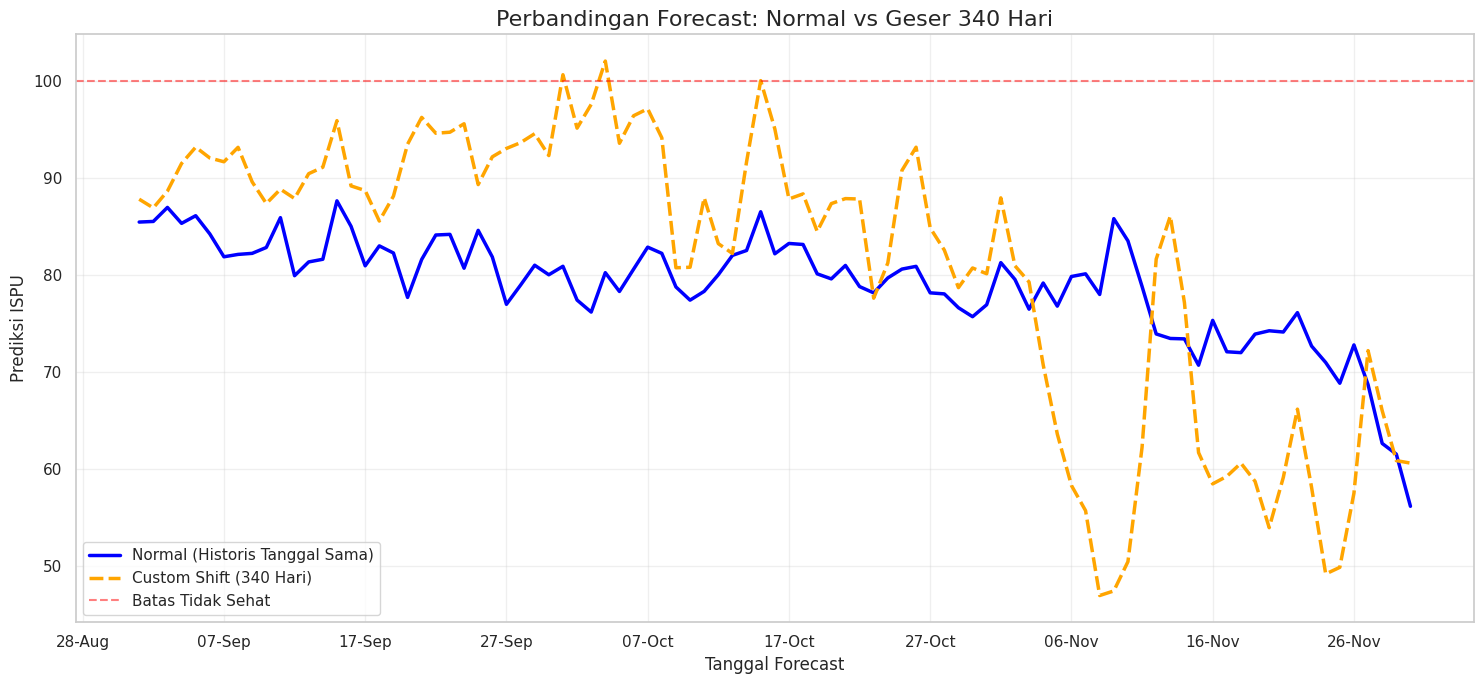

In [117]:
viz_days = results_days.groupby('time')['pred_max'].mean().reset_index()
viz_days['Skenario'] = f'Custom Shift ({days_back} Hari)'

if 'future_results_clim' in globals():
    viz_normal = future_results_clim.groupby('time')['pred_max'].mean().reset_index()
    viz_normal['Skenario'] = 'Normal (Historis Tanggal Sama)'
    df_viz_days = pd.concat([viz_normal, viz_days])
else:
    df_viz_days = viz_days

plt.figure(figsize=(15, 7))

# Plot
sns.lineplot(
    data=df_viz_days,
    x='time',
    y='pred_max',
    hue='Skenario',
    style='Skenario',
    palette=['blue', 'orange'], # Biru = Normal, Oranye = Custom
    linewidth=2.5
)

plt.title(f'Perbandingan Forecast: Normal vs Geser {days_back} Hari', fontsize=16)
plt.axhline(100, color='red', linestyle='--', alpha=0.5, label='Batas Tidak Sehat')
plt.ylabel('Prediksi ISPU')
plt.xlabel('Tanggal Forecast')

# Format Tanggal
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=10))

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [118]:
import pandas as pd
import numpy as np

# --- 1. Konfigurasi Validasi (Target 2024) ---
val_start_date = pd.to_datetime('2024-09-01')
val_end_date = pd.to_datetime('2024-11-30')

# Konfigurasi Cross-Station (Sama persis dengan rencana 2025)
cross_station_config = {
    'DKI1': [('DKI5', 342), ('DKI4', 342)], 
    'DKI2': [('DKI4', 340)],
    'DKI3': [('DKI3', 340)],
    'DKI4': [('DKI4', 340)],
    'DKI5': [('DKI4', 340), ('DKI5', 340)]    
}

print(f"Target Validasi : {val_start_date.date()} s.d {val_end_date.date()}")
print("Menyiapkan data Cross-Station Ensemble...")

dfs_ready = []

# --- 2. Loop Pembuatan Data Source ---
for target_st, sources_list in cross_station_config.items():
    
    temp_source_dfs = []
    
    for source_st, days_back in sources_list:
        # Hitung mundur dari tanggal validasi 2024 (berarti ambil data 2023)
        source_start = val_start_date - pd.Timedelta(days=days_back)
        source_start_buffer = source_start - pd.Timedelta(days=14) # Buffer lag
        duration = val_end_date - val_start_date
        source_end = source_start + duration
        
        # Ambil data sumber
        mask = ((df_combined['lokasi_spku'] == source_st) & 
                (df_combined['time'] >= source_start_buffer) & 
                (df_combined['time'] <= source_end))
        
        df_part = df_combined[mask].copy()
        
        if len(df_part) > 0:
            # Shift waktu agar seolah-olah terjadi di 2024
            df_part['time'] = df_part['time'] + pd.Timedelta(days=days_back)
            temp_source_dfs.append(df_part)
            
    if temp_source_dfs:
        # RATA-RATA (Ensemble): Jika sumber > 1, dirata-rata
        df_merged = pd.concat(temp_source_dfs)
        df_averaged = df_merged.groupby('time').mean(numeric_only=True).reset_index()
        
        # Tetapkan label stasiun target (misal data DKI5+DKI4 dilabeli jadi DKI1)
        df_averaged['lokasi_spku'] = target_st
        dfs_ready.append(df_averaged)
    else:
        print(f"Warning: Tidak ada data source ditemukan untuk target {target_st}")

# --- 3. Gabungkan Semua Stasiun ---
df_ensemble_val = pd.concat(dfs_ready).sort_values(['lokasi_spku', 'time'])

# Update fitur waktu
df_ensemble_val['month'] = df_ensemble_val['time'].dt.month
df_ensemble_val['day'] = df_ensemble_val['time'].dt.day
df_ensemble_val['year'] = df_ensemble_val['time'].dt.year

# --- 4. Blind Test & Anchor ---
# Kosongkan target max di periode validasi
mask_future = df_ensemble_val['time'] >= val_start_date
df_ensemble_val.loc[mask_future, 'max'] = np.nan

# Bersihkan & Pasang Anchor Baru
if 'anchor_clim_median' in df_ensemble_val.columns:
    df_ensemble_val = df_ensemble_val.drop(columns=['anchor_clim_median'])

# Merge anchor (pastikan anchor_lookup sudah ada dari tahap training)
df_ensemble_val = pd.merge(df_ensemble_val, anchor_lookup, on=['lokasi_spku', 'month', 'day'], how='left')
# Isi NaN anchor
global_median = train_df['max'].median()
df_ensemble_val['anchor_clim_median'] = df_ensemble_val['anchor_clim_median'].fillna(global_median)

# --- 5. Generate Lags ---
lags = [1, 2, 3]
for lag in lags:
    df_ensemble_val[f'target_lag_{lag}'] = df_ensemble_val.groupby('lokasi_spku')['max'].shift(lag)

# Filter data siap forecast
val_forecast_ensemble = df_ensemble_val[df_ensemble_val['time'] >= val_start_date].copy()

# --- 6. Jalankan Recursive Forecast ---
print(f"Memulai forecast Ensemble untuk {len(val_forecast_ensemble)} baris...")
results_ensemble = recursive_forecast(model, val_forecast_ensemble, features, lags=[1, 2, 3])

# mask_patch_result = (results_ensemble['time'] >= patch_start) & (results_ensemble['time'] <= patch_end)
# results_ensemble.loc[mask_patch_result, 'pred_max'] = results_ensemble.loc[mask_patch_result, 'pred_max'].clip(upper=HARD_LIMIT)

print("\nForecast Selesai.")
print(results_ensemble[['time', 'lokasi_spku', 'pred_max']].head())

Target Validasi : 2024-09-01 s.d 2024-11-30
Menyiapkan data Cross-Station Ensemble...
Memulai forecast Ensemble untuk 320 baris...
Memulai Recursive Forecasting untuk 67 hari...

Forecast Selesai.
          time lokasi_spku    pred_max
14  2024-09-01        DKI1   82.021707
249 2024-09-01        DKI4  217.054344
171 2024-09-01        DKI3   74.756262
94  2024-09-01        DKI2  216.511135
326 2024-09-01        DKI5  120.041808


In [119]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, f1_score, classification_report

# --- 1. Gabungkan Prediksi dengan Ground Truth ---
# Ambil data asli 2024
truth_df = df_combined[(df_combined['time'] >= val_start_date) & 
                       (df_combined['time'] <= val_end_date)][['time', 'lokasi_spku', 'max']].copy()
truth_df.rename(columns={'max': 'actual_max'}, inplace=True)

# Merge
eval_df_ensemble = pd.merge(results_ensemble, truth_df, on=['time', 'lokasi_spku'], how='inner')

y_true = eval_df_ensemble['actual_max']
y_pred = eval_df_ensemble['pred_max']

# --- 2. Metrik Regresi ---
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("="*50)
print(f"METRIK REGRESI (Metode Cross-Station Ensemble)")
print("="*50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

# --- 3. Metrik Klasifikasi (Threshold Standar) ---
def get_standard_category(score):
    if score <= 50: return "BAIK"
    elif score <= 100: return "SEDANG"
    else: return "TIDAK SEHAT"

v_cat = np.vectorize(get_standard_category)
y_true_cat = v_cat(y_true)
y_pred_cat = v_cat(y_pred)

f1_std = f1_score(y_true_cat, y_pred_cat, average='macro')
print("\n" + "="*50)
print(f"METRIK KLASIFIKASI STANDAR (F1 Macro: {f1_std:.4f})")
print("="*50)
print(classification_report(y_true_cat, y_pred_cat))

METRIK REGRESI (Metode Cross-Station Ensemble)
MAE  : 19.3496
RMSE : 29.1582
R2   : -3.4955

METRIK KLASIFIKASI STANDAR (F1 Macro: 0.4732)
              precision    recall  f1-score   support

      SEDANG       0.94      0.74      0.83       298
 TIDAK SEHAT       0.07      0.29      0.12        21

    accuracy                           0.71       319
   macro avg       0.50      0.52      0.47       319
weighted avg       0.88      0.71      0.78       319



In [120]:
# --- Tuning Threshold Per Stasiun (Ensemble) ---
stations = eval_df_ensemble['lokasi_spku'].unique()
df_tuning_ens = eval_df_ensemble.copy()
df_tuning_ens['pred_cat_optimized'] = "TIDAK DITENTUKAN"

# Helper fungsi
def get_numeric_cat(score):
    if score <= 50: return 0
    elif score <= 100: return 1
    else: return 2

v_num_cat = np.vectorize(get_numeric_cat)

print(f"Memulai Tuning Threshold (Metode Ensemble) untuk {len(stations)} Stasiun...\n")
print(f"{'STASIUN':<10} | {'F1 AWAL':<10} | {'F1 BARU':<10} | {'BEST T1':<8} | {'BEST T2':<8}")
print("-" * 65)

# Range Pencarian
search_range_t1 = np.arange(40, 65, 1)
search_range_t2 = np.arange(90, 130, 1)

station_thresholds_ens = {}

for station in stations:
    mask = df_tuning_ens['lokasi_spku'] == station
    y_true_local = df_tuning_ens.loc[mask, 'actual_max'].values
    y_pred_local = df_tuning_ens.loc[mask, 'pred_max'].values
    
    y_true_encoded = v_num_cat(y_true_local)
    
    # F1 Awal
    preds_init = np.zeros(len(y_pred_local))
    preds_init[y_pred_local > 50] = 1
    preds_init[y_pred_local > 100] = 2
    f1_initial = f1_score(y_true_encoded, preds_init, average='macro')
    
    # Grid Search
    best_f1 = -1
    best_t1, best_t2 = 50, 100
    
    for t1 in search_range_t1:
        for t2 in search_range_t2:
            if t1 >= t2: continue
            
            p_cand = np.zeros(len(y_pred_local))
            p_cand[y_pred_local > t1] = 1
            p_cand[y_pred_local > t2] = 2
            
            sc = f1_score(y_true_encoded, p_cand, average='macro')
            if sc > best_f1:
                best_f1 = sc
                best_t1, best_t2 = t1, t2
                
    # Simpan Thresholds
    station_thresholds_ens[station] = {'t1': best_t1, 't2': best_t2}
    
    # Apply
    final_preds = np.zeros(len(y_pred_local))
    final_preds[y_pred_local > best_t1] = 1
    final_preds[y_pred_local > best_t2] = 2
    
    label_map = {0: 'BAIK', 1: 'SEDANG', 2: 'TIDAK SEHAT'}
    df_tuning_ens.loc[mask, 'pred_cat_optimized'] = [label_map[x] for x in final_preds]
    
    print(f"{station:<10} | {f1_initial:.4f}     | {best_f1:.4f}     | {best_t1:<8} | {best_t2:<8}")

print("-" * 65)

# Evaluasi Global Akhir
y_global_true = [label_map[x] for x in v_num_cat(df_tuning_ens['actual_max'])]
f1_final_global = f1_score(y_global_true, df_tuning_ens['pred_cat_optimized'], average='macro')

print(f"\nF1 Global Akhir (Ensemble + Optimized): {f1_final_global:.4f}")
print(classification_report(y_global_true, df_tuning_ens['pred_cat_optimized']))

Memulai Tuning Threshold (Metode Ensemble) untuk 5 Stasiun...

STASIUN    | F1 AWAL    | F1 BARU    | BEST T1  | BEST T2 
-----------------------------------------------------------------
DKI1       | 0.4884     | 0.4923     | 40       | 109     
DKI4       | 0.3623     | 0.5511     | 40       | 125     
DKI3       | 0.4880     | 0.5661     | 40       | 92      
DKI2       | 0.3473     | 0.4706     | 40       | 119     
DKI5       | 0.5158     | 0.5541     | 40       | 96      
-----------------------------------------------------------------

F1 Global Akhir (Ensemble + Optimized): 0.5665
              precision    recall  f1-score   support

      SEDANG       0.95      0.90      0.92       298
 TIDAK SEHAT       0.17      0.29      0.21        21

    accuracy                           0.86       319
   macro avg       0.56      0.59      0.57       319
weighted avg       0.90      0.86      0.88       319



In [121]:
forecast_start_date = pd.to_datetime('2025-09-01')
forecast_end_date = pd.to_datetime('2025-11-30')

cross_station_config = {
    'DKI1': [('DKI5', 342), ('DKI4', 342)], 
    'DKI2': [('DKI4', 340)],
    'DKI3': [('DKI3', 340)],
    'DKI4': [('DKI4', 340)],
    'DKI5': [('DKI4', 340), ('DKI5', 340)]   
}

dfs_ready = []

for target_st, sources_list in cross_station_config.items():
    
    temp_source_dfs = []
    
    for source_st, days_back in sources_list:
        
        source_start = forecast_start_date - pd.Timedelta(days=days_back)
        source_start_buffer = source_start - pd.Timedelta(days=10)
        duration = forecast_end_date - forecast_start_date
        source_end = source_start + duration
        
        mask = ((df_combined['lokasi_spku'] == source_st) & 
                (df_combined['time'] >= source_start_buffer) & 
                (df_combined['time'] <= source_end))
        
        df_part = df_combined[mask].copy()
        
        if len(df_part) > 0:
            df_part['time'] = df_part['time'] + pd.Timedelta(days=days_back)
            temp_source_dfs.append(df_part)
            
    if temp_source_dfs:
        df_merged = pd.concat(temp_source_dfs)
        df_averaged = df_merged.groupby('time').mean(numeric_only=True).reset_index()
        df_averaged['lokasi_spku'] = target_st
        dfs_ready.append(df_averaged)
    else:
        print(f"Warning: Tidak ada data source ditemukan untuk target {target_st}")

# Gabungkan hasil akhir
df_days = pd.concat(dfs_ready).sort_values(['lokasi_spku', 'time'])

df_days['month'] = df_days['time'].dt.month
df_days['day'] = df_days['time'].dt.day
df_days['year'] = df_days['time'].dt.year

mask_future = df_days['time'] >= forecast_start_date
df_days.loc[mask_future, 'max'] = np.nan

if 'anchor_clim_median' in df_days.columns:
    df_days = df_days.drop(columns=['anchor_clim_median'])

df_days = pd.merge(df_days, anchor_lookup, on=['lokasi_spku', 'month', 'day'], how='left')

lags = [1, 2, 3]
for lag in lags:
    df_days[f'target_lag_{lag}'] = df_days.groupby('lokasi_spku')['max'].shift(lag)

future_forecast_days = df_days[df_days['time'] >= forecast_start_date].copy()

print(f"Memulai forecast dengan Ensemble Source Data...")
results_days = recursive_forecast(model, future_forecast_days, features, lags=[1, 2, 3])

# hard clipping outlier pada bagian ini (outlier)
patch_start = pd.to_datetime('2025-11-10')
patch_end   = pd.to_datetime('2025-11-15')
HARD_LIMIT = 50.0 

mask_patch_result = (results_days['time'] >= patch_start) & (results_days['time'] <= patch_end)
results_days.loc[mask_patch_result, 'pred_max'] = results_days.loc[mask_patch_result, 'pred_max'].clip(upper=HARD_LIMIT)

# Cek hasil
print("\nContoh Hasil (DKI1 sekarang adalah rata-rata source):")
print(results_days[results_days['lokasi_spku']=='DKI1'][['time', 'lokasi_spku', 'pred_max']].head())

Memulai forecast dengan Ensemble Source Data...
Memulai Recursive Forecasting untuk 91 hari...

Contoh Hasil (DKI1 sekarang adalah rata-rata source):
         time lokasi_spku   pred_max
10 2025-09-01        DKI1  79.610656
11 2025-09-02        DKI1  80.751774
12 2025-09-03        DKI1  80.166389
13 2025-09-04        DKI1  77.408686
14 2025-09-05        DKI1  79.589463


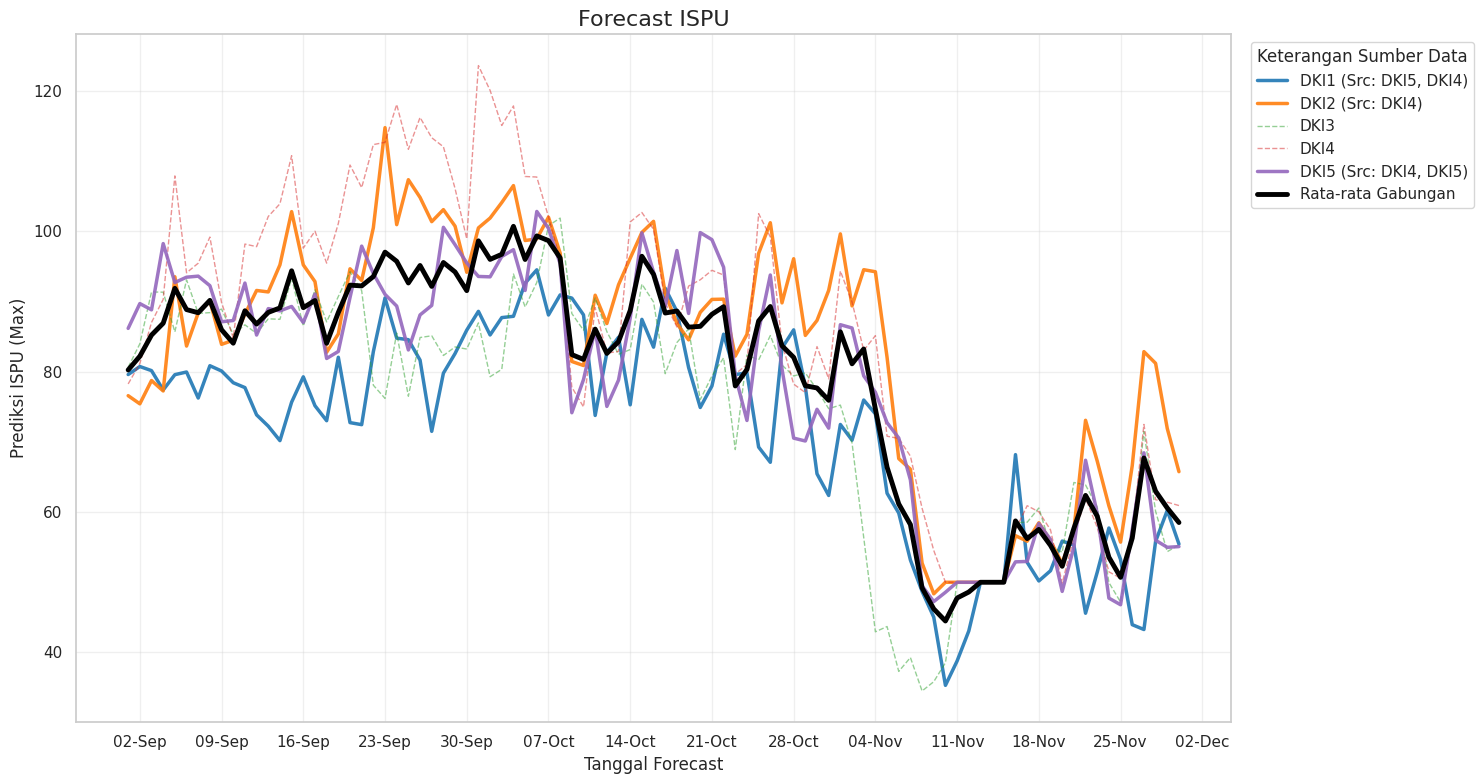

In [122]:
import matplotlib.dates as mdates

# Hitung ulang rata-rata gabungan
viz_avg = results_days.groupby('time')['pred_max'].mean().reset_index()

# Palet warna
station_colors = {
    'DKI1': '#1f77b4', # Biru
    'DKI2': '#ff7f0e', # Oranye
    'DKI3': '#2ca02c', # Hijau
    'DKI4': '#d62728', # Merah
    'DKI5': '#9467bd'  # Ungu
}

plt.figure(figsize=(15, 8))

for target_st, sources_list in cross_station_config.items():
    st_data = results_days[results_days['lokasi_spku'] == target_st]
    source_names = [s[0] for s in sources_list]
    is_original = (len(sources_list) == 1) and (source_names[0] == target_st)
    
    if not is_original:
        ls = '-'      
        lw = 2.5      
        alpha = 0.9   
        label_text = f"{target_st} (Src: {', '.join(source_names)})"
    else:
        ls = '--'     
        lw = 1.0      
        alpha = 0.5   
        label_text = target_st

    # Plot Garis
    plt.plot(
        st_data['time'], 
        st_data['pred_max'], 
        color=station_colors.get(target_st, 'grey'), 
        alpha=alpha, 
        linewidth=lw, 
        linestyle=ls,
        label=label_text
    )

# 3. Plot Rata-rata Gabungan (Hitam Tebal)
sns.lineplot(
    data=viz_avg,
    x='time',
    y='pred_max',
    color='black',
    linewidth=3.5,
    label='Rata-rata Gabungan'
)

# 4. Aksesoris Grafik
plt.title('Forecast ISPU', fontsize=16)
plt.ylabel('Prediksi ISPU (Max)')
plt.xlabel('Tanggal Forecast')

# Format Tanggal Sumbu X
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))

# Legend di luar
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', title='Keterangan Sumber Data')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

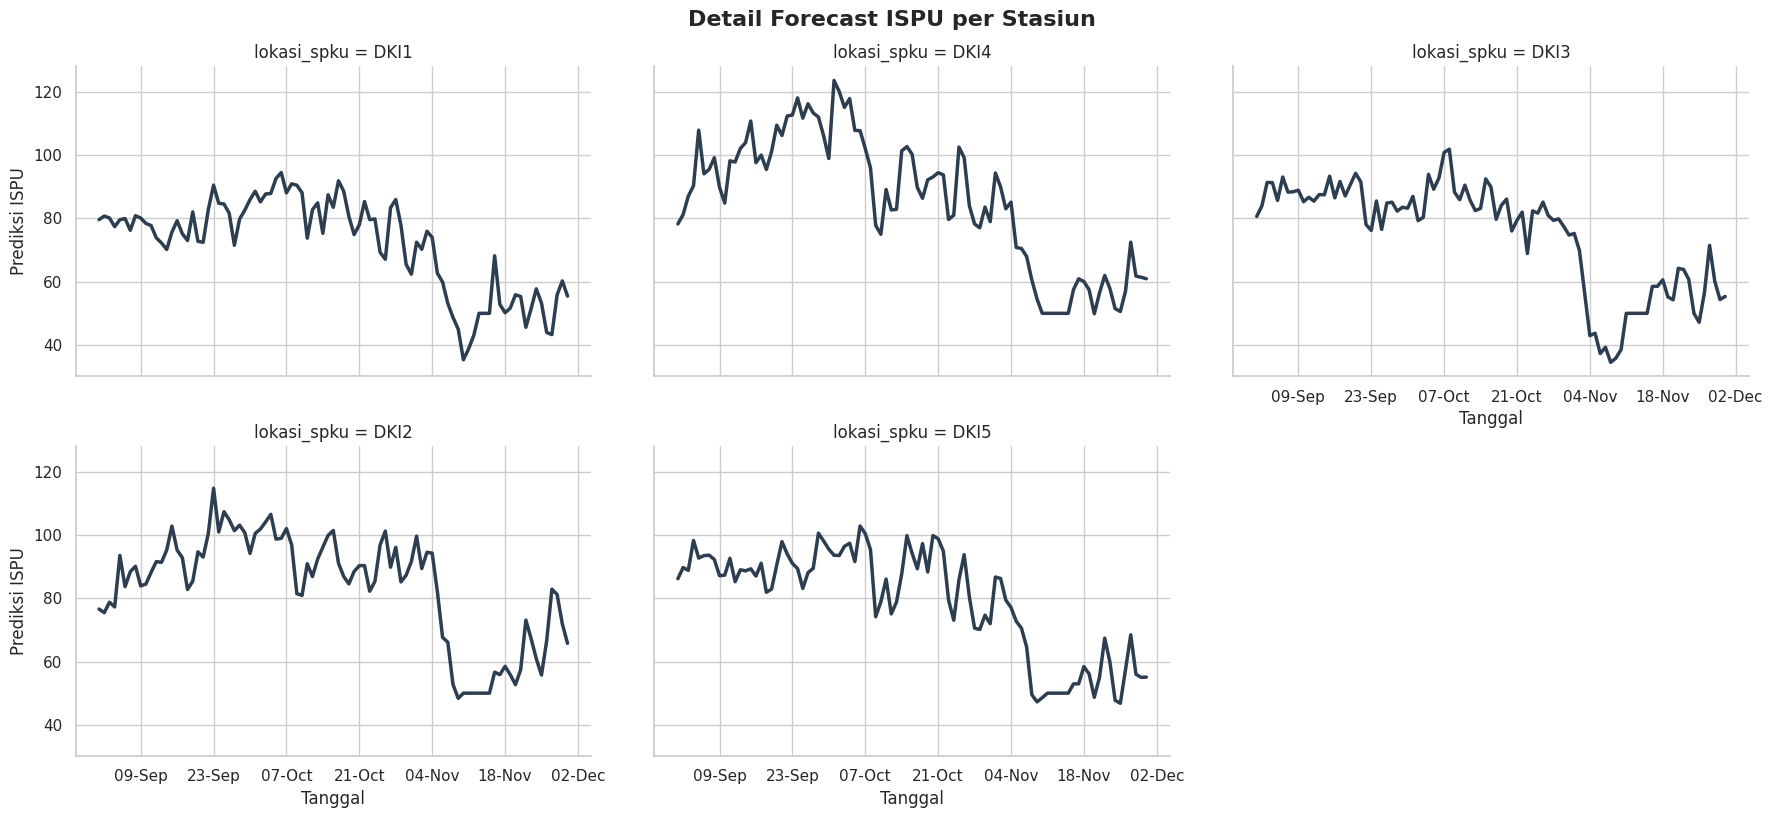

In [123]:
import matplotlib.dates as mdates

viz_df = results_days.copy()
viz_df['time'] = pd.to_datetime(viz_df['time'])
config = {
    'DKI1': [50, 92],
    'DKI2': [68, 107],
    'DKI3': [38, 94],
    'DKI4': [61, 124],
    'DKI5': [50, 98],
}

default_thresh = [50, 100]
sns.set_style("whitegrid")

g = sns.relplot(
    data=viz_df,
    x="time", 
    y="pred_max",
    col="lokasi_spku", 
    col_wrap=3,        
    kind="line",
    height=4, 
    aspect=1.5,
    linewidth=2.5,
    color="#2c3e50"    
)

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=14)) 

g.fig.suptitle(f'Detail Forecast ISPU per Stasiun', 
               fontsize=16, fontweight='bold', y=1.02)
g.set_axis_labels("Tanggal", "Prediksi ISPU")
plt.show()

# Submission

In [124]:
df_sub = results_days.copy()

df_sub['time'] = pd.to_datetime(df_sub['time'])

start_sub = '2025-09-01'
end_sub   = '2025-11-30'
df_sub = df_sub[(df_sub['time'] >= start_sub) & (df_sub['time'] <= end_sub)]

def clean_station_for_id(text):
    text = str(text).upper().strip()
    if 'DKI' in text:
        return text.split(' ')[0] 
    return text

df_sub['station_code'] = df_sub['lokasi_spku'].apply(clean_station_for_id)
df_sub['id'] = df_sub['time'].dt.strftime('%Y-%m-%d') + '_' + df_sub['station_code']

if 'config' not in globals():
    print("Warning: config tidak ditemukan. Menggunakan default [50, 100].")
    config = {}

default_thresh = [50, 100]

def determine_category(row):
    val = row['pred_max']
    station = row['station_code']
    
    # Ambil batas khusus stasiun tersebut
    limits = config.get(station, default_thresh)
    
    # Logika Klasifikasi
    if val <= limits[0]:
        return 'BAIK'
    elif val < limits[1]:
        return 'SEDANG'
    else:
        return 'TIDAK SEHAT'

df_sub['category'] = df_sub.apply(determine_category, axis=1)

submission_file = df_sub[['id', 'category']].sort_values('id')

filename = 'submission.csv'
submission_file.to_csv(filename, index=False)

print(f"File submission berhasil dibuat: {filename}")
print(f"Jumlah Baris: {len(submission_file)}")
print("\nContoh 5 baris pertama:")
print(submission_file.head())

print("\nDistribusi Kategori:")
print(submission_file['category'].value_counts())

File submission berhasil dibuat: submission.csv
Jumlah Baris: 454

Contoh 5 baris pertama:
                  id category
10   2025-09-01_DKI1   SEDANG
111  2025-09-01_DKI2   SEDANG
212  2025-09-01_DKI3   SEDANG
312  2025-09-01_DKI4   SEDANG
413  2025-09-01_DKI5   SEDANG

Distribusi Kategori:
category
SEDANG         374
BAIK            65
TIDAK SEHAT     15
Name: count, dtype: int64


### sedikit post-processing karena ada 1 row yang hilang . jadi, kami isi dengan nilai modus yakni "SEDANG".

In [127]:
dates = pd.date_range(start='2025-09-01', end='2025-11-30', freq='D')
stations = ['DKI1', 'DKI2', 'DKI3', 'DKI4', 'DKI5']

ids_expected = []
for d in dates:
    d_str = d.strftime('%Y-%m-%d')
    for s in stations:
        ids_expected.append(f"{d_str}_{s}")

df_expected = pd.DataFrame({'id': ids_expected})

print(f"Target baris seharusnya: {len(df_expected)}") 
print(f"Baris yang Anda punya: {len(submission_file)}")

df_fixed = pd.merge(df_expected, submission_file, on='id', how='left')

missing_rows = df_fixed[df_fixed['category'].isna()]

if len(missing_rows) > 0:
    print("\nDITEMUKAN BARIS HILANG:")
    print(missing_rows['id'].values)
    
    print("\nMelakukan penambalan (patching)...")
    
    df_fixed['category'] = df_fixed['category'].fillna('SEDANG')
    df_fixed['category'] = df_fixed['category'].ffill().bfill()

    print(f"Data berhasil ditambal. Total baris sekarang: {len(df_fixed)}")
    
else:
    print("\nAneh, tidak ada row yang hilang menurut pengecekan Skeleton.")

df_fixed = df_fixed.sort_values('id')

# Simpan
filename_fixed = 'submission_final.csv'
df_fixed.to_csv(filename_fixed, index=False)

print(f"\nFile Final (455 Baris) disimpan: {filename_fixed}")
print(df_fixed.head())
print(df_fixed.tail())

Target baris seharusnya: 455
Baris yang Anda punya: 454

DITEMUKAN BARIS HILANG:
['2025-11-03_DKI3']

Melakukan penambalan (patching)...
Data berhasil ditambal. Total baris sekarang: 455

File Final (455 Baris) disimpan: submission_final.csv
                id category
0  2025-09-01_DKI1   SEDANG
1  2025-09-01_DKI2   SEDANG
2  2025-09-01_DKI3   SEDANG
3  2025-09-01_DKI4   SEDANG
4  2025-09-01_DKI5   SEDANG
                  id category
450  2025-11-30_DKI1   SEDANG
451  2025-11-30_DKI2     BAIK
452  2025-11-30_DKI3   SEDANG
453  2025-11-30_DKI4     BAIK
454  2025-11-30_DKI5   SEDANG
